# Predicting Antibacterial Activity Against E. coli Using Molecular Descriptors

### Priscilla Vaskez · Trinity Ho · Yasemin Sucu · Dongwan Kim

## GitHub: https://github.com/dw1229/chem277a-final-ecoli-inhibition-ml

## Objective

Predict antibacterial activity against *Escherichia coli* using compound screening data from the Community for Open Antimicrobial Drug Discovery (CO-ADD) database. Compounds are represented by molecular descriptors and structural fingerprints derived from SMILES, combined with assay-derived measurements such as DMAX_AVE. After exploratory analysis showed that direct regression of inhibition values was unreliable on this dataset, the task is framed as an assay-aware classification problem: identifying compounds in the top 10% of INHIB_AVE. Multiple machine-learning approaches, including logistic regression, ElasticNet-regularized logistic regression, support vector machines, an artificial neural network, and unsupervised clustering, are compared to determine which best captures inhibition patterns.

## Introduction 

Antibiotic resistance has become one of the most urgent challenges in modern medicine, identified by the World Health Organization as a top-ten global public health threat and projected to cause up to ten million deaths annually by 2050 if current trends continue (O'Neill, 2016; Murray et al., 2022). Gram-negative pathogens such as *Escherichia coli* are especially challenging because their double-membrane structure restricts antibiotic entry, resistance has spread rapidly across clinical isolates, and *E. coli* alone drives the majority of community-acquired urinary tract infections and a substantial share of bloodstream infections worldwide. Despite the clinical urgency, antibiotic discovery remains slow and inefficient, with phenotypic screening of millions of compounds typically yielding very low hit rates and requiring substantial experimental effort to identify promising candidates (Tommasi et al., 2015). *In silico* pre-filtering through quantitative structure-activity relationship (QSAR) modeling has emerged as a way to triage candidates before experimental validation (Cherkasov et al., 2014).

In this project, we trained and compared multiple machine learning models to predict *E. coli* growth inhibition (INHIB_AVE) using data from the Community for Open Antimicrobial Drug Discovery (CO-ADD), a publicly available repository designed to support antibiotic discovery through large-scale phenotypic screening (Blaskovich et al., 2015). Our feature representation combines nine interpretable RDKit descriptors with 1,024-bit Morgan circular fingerprints, which are widely used in cheminformatics for encoding local structural environments in molecules (Rogers & Hahn, 2010). For the strongest classification model we extend this with additional structural features (MACCS keys, larger Morgan fingerprints, and Tanimoto similarity to known actives) to capture broader structural relationships between compounds. After exploratory analysis showed that direct regression of inhibition values produced negative test-set R² values, we frame the task as assay-aware classification: predicting compounds in the top 10% of INHIB_AVE using chemical structure features alongside dose-response and assay-quality measurements (DMAX_AVE, MIC_VALUE, INHIB_STD). This framing reflects a realistic compound-prioritization scenario in which dose-response and quality-control measurements are used as part of the prediction pipeline, rather than a pure structure-only QSAR setting. We compare regression baselines, supervised classifiers (logistic regression in two variants, ElasticNet-regularized logistic regression, support vector machines, and an artificial neural network), and unsupervised clustering methods to determine which framework best captures inhibition patterns in this dataset.

## Methods


### Data Source and Preparation

The dataset was obtained from the Community for Open Antimicrobial Drug Discovery (CO-ADD) public database (Blaskovich et al. 2015), which provides phenotypic screening results for compounds against a range of bacterial pathogens. Two CSV files were used: an inhibition dataset (single-concentration percent-inhibition values) and a dose-response dataset (concentration-response curve fits including DMAX_AVE, the maximum observed inhibition). The two were merged on COADD_ID, STRAIN, and ASSAY_ID using an exact-key inner join, yielding 4,268 records covering 4,174 unique compounds for *Escherichia coli*. The continuous target variable is INHIB_AVE, the mean percent inhibition at the assay concentration. Compounds with negative INHIB_AVE values (indicating measured promotion of growth, or measurement noise around zero) were retained rather than filtered, on the rationale that excluding them would reduce the dataset size without removing any conceptual ambiguity for the binary classification task.

### Feature Engineering

Each compound is represented by 1,037 features. Nine physicochemical descriptors were computed from canonical SMILES strings using RDKit (Landrum 2006): molecular weight (MW), partition coefficient (logP), topological polar surface area (TPSA), hydrogen bond donors (HBD), hydrogen bond acceptors (HBA), rotatable bonds (RotBonds), total ring count (Rings), aromatic ring count (ArRings), and the QED drug-likeness score. A 1,024-bit Morgan fingerprint with radius 2 was generated for each compound to capture local substructural patterns beyond the global descriptors. Assay-derived measurements (DMAX_AVE from dose-response data, MIC_VALUE in micromolar units, and INHIB_STD as a measurement-quality indicator) were retained as numerical features. This "assay-aware" framing allows the models to use replicate-quality information alongside molecular structure when discriminating between active and inactive compounds. For the ElasticNet logistic regression analysis, an extended feature representation was used: 1,024-bit and 2,048-bit Morgan fingerprints, MACCS keys (166 bits), and Tanimoto similarity to known actives, totaling 2,447 features.

All numerical features were standardized using scikit-learn's `StandardScaler` (zero mean, unit variance) fit on the training set and applied to both training and test sets. Standardization is required for distance-based methods (SVM, K-Means, UMAP) and regularized linear models (ElasticNet, neural networks) to ensure features contribute proportionally regardless of their natural scale.

### Activity Thresholding

To convert continuous INHIB_AVE values into binary active/inactive labels, the 90th percentile of the training distribution (approximately 30.9% inhibition) was used as the activity cutoff, defining the top 10% of compounds as actives. This threshold was chosen as a screening-style definition: in a primary-screening application, the goal is to shortlist a small number of high-priority candidates rather than coarsely separate active from inactive halves of the distribution. We considered a stricter top 5% definition but rejected it because the resulting class imbalance would inflate accuracy without reflecting genuine model skill. A Gaussian Mixture Model fit to INHIB_AVE confirmed the absence of clean bimodal structure (one dominant component near zero plus a small high-activity tail), supporting the use of a quantile-based cutoff rather than a mixture-derived threshold. Earlier exploratory cells in this notebook used a 70th percentile threshold during initial model evaluation; final reported results use the 90th percentile unless otherwise noted.

### Train/Test Split

The data were split using `train_test_split` from scikit-learn with `random_state=28` and an 80/20 ratio, yielding 3,414 training compounds and 854 test compounds. For the ElasticNet logistic regression analysis, a three-way split (train/validation/test) was used to tune regularization parameters without leaking test information.

### Models Evaluated

We evaluated a progression of supervised classifiers from linear baselines through nonlinear approaches, complemented by unsupervised exploratory analysis. Methodological details and per-model justifications are presented at each model's first appearance below.

**1. Linear regression**

Ordinary least squares and a feature-selected variant were fit on the continuous INHIB_AVE target as an initial regression baseline. Both produced negative test-set R² values, indicating that the structure-activity relationship is not well captured by a global linear model. These results motivated a shift toward classification-based approaches.

**2. Logistic regression**

Generalized linear models with logit link and binomial family were fit using statsmodels, both on the full 1,037-feature representation and on a manually selected eight-feature subset (DMAX_AVE, HBD, HBA, ArRings, MIC_VALUE_uM, INHIB_STD, RotBonds, Rings). The full-features model serves as a high-capacity baseline; the feature-selected variant trades capacity for coefficient stability and biological interpretability.

**3. ElasticNet logistic regression**

A regularized logistic regression with combined L1 and L2 penalties was fit on the extended 2,447-feature representation. A buffer filter was applied during training that drops compounds within 1.5 × INHIB_STD of the activity threshold, removing borderline cases that introduce label noise.

**4. Support vector machine**

An SVM with radial basis function kernel was fit at both 70th and 90th percentile thresholds, with class weighting to partially correct for imbalance. The RBF kernel was selected because preliminary linear approaches (linear regression, linear-kernel SVM) underperformed, suggesting nonlinear structure-activity relationships.

**5. Artificial neural network**

A feedforward neural network (Multi-Layer Perceptron) with one hidden layer of 64 ReLU units and a softmax output over two classes was implemented in TensorFlow/Keras, trained with the Adam optimizer and categorical cross-entropy loss. The baseline model showed severe overfitting (training loss collapsed to near zero while validation loss climbed) and limited recall on the active class (0.49). A progressive regularization study was therefore conducted, with each variant evaluated against the previous configuration: L2 weight decay (lambda = 0.01) combined with EarlyStopping (patience = 10) to address overfitting; balanced class weights (9:1, with 12:1 also tested for sensitivity) to push the model toward the minority active class; SMOTE-based synthetic minority oversampling (Chawla et al. 2002) as a data-level alternative to loss reweighting; threshold tuning to characterize the precision-recall trade-off across operating points (Esposito et al. 2021); and a two-hidden-layer variant (64 then 32 neurons with dropout = 0.3 and 0.2 between layers) to test whether added depth captures more nonlinear structure once SMOTE expands the effective training set. The literature informing these choices includes the QSAR class-imbalance work of Tomei et al. (2025), de Souza et al. (2023), and Koutsoukas et al. (2017), the Goodfellow et al. (2016) treatment of regularization in deep learning, and the TensorFlow regularization guide.

**6. Unsupervised analysis**

K-Means clustering with k = 2 was applied to assess whether compounds form natural active/inactive groupings in feature space, both on the full feature space and after PCA dimensionality reduction. UMAP (McInnes et al. 2018) was used to visualize the high-dimensional feature space in two dimensions. A GMM was additionally fit to the INHIB_AVE distribution to characterize natural breakpoints (see Activity Thresholding above), with cluster assignments projected onto the UMAP embedding to assess whether distribution-based clusters correspond to separable structure in feature space.

### Evaluation Metrics

For all classification models, we report test-set accuracy, per-class precision, recall, F1 score, and the confusion matrix. Recall on the active class is treated as the primary metric of interest, because the practical objective is to identify candidate antibacterial compounds for downstream validation: a false negative (missing a real active) has higher scientific cost than a false positive (flagging a compound that fails confirmation). For the ANN regularization study we additionally report ROC-AUC and PR-AUC because the central claim of that section is improved minority-class detection, which is best evaluated with threshold-free metrics under heavy class imbalance (Davis and Goadrich 2006). Decision threshold tuning was performed for the regularized ANN to characterize the precision-recall trade-off across operating points (Esposito et al. 2021).

### Reproducibility

A global random seed (`SEED = 28`) is set at the top of the notebook for Python's `random`, NumPy, and TensorFlow. The train/test split uses `random_state=28` so all models are evaluated on the same held-out compounds. Stochastic operations (K-Means, GMM, UMAP, SMOTE oversampling, neural network weight initialization) are also seeded individually at the call site, since sklearn and similar libraries maintain their own RNG state and do not inherit from the global seed. Deterministic models (statsmodels GLM, OLS linear regression, SVM with RBF kernel) are reproducible without explicit seeding. Setup files (`environment.yml` and `requirements.txt`) reproduce the conda/pip environment used for this work.

## Implementation

In [1]:
# Standard library
import re
import random
from pathlib import Path
from types import SimpleNamespace

# Core scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pylab
import scipy.stats as stats

# Statsmodels
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Dimensionality reduction and clustering
import umap
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from pyclustering.utils.metric import *
from nltk.cluster.kmeans import KMeansClusterer

# Sklearn model selection and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Sklearn models
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV, Ridge, Lasso
from sklearn.svm import SVC

# Sklearn metrics (all of them combined)
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    silhouette_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    roc_auc_score,
    auc,
)

# RDKit
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors, QED, rdMolDescriptors, MACCSkeys, rdFingerprintGenerator
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# SVM
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score

# For SMOTE
from imblearn.over_sampling import SMOTE

# Reproducibility seeds
SEED = 28
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

---
This sets the folder and file paths for the two CO-ADD CSV files.
- `DATA_DIR` points to the folder containing the data.
- `INHIB_PATH` and `DOSE_PATH` build the full path to each CSV file using `Path` / operator.

In [2]:
DATA_DIR = Path("CO-ADD_r03.02-2020_CSV")
INHIB_PATH = DATA_DIR / "CO-ADD_InhibitionData_r03_01-02-2020_CSV.csv"
DOSE_PATH = DATA_DIR / "CO-ADD_DoseResponseData_r03_01-02-2020_CSV.csv"

---

## Open Inhibition data CSV file

In [3]:
# There are two CSV files in the CO-ADD folder.
# For now, we will open the InhibitionData file.

df = pd.read_csv(INHIB_PATH, low_memory=False)
print(df.head())

   Unnamed: 0        COADD_ID  COMPOUND_CODE COMPOUND_NAME     PROJECT_ID  \
0           0  CO-ADD:0227954  A0879/0041231           NaN  CO-ADD:PC0244   
1           1  CO-ADD:0227954  A0879/0041231           NaN  CO-ADD:PC0244   
2           2  CO-ADD:0227954  A0879/0041231           NaN  CO-ADD:PC0244   
3           3  CO-ADD:0227808  A0856/0040122           NaN  CO-ADD:PC0244   
4           4  CO-ADD:0227808  A0856/0040122           NaN  CO-ADD:PC0244   

                          LIBRARY_NAME ASSAY_ID                 ORGANISM  \
0  Russian Academy of Science (Russia)   GN_046         Escherichia coli   
1  Russian Academy of Science (Russia)   GN_049         Escherichia coli   
2  Russian Academy of Science (Russia)   GP_020    Staphylococcus aureus   
3  Russian Academy of Science (Russia)   FG_001         Candida albicans   
4  Russian Academy of Science (Russia)   FG_002  Cryptococcus neoformans   

             STRAIN  NASSAYS  INHIB_AVE  INHIB_STD      CONC  \
0      lpxC; MB4

---
## Open the other CO-ADD file (DoseResponseData)

In [4]:
# Open the other CO-ADD file (DoseResponseData)
df2 = pd.read_csv(DOSE_PATH, low_memory=False)
print(df2.head())

   Unnamed: 0        COADD_ID COMPOUND_CODE COMPOUND_NAME  \
0           0  CO-ADD:0136135    0367428:01           NaN   
1           1  CO-ADD:0136135    0367428:01           NaN   
2           2  CO-ADD:0136135    0367428:01           NaN   
3           3  CO-ADD:0136135    0367428:01           NaN   
4           4  CO-ADD:0136135    0367428:01           NaN   

                                   SMILES     PROJECT_ID  \
0  [H]N1C(N([H])C(OC)C(C(OC)=O)(F)C1=O)=O  CO-ADD:PL0011   
1  [H]N1C(N([H])C(OC)C(C(OC)=O)(F)C1=O)=O  CO-ADD:PL0011   
2  [H]N1C(N([H])C(OC)C(C(OC)=O)(F)C1=O)=O  CO-ADD:PL0011   
3  [H]N1C(N([H])C(OC)C(C(OC)=O)(F)C1=O)=O  CO-ADD:PL0011   
4  [H]N1C(N([H])C(OC)C(C(OC)=O)(F)C1=O)=O  CO-ADD:PL0011   

                      LIBRARY_NAME ASSAY_ID                 ORGANISM  \
0  NIH/NCI (USA) - Diversity Set V   MA_007             Homo sapiens   
1  NIH/NCI (USA) - Diversity Set V   GP_020    Staphylococcus aureus   
2  NIH/NCI (USA) - Diversity Set V   GN_042   Pseudomona

---
The below cell reads the two CO-ADD CSV files into pandas DataFrames and prints basic information about them.
- `shape` shows the number of rows and columns in each file.
- `columns.tolist()` lists the column names so you can see what data fields are available.
This helps verify the files loaded correctly and shows what information each dataset contains.

In [5]:
df_inhib = pd.read_csv(INHIB_PATH, low_memory=False)
df_dose = pd.read_csv(DOSE_PATH, low_memory=False)

print("InhibitionData shape:", df_inhib.shape)
print("DoseResponseData shape:", df_dose.shape)

print("\nInhibitionData columns:")
print(df_inhib.columns.tolist())

print("\nDoseResponseData columns:")
print(df_dose.columns.tolist())

InhibitionData shape: (802918, 14)
DoseResponseData shape: (42209, 15)

InhibitionData columns:
['Unnamed: 0', 'COADD_ID', 'COMPOUND_CODE', 'COMPOUND_NAME', 'PROJECT_ID', 'LIBRARY_NAME', 'ASSAY_ID', 'ORGANISM', 'STRAIN', 'NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'CONC', 'SMILES']

DoseResponseData columns:
['Unnamed: 0', 'COADD_ID', 'COMPOUND_CODE', 'COMPOUND_NAME', 'SMILES', 'PROJECT_ID', 'LIBRARY_NAME', 'ASSAY_ID', 'ORGANISM', 'STRAIN', 'NASSAYS', 'DRVAL_TYPE', 'DRVAL_MEDIAN', 'DRVAL_UNIT', 'DMAX_AVE']


In [6]:
ORGANISM_COL = "ORGANISM"
ECOLI_NAME = "Escherichia coli"
EXACT_KEYS = ["COADD_ID", "STRAIN", "ASSAY_ID"]

# Find E. coli rows in inhibition data
mask_inhib = df_inhib[ORGANISM_COL].astype(str).str.contains(ECOLI_NAME, na=False)

# Find E. coli rows in dose-response data
mask_dose = df_dose[ORGANISM_COL].astype(str).str.contains(ECOLI_NAME, na=False)

ecoli_inhib = df_inhib.loc[mask_inhib].copy()
ecoli_dose = df_dose.loc[mask_dose].copy()

# Diagnostic counts: compound-level overlap and exact experiment-level overlap.
overlap_ids = set(ecoli_inhib["COADD_ID"]).intersection(ecoli_dose["COADD_ID"])
inhib_exact_keys = set(map(tuple, ecoli_inhib[EXACT_KEYS].dropna().drop_duplicates().to_numpy()))
dose_exact_keys = set(map(tuple, ecoli_dose[EXACT_KEYS].dropna().drop_duplicates().to_numpy()))
overlap_exact_keys = inhib_exact_keys.intersection(dose_exact_keys)

print(f"E. coli inhibition rows: {len(ecoli_inhib):,}")
print(f"E. coli dose-response rows: {len(ecoli_dose):,}")
print(f"Overlapping COADD_ID values: {len(overlap_ids):,}")
print(f"Overlapping exact keys (COADD_ID, STRAIN, ASSAY_ID): {len(overlap_exact_keys):,}")
print(f"Unique E. coli inhibition strains: {ecoli_inhib['STRAIN'].nunique()}")
print(f"Unique E. coli dose-response strains: {ecoli_dose['STRAIN'].nunique()}")

E. coli inhibition rows: 237,752
E. coli dose-response rows: 4,711
Overlapping COADD_ID values: 4,174
Overlapping exact keys (COADD_ID, STRAIN, ASSAY_ID): 4,268
Unique E. coli inhibition strains: 3
Unique E. coli dose-response strains: 4


---
We will use all the strains of E. coli for this project. This means we are not excluding any specific E. coli variant from the initial analysis, so the data will reflect the full diversity of E. coli strains present in the CO-ADD datasets. This helps us get a broad view of how E. coli responds overall before we decide whether to compare individual strains later.

---
## Create a simple merged E. coli DataFrame

We match the two CSV files using `COADD_ID`, `STRAIN`, and `ASSAY_ID` so the inhibition and dose-response values come from the same E. coli experiment. This gives us 4268 exact-matched rows across 4174 unique compounds while keeping the existing columns and only adding the non-overlapping columns from the dose-response file.


In [7]:
# Use COADD_ID + STRAIN + ASSAY_ID so the rows refer to the same exact experiment.
exact_keys = ["COADD_ID", "STRAIN", "ASSAY_ID"]

# Remove rows missing the merge keys or SMILES, and keep one row per exact match key.
def keep_exact_rows(df):
    return (
        df
        .dropna(subset=exact_keys + ["SMILES"])
        .drop_duplicates(subset=exact_keys)
        .reset_index(drop=True)
    )

ecoli_inhib_exact = keep_exact_rows(ecoli_inhib)
ecoli_dose_exact = keep_exact_rows(ecoli_dose)

# Find the columns that appear only in the dose-response table.
# The exact match keys are excluded because they are already used for the merge.
dose_only_cols = [
    col for col in ecoli_dose_exact.columns
    if col not in ecoli_inhib_exact.columns and col not in exact_keys
]

# Merge the two cleaned tables into one exact-match DataFrame.
# Keep all columns from the inhibition table and add only new columns from the dose-response table.
ecoli_merged_df = pd.merge(
    ecoli_inhib_exact,
    ecoli_dose_exact[exact_keys + dose_only_cols],
    on=exact_keys,
    how="inner"
)
ecoli_merged_df = ecoli_merged_df.drop(columns=["Unnamed: 0"])

print("Merged E. coli DataFrame shape:", ecoli_merged_df.shape)
print("Unique COADD_ID values:", ecoli_merged_df["COADD_ID"].nunique())
print("Added columns from dose-response file:\n", dose_only_cols)
print(ecoli_merged_df.columns.tolist())

ecoli_merged_df.head()

Merged E. coli DataFrame shape: (4268, 17)
Unique COADD_ID values: 4174
Added columns from dose-response file:
 ['DRVAL_TYPE', 'DRVAL_MEDIAN', 'DRVAL_UNIT', 'DMAX_AVE']
['COADD_ID', 'COMPOUND_CODE', 'COMPOUND_NAME', 'PROJECT_ID', 'LIBRARY_NAME', 'ASSAY_ID', 'ORGANISM', 'STRAIN', 'NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'CONC', 'SMILES', 'DRVAL_TYPE', 'DRVAL_MEDIAN', 'DRVAL_UNIT', 'DMAX_AVE']


,COADD_ID,COMPOUND_CODE,COMPOUND_NAME,PROJECT_ID,LIBRARY_NAME,ASSAY_ID,ORGANISM,STRAIN,NASSAYS,INHIB_AVE,INHIB_STD,CONC,SMILES,DRVAL_TYPE,DRVAL_MEDIAN,DRVAL_UNIT,DMAX_AVE
0,CO-ADD:0227615,A0877/0041139,NaN,CO-ADD:PC0244,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,16.13,0.52,32 ug/mL,N(=C\c1cccc(F)c1O)/c2cc(C)c(cc2O)C,MIC,>32,ug/mL,6.85
1,CO-ADD:0231316,A0969/0045283,NaN,CO-ADD:PC0249,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,6.84,3.57,32 ug/mL,C(=O)(Oc(cc1)ccc1\C=N\c(cc2)ccc2Br)\C=C\C(=O)O...,MIC,>32,ug/mL,10.35
2,CO-ADD:0166443,A0501/0023282,NaN,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,15.32,1.90,80 ug/mL,C(=O)(N\N=C\c1cc(Br)ccc1O)C(=O)NC(C)c2ccccc2,MIC,>32,uM,9.15
3,CO-ADD:0166253,A0494/0022904,NaN,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,4.33,4.05,80 ug/mL,C(CCc1ccccc1)(=O)Nc(cc2)ccc2I,MIC,>32,uM,1.65
4,CO-ADD:0215273,A0528/0024455,NaN,CO-ADD:PC0221,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,2.11,6.61,32 ug/mL,N1(c2cccc(c2)[N+](=O)[O-])C(=O)C(C3C1=O)C(c4cc...,MIC,>32,ug/mL,-13.30


In [8]:
ecoli_merged_df.isna().sum().sort_values(ascending=False)

# Might need to drop some columns before moving on 
# Also need to convert to same units for some columns (e.g. MIC values) before doing any analysis.

COMPOUND_NAME    4177
COADD_ID            0
INHIB_AVE           0
DRVAL_UNIT          0
DRVAL_MEDIAN        0
DRVAL_TYPE          0
SMILES              0
CONC                0
INHIB_STD           0
NASSAYS             0
COMPOUND_CODE       0
STRAIN              0
ORGANISM            0
ASSAY_ID            0
LIBRARY_NAME        0
PROJECT_ID          0
DMAX_AVE            0
dtype: int64

---
`COMPOUND_NAME` has many missing values and is not needed for modeling, so we drop it before feature engineering.

In [9]:
ecoli_merged_df = ecoli_merged_df.drop(columns=["COMPOUND_NAME"])

print("Shape after dropping COMPOUND_NAME:", ecoli_merged_df.shape)

Shape after dropping COMPOUND_NAME: (4268, 16)


---
`DRVAL_MEDIAN` is a dose-response measurement column from the CO-ADD `DoseResponseData` file.
`DRVAL_MEDIAN` contains MIC values with operators like `>`, `<`, `<=`, and `>=`, so we split it into an operator column and a numeric value column.

In [10]:
dose_response_raw = ecoli_merged_df["DRVAL_MEDIAN"].astype(str).str.strip()

ecoli_merged_df["MIC_OPERATOR"] = dose_response_raw.str.extract(r"^(<=|>=|<|>)", expand=False).fillna("=")
ecoli_merged_df["MIC_VALUE"] = pd.to_numeric(
    dose_response_raw.str.replace(r"^(<=|>=|<|>)\s*", "", regex=True),
    errors="coerce"
)

print(ecoli_merged_df[["DRVAL_MEDIAN", "MIC_OPERATOR", "MIC_VALUE"]].head())

  DRVAL_MEDIAN MIC_OPERATOR  MIC_VALUE
0          >32            >       32.0
1          >32            >       32.0
2          >32            >       32.0
3          >32            >       32.0
4          >32            >       32.0


---
`DRVAL_UNIT` includes mixed MIC units (`uM` and `ug/mL`), so we first check the unit distribution before any conversion.

In [11]:
print(ecoli_merged_df["DRVAL_UNIT"].value_counts(dropna=False))
print(ecoli_merged_df[["DRVAL_MEDIAN", "DRVAL_UNIT", "MIC_VALUE"]].head())

DRVAL_UNIT
ug/mL    3775
uM        493
Name: count, dtype: int64
  DRVAL_MEDIAN DRVAL_UNIT  MIC_VALUE
0          >32      ug/mL       32.0
1          >32      ug/mL       32.0
2          >32         uM       32.0
3          >32         uM       32.0
4          >32      ug/mL       32.0


---
We extract RDKit descriptors from `SMILES` and append them to `ecoli_merged_df`. This follows the HW4 feature extraction structure, adapted for this dataset.

In [12]:
# Adapted from the HW4 RDKit feature extraction example provided in class.

DESCRIPTOR_COLUMNS = [
    "MW",
    "logP",
    "TPSA",
    "HBD",
    "HBA",
    "RotBonds",
    "Rings",
    "ArRings",
    "QED",
]

def preprocess_molecule(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {col: None for col in DESCRIPTOR_COLUMNS}

    return {
        "MW": Descriptors.MolWt(mol),
        "logP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HBD": rdMolDescriptors.CalcNumHBD(mol),
        "HBA": rdMolDescriptors.CalcNumHBA(mol),
        "RotBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "Rings": rdMolDescriptors.CalcNumRings(mol),
        "ArRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "QED": QED.qed(mol),
    }

descriptor_list = ecoli_merged_df["SMILES"].apply(preprocess_molecule).tolist()
descriptor_df = pd.DataFrame(descriptor_list)

ecoli_merged_df = pd.concat(
    [ecoli_merged_df.reset_index(drop=True), descriptor_df.reset_index(drop=True)],
    axis=1,
)

print("Descriptor columns added:", DESCRIPTOR_COLUMNS)
print("Rows with descriptor failure:", int(descriptor_df["MW"].isna().sum()))
print("Updated shape:", ecoli_merged_df.shape)

ecoli_merged_df[["SMILES"] + DESCRIPTOR_COLUMNS].head()

Descriptor columns added: ['MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED']
Rows with descriptor failure: 0
Updated shape: (4268, 27)


,SMILES,MW,logP,TPSA,HBD,HBA,RotBonds,Rings,ArRings,QED
0,N(=C\c1cccc(F)c1O)/c2cc(C)c(cc2O)C,259.280,3.60434,52.82,2,3,2,2,2,0.809417
1,C(=O)(Oc(cc1)ccc1\C=N\c(cc2)ccc2Br)\C=C\C(=O)O...,632.308,7.78000,77.32,0,6,8,4,4,0.086099
2,C(=O)(N\N=C\c1cc(Br)ccc1O)C(=O)NC(C)c2ccccc2,390.237,2.48220,90.79,3,4,4,2,2,0.425706
3,C(CCc1ccccc1)(=O)Nc(cc2)ccc2I,351.187,3.86250,29.10,1,1,4,2,2,0.833075
4,N1(c2cccc(c2)[N+](=O)[O-])C(=O)C(C3C1=O)C(c4cc...,424.456,4.83780,80.52,0,4,4,5,3,0.259822


---
Now we use `MW` to convert MIC values in `DRVAL_UNIT == "ug/mL"` into `uM`, then keep a single unified MIC column for modeling.

In [13]:
# Convert MIC to a single numeric unit (uM).
# Unit conversion rationale:
#  MW is in g/mol, and MIC_VALUE for this branch is in ug/mL.
#  1 ug/mL = 1 mg/L, so (mg/L) / (g/mol) gives mmol/L (mM).
#  Multiplying by 1000 converts mM to uM.
# Therefore: uM = (ug/mL) * 1000 / MW.
ecoli_merged_df["MIC_VALUE_uM"] = np.where(
    ecoli_merged_df["DRVAL_UNIT"] == "uM",
    ecoli_merged_df["MIC_VALUE"],
    np.where(
        ecoli_merged_df["DRVAL_UNIT"] == "ug/mL",
        ecoli_merged_df["MIC_VALUE"] * 1000 / ecoli_merged_df["MW"],
        np.nan,
    ),
)

# Drop only the intermediate MIC_VALUE column; keep all other columns for later machine learning analysis.
# Remove MIC_VALUE because MIC_VALUE_uM is the converted unified MIC column and keeping both would be redundant.
ecoli_merged_df = ecoli_merged_df.drop(columns=["MIC_VALUE"])

# Quick checks after conversion.
print(ecoli_merged_df["DRVAL_UNIT"].value_counts(dropna=False))
print(ecoli_merged_df[["DRVAL_MEDIAN", "DRVAL_UNIT", "MW", "MIC_VALUE_uM"]].head())
print("Missing MIC_VALUE_uM:", int(ecoli_merged_df["MIC_VALUE_uM"].isna().sum()))

DRVAL_UNIT
ug/mL    3775
uM        493
Name: count, dtype: int64
  DRVAL_MEDIAN DRVAL_UNIT       MW  MIC_VALUE_uM
0          >32      ug/mL  259.280    123.418698
1          >32      ug/mL  632.308     50.608248
2          >32         uM  390.237     32.000000
3          >32         uM  351.187     32.000000
4          >32      ug/mL  424.456     75.390618
Missing MIC_VALUE_uM: 0


---
We save the current `ecoli_merged_df` as a master CSV file so it can be reused later for modeling and analysis.

In [14]:
OUTPUT_CSV = "ecoli_merged_master_4268.csv"

ecoli_merged_df.to_csv(OUTPUT_CSV, index=False)

print("Saved:", OUTPUT_CSV)
print("Shape:", ecoli_merged_df.shape)
print("Feature columns:", ecoli_merged_df.columns.tolist())
print("Missing values by column:")
print(ecoli_merged_df.isna().sum())

ecoli_merged_df.head(8)

Saved: ecoli_merged_master_4268.csv
Shape: (4268, 27)
Feature columns: ['COADD_ID', 'COMPOUND_CODE', 'PROJECT_ID', 'LIBRARY_NAME', 'ASSAY_ID', 'ORGANISM', 'STRAIN', 'NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'CONC', 'SMILES', 'DRVAL_TYPE', 'DRVAL_MEDIAN', 'DRVAL_UNIT', 'DMAX_AVE', 'MIC_OPERATOR', 'MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED', 'MIC_VALUE_uM']
Missing values by column:
COADD_ID         0
COMPOUND_CODE    0
PROJECT_ID       0
LIBRARY_NAME     0
ASSAY_ID         0
ORGANISM         0
STRAIN           0
NASSAYS          0
INHIB_AVE        0
INHIB_STD        0
CONC             0
SMILES           0
DRVAL_TYPE       0
DRVAL_MEDIAN     0
DRVAL_UNIT       0
DMAX_AVE         0
MIC_OPERATOR     0
MW               0
logP             0
TPSA             0
HBD              0
HBA              0
RotBonds         0
Rings            0
ArRings          0
QED              0
MIC_VALUE_uM     0
dtype: int64


,COADD_ID,COMPOUND_CODE,PROJECT_ID,LIBRARY_NAME,ASSAY_ID,ORGANISM,STRAIN,NASSAYS,INHIB_AVE,INHIB_STD,...,MW,logP,TPSA,HBD,HBA,RotBonds,Rings,ArRings,QED,MIC_VALUE_uM
0,CO-ADD:0227615,A0877/0041139,CO-ADD:PC0244,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,16.13,0.52,...,259.280,3.60434,52.82,2,3,2,2,2,0.809417,123.418698
1,CO-ADD:0231316,A0969/0045283,CO-ADD:PC0249,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,6.84,3.57,...,632.308,7.78000,77.32,0,6,8,4,4,0.086099,50.608248
2,CO-ADD:0166443,A0501/0023282,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,15.32,1.90,...,390.237,2.48220,90.79,3,4,4,2,2,0.425706,32.000000
3,CO-ADD:0166253,A0494/0022904,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,4.33,4.05,...,351.187,3.86250,29.10,1,1,4,2,2,0.833075,32.000000
4,CO-ADD:0215273,A0528/0024455,CO-ADD:PC0221,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,2.11,6.61,...,424.456,4.83780,80.52,0,4,4,5,3,0.259822,75.390618
5,CO-ADD:0166394,A0499/0023186,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,3.33,1.35,...,447.403,3.50320,137.20,1,8,7,3,3,0.192320,32.000000
6,CO-ADD:0166623,A0507/0023549,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,3.83,0.09,...,425.226,2.56760,82.95,3,5,6,2,2,0.377659,32.000000
7,CO-ADD:0218495,A0613/0028414,CO-ADD:PC0228,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,33.58,3.38,...,482.196,4.58110,61.69,2,3,7,1,1,0.339824,66.363056


---
Load the saved master CSV, keep numeric columns for machine learning, split into `X` and `y`, then apply `StandardScaler`.

In [15]:
# We need `master_df`` for additional feature engineering after trying some models if needed.
master_df = pd.read_csv("ecoli_merged_master_4268.csv")

y = master_df["INHIB_AVE"]
inhib_std = master_df["INHIB_STD"].astype(float)

# Top 10% positive class (`INHIB_AVE` above the 90th percentile).
top10_cutoff = y.quantile(0.90)
y_top10 = (y > top10_cutoff).astype(int) # binary label: 1 = top 10%, 0 = bottom 90%

print("master_df shape:", master_df.shape)
print("Top 10% cutoff (INHIB_AVE):", round(top10_cutoff, 2))
print("Positive (top 10%) count:", int(y_top10.sum()))
print("Positive rate:", round(y_top10.mean(), 5))

# Define a function that takes a SMILES string and returns a Morgan fingerprint

def get_morgan_fingerprint(smiles):
    
    # Convert the SMILES string into an RDKit molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    # If the molecule is invalid, return a list of 1024 zeros
    if mol is None:
        return [0] * 1024
    
    # Compute the Morgan fingerprint with radius=2 and nBits=1024
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
    fingerprint = generator.GetFingerprint(mol)
    
    # Convert the fingerprint to a list and return it
    return list(fingerprint)

# Apply the function to every SMILES string in master_df
morgan_list = master_df['SMILES'].apply(get_morgan_fingerprint).tolist()

# Convert the results into a dataframe with 1024 columns
morgan_df = pd.DataFrame(morgan_list, columns=[f'morgan_{i}' for i in range(1024)])

# Join the fingerprint dataframe back to master_df
master_df = pd.concat([master_df.reset_index(drop=True), morgan_df.reset_index(drop=True)], axis=1)

# Check the new shape of master_df
print(master_df.shape)

master_df shape: (4268, 27)
Top 10% cutoff (INHIB_AVE): 30.92
Positive (top 10%) count: 427
Positive rate: 0.10005
(4268, 1051)


In [16]:
# Define numeric feature columns explicitly for clarity.
numeric_feature_cols = master_df.select_dtypes(include=["number"]).columns.tolist()
print("All numeric columns:", numeric_feature_cols)

# Keep only numeric columns for machine learning.
numeric_df = master_df[numeric_feature_cols].copy()

X = numeric_df.drop(columns=["INHIB_AVE"])
y = numeric_df["INHIB_AVE"]

# Making the binary lables for stratification
y_binary = (y > y.quantile(0.7)).astype(int)

# Adding the stratify in order to make sure both training and test sets have the same ratio of inactive and active compounds
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=28, stratify=y_binary)

# Sanity check to verify stratify worked correctly
print("Training class balance:", y_binary[X_train.index].value_counts())
print("Test class balance:", y_binary[X_test.index].value_counts())

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("numeric_df shape:", numeric_df.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("Numeric feature columns:", X.columns.tolist())

All numeric columns: ['NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'DMAX_AVE', 'MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED', 'MIC_VALUE_uM', 'morgan_0', 'morgan_1', 'morgan_2', 'morgan_3', 'morgan_4', 'morgan_5', 'morgan_6', 'morgan_7', 'morgan_8', 'morgan_9', 'morgan_10', 'morgan_11', 'morgan_12', 'morgan_13', 'morgan_14', 'morgan_15', 'morgan_16', 'morgan_17', 'morgan_18', 'morgan_19', 'morgan_20', 'morgan_21', 'morgan_22', 'morgan_23', 'morgan_24', 'morgan_25', 'morgan_26', 'morgan_27', 'morgan_28', 'morgan_29', 'morgan_30', 'morgan_31', 'morgan_32', 'morgan_33', 'morgan_34', 'morgan_35', 'morgan_36', 'morgan_37', 'morgan_38', 'morgan_39', 'morgan_40', 'morgan_41', 'morgan_42', 'morgan_43', 'morgan_44', 'morgan_45', 'morgan_46', 'morgan_47', 'morgan_48', 'morgan_49', 'morgan_50', 'morgan_51', 'morgan_52', 'morgan_53', 'morgan_54', 'morgan_55', 'morgan_56', 'morgan_57', 'morgan_58', 'morgan_59', 'morgan_60', 'morgan_61', 'morgan_62', 'morgan_63', 'morgan_64', 'mo

In [17]:
# 0.9 quantile binary labels (for stratification + modeling)
y_binary_90 = (y > y.quantile(0.9)).astype(int)

# Train/test split stratified on 0.9 definition
X_train_90, X_test_90, y_train_90, y_test_90 = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=28,
    stratify=y_binary_90
)

# Scale features
scaler_90 = StandardScaler()

X_train_scaled_90 = pd.DataFrame(
    scaler_90.fit_transform(X_train_90),
    columns=X_train_90.columns,
    index=X_train_90.index
)

X_test_scaled_90 = pd.DataFrame(
    scaler_90.transform(X_test_90),
    columns=X_test_90.columns,
    index=X_test_90.index
)

# Sanity check
print("Train class balance (0.9):")
print(y_binary_90[X_train_90.index].value_counts())

print("Test class balance (0.9):")
print(y_binary_90[X_test_90.index].value_counts())

Train class balance (0.9):
INHIB_AVE
0    3072
1     342
Name: count, dtype: int64
Test class balance (0.9):
INHIB_AVE
0    769
1     85
Name: count, dtype: int64


In [18]:
# Checking the current shape and columns of master_df before feature engineering
print(master_df.shape)
print(master_df.columns.tolist())

(4268, 1051)
['COADD_ID', 'COMPOUND_CODE', 'PROJECT_ID', 'LIBRARY_NAME', 'ASSAY_ID', 'ORGANISM', 'STRAIN', 'NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'CONC', 'SMILES', 'DRVAL_TYPE', 'DRVAL_MEDIAN', 'DRVAL_UNIT', 'DMAX_AVE', 'MIC_OPERATOR', 'MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED', 'MIC_VALUE_uM', 'morgan_0', 'morgan_1', 'morgan_2', 'morgan_3', 'morgan_4', 'morgan_5', 'morgan_6', 'morgan_7', 'morgan_8', 'morgan_9', 'morgan_10', 'morgan_11', 'morgan_12', 'morgan_13', 'morgan_14', 'morgan_15', 'morgan_16', 'morgan_17', 'morgan_18', 'morgan_19', 'morgan_20', 'morgan_21', 'morgan_22', 'morgan_23', 'morgan_24', 'morgan_25', 'morgan_26', 'morgan_27', 'morgan_28', 'morgan_29', 'morgan_30', 'morgan_31', 'morgan_32', 'morgan_33', 'morgan_34', 'morgan_35', 'morgan_36', 'morgan_37', 'morgan_38', 'morgan_39', 'morgan_40', 'morgan_41', 'morgan_42', 'morgan_43', 'morgan_44', 'morgan_45', 'morgan_46', 'morgan_47', 'morgan_48', 'morgan_49', 'morgan_50', 'morgan_51', 'morgan_5

---
# EDA

We first check the `INHIB_AVE` distribution and compare several possible cutoffs. This helps us see how strict each label definition would be and how many borderline compounds may have unstable labels.

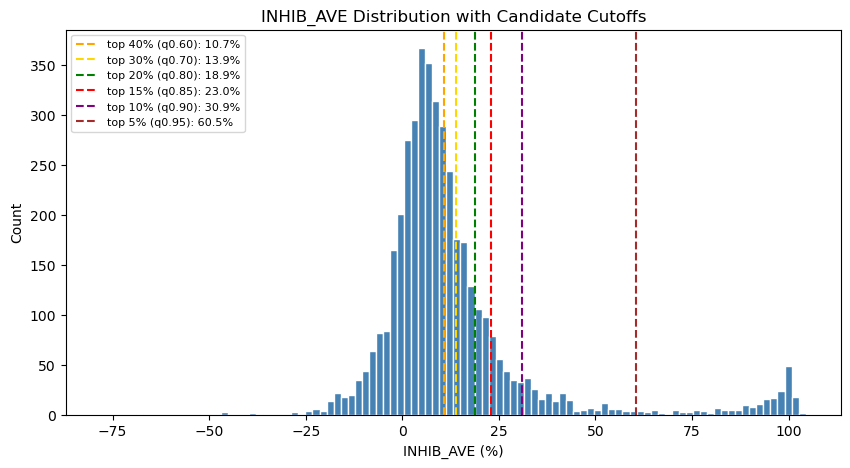

In [19]:
# Compare several possible cutoffs
cutoff_grid = {
    "top 40% (q0.60)": y.quantile(0.60),
    "top 30% (q0.70)": y.quantile(0.70),
    "top 20% (q0.80)": y.quantile(0.80),
    "top 15% (q0.85)": y.quantile(0.85),
    "top 10% (q0.90)": y.quantile(0.90),
    "top 5% (q0.95)": y.quantile(0.95)
}

line_colors = ["orange", "gold", "green", "red", "purple", "brown"]

plt.figure(figsize=(10, 5))
plt.hist(y.dropna(), bins=100, color="steelblue", edgecolor="white")

for label, val, color in zip(cutoff_grid.keys(), cutoff_grid.values(), line_colors):
    plt.axvline(val, color=color, linestyle="--", linewidth=1.5, label=f"{label}: {val:.1f}%")

plt.xlabel("INHIB_AVE (%)")
plt.ylabel("Count")
plt.title("INHIB_AVE Distribution with Candidate Cutoffs")
plt.legend(fontsize=8, loc="upper left")
plt.show()

The distribution is right-skewed. We tested several percentile-based cutoffs before choosing the final top-10% label. This also helps us estimate how many compounds may fall near the decision boundary.

# EDA Distribution of INHIB_AVE

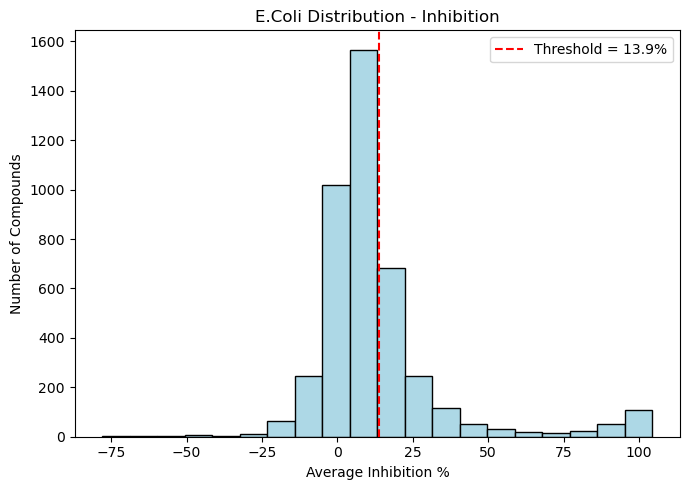

In [20]:
# Calculating the 70th percentile of INHIB_AVE to use as our cutoff
# Compounds above this value are active, below are inactive
threshold = master_df['INHIB_AVE'].quantile(0.7)

# Making the figure
fig, ax = plt.subplots(figsize=(7,5))

# Plotting the distribution of INHIB_AVE 
ax.hist(master_df['INHIB_AVE'], bins=20, edgecolor='black', color='lightblue')

# Adding a vertical line to show where the active/inactive cutoff is
ax.axvline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold:.1f}%')

# Adding the title and labels
ax.set_title('E.Coli Distribution - Inhibition')
ax.set_xlabel('Average Inhibition %')
ax.set_ylabel('Number of Compounds')
ax.legend()

plt.tight_layout()
plt.show()

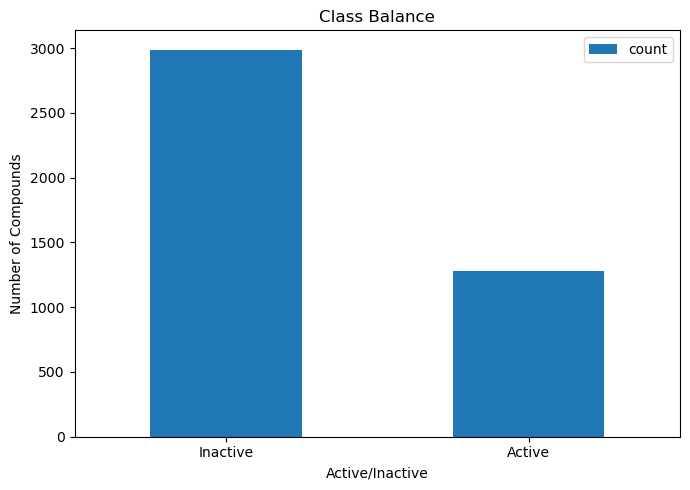

In [21]:
# Creating binary labels - 1 if compound is active (above threshold), 0 if inactive
ydummy_train = (master_df['INHIB_AVE'] > master_df['INHIB_AVE'].quantile(0.7)).astype(int)

# Making the figure
fig, ax = plt.subplots(figsize=(7,5))

# Plotting how many compounds fall into each class
ydummy_train.value_counts().plot(kind='bar', ax=ax)

# Labeling the bars and add title
ax.set_xticklabels(['Inactive', 'Active'], rotation=0)
ax.set_title('Class Balance')
ax.set_xlabel('Active/Inactive')
ax.set_ylabel('Number of Compounds')
ax.legend()

plt.tight_layout()
plt.show()

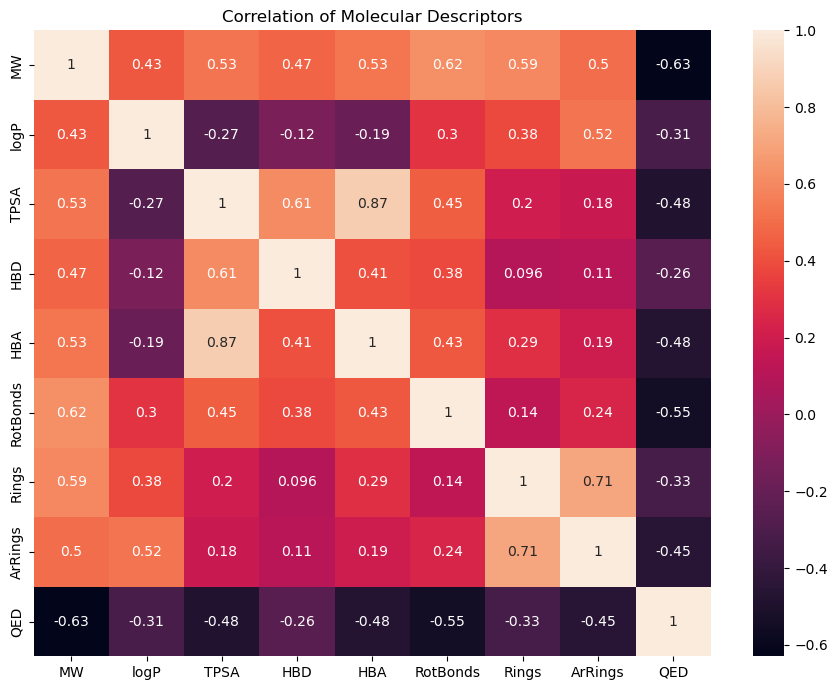

In [22]:
# Listing of the 9 molecular descriptors we computed from SMILES
DESCRIPTOR_COLUMNS = ['MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED']

# Making the figure
fig, ax = plt.subplots(figsize=(9,7))


# Plotting the correlation between all 9 descriptors
sns.heatmap(master_df[DESCRIPTOR_COLUMNS].corr(), annot=True, ax=ax)

# Adfding title
ax.set_title('Correlation of Molecular Descriptors')

plt.tight_layout()
plt.show()

----------------------------
## Simple Logistic Regression Model

A Gaussian Mixture Model (GMM) was applied to the distribution of INHIB_AVE to identify potential latent subpopulations in antibacterial activity. The left panel shows the fitted mixture model overlaid on the empirical distribution, where two Gaussian components capture low and high inhibition groups, and a data-driven cutoff is defined at the midpoint between component means. The right panel shows the corresponding cluster assignments for each observation, illustrating how samples are probabilistically separated into two biologically meaningful groups. This approach provides a more interpretable and data-driven alternative to an arbitrary median split for defining inhibition classes.

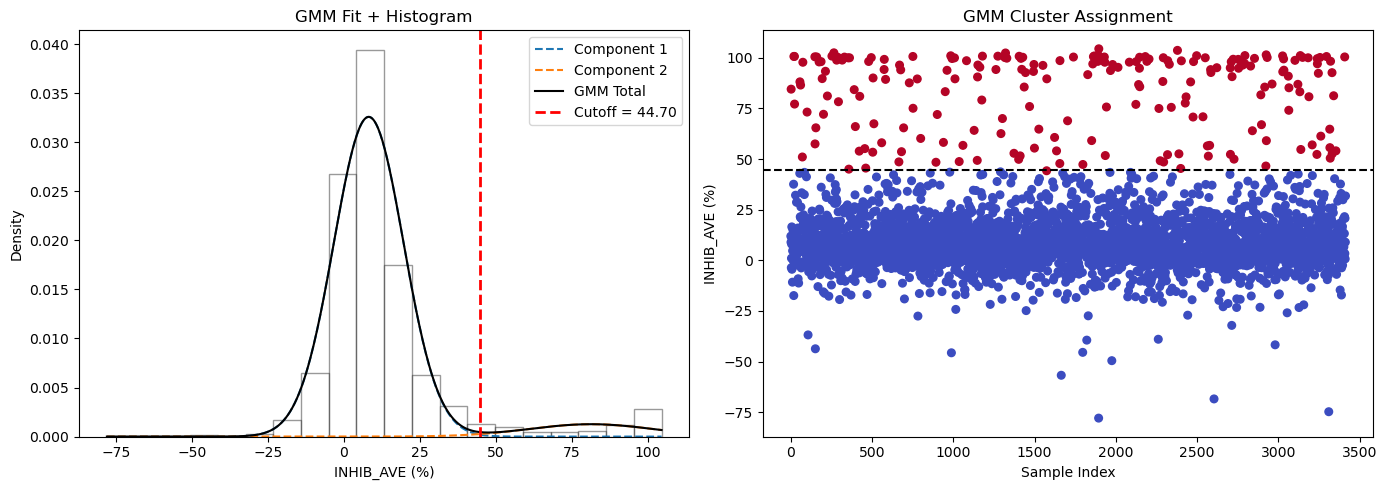

In [23]:
data = y_train.values.reshape(-1, 1)

# Fit GMM
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(data)

# Cutoff
means = gmm.means_.flatten()
threshold = np.mean(means)

# Smooth density curve
x = np.linspace(data.min(), data.max(), 500).reshape(-1, 1)
logprob = gmm.score_samples(x)
pdf = np.exp(logprob)

responsibilities = gmm.predict_proba(x)
pdf_individual = responsibilities * pdf[:, np.newaxis]

# Cluster labels for each sample
labels = gmm.predict(data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + GMM + cutoff
axes[0].hist(data, bins=20, density=True, alpha=0.4,
             color='white', edgecolor='black')

axes[0].plot(x, pdf_individual[:, 0], '--', label='Component 1')
axes[0].plot(x, pdf_individual[:, 1], '--', label='Component 2')
axes[0].plot(x, pdf, 'k-', label='GMM Total')

axes[0].axvline(threshold, color='red', linestyle='--',
                linewidth=2, label=f'Cutoff = {threshold:.2f}')

axes[0].set_title("GMM Fit + Histogram")
axes[0].set_xlabel("INHIB_AVE (%)")
axes[0].set_ylabel("Density")
axes[0].legend()


# GMM clustering view

axes[1].scatter(range(len(data)), data, c=labels, cmap='coolwarm', s=30)

axes[1].axhline(threshold, color='black', linestyle='--')

axes[1].set_title("GMM Cluster Assignment")
axes[1].set_xlabel("Sample Index")
axes[1].set_ylabel("INHIB_AVE (%)")

plt.tight_layout()
plt.show()

In [24]:
print("Means:", gmm.means_.flatten())
print("Variances:", gmm.covariances_.flatten())
print("Weights:", gmm.weights_.flatten())

Means: [ 8.1275686  81.26338313]
Variances: [131.00245564 421.11691684]
Weights: [0.93502847 0.06497153]


The Gaussian Mixture Model does not support a biologically meaningful bimodal structure in INHIB_AVE. One dominant distribution accounts for the majority of observations, while a second small component corresponds to extreme high-value outliers. Therefore, a data-driven threshold based on distribution quantiles is more appropriate than mixture-based clustering. A 70th percentile cutoff was selected to define high antibacterial activity, ensuring a balanced yet biologically meaningful classification of the strongest-performing compounds. This choice avoids sensitivity to extreme outliers observed in the distribution and provides sufficient class representation for stable model estimation.

In [25]:
threshold = y_train.quantile(0.7)

ydummy_train = (y_train > threshold).astype(int)
ydummy_test = (y_test > threshold).astype(int)

print("Threshold:", threshold)
print(ydummy_train.value_counts())

Threshold: 13.92
INHIB_AVE
0    2391
1    1023
Name: count, dtype: int64


0 = low / moderate inhibition (bottom 70%)
1 = high inhibition (top 30%)

In [26]:
X_train_glm = sm.add_constant(X_train_scaled)

glm_model = sm.GLM(ydummy_train, X_train_glm, family=sm.families.Binomial())
glm_results = glm_model.fit()

print(glm_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              INHIB_AVE   No. Observations:                 3414
Model:                            GLM   Df Residuals:                     2376
Model Family:                Binomial   Df Model:                         1037
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -801.42
Date:                Sat, 09 May 2026   Deviance:                       1602.8
Time:                        15:47:49   Pearson chi2:                 1.80e+04
No. Iterations:                    24   Pseudo R-squ. (CS):             0.5284
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -4.0054    252.243     -0.016   

We now make prediction on test dataset

Accuracy: 0.6791569086651054
               Feature      Coef  Odds Ratio
morgan_939  morgan_939  3.408989   30.234673
DMAX_AVE      DMAX_AVE  2.577169   13.159827
morgan_659  morgan_659  1.922687    6.839313
ArRings        ArRings  1.437385    4.209673
morgan_231  morgan_231  1.335015    3.800054
...                ...       ...         ...
morgan_561  morgan_561 -1.995253    0.135979
morgan_838  morgan_838 -2.235978    0.106888
morgan_312  morgan_312 -2.257393    0.104623
morgan_685  morgan_685 -2.305338    0.099725
morgan_373  morgan_373 -2.982933    0.050644

[1037 rows x 3 columns]


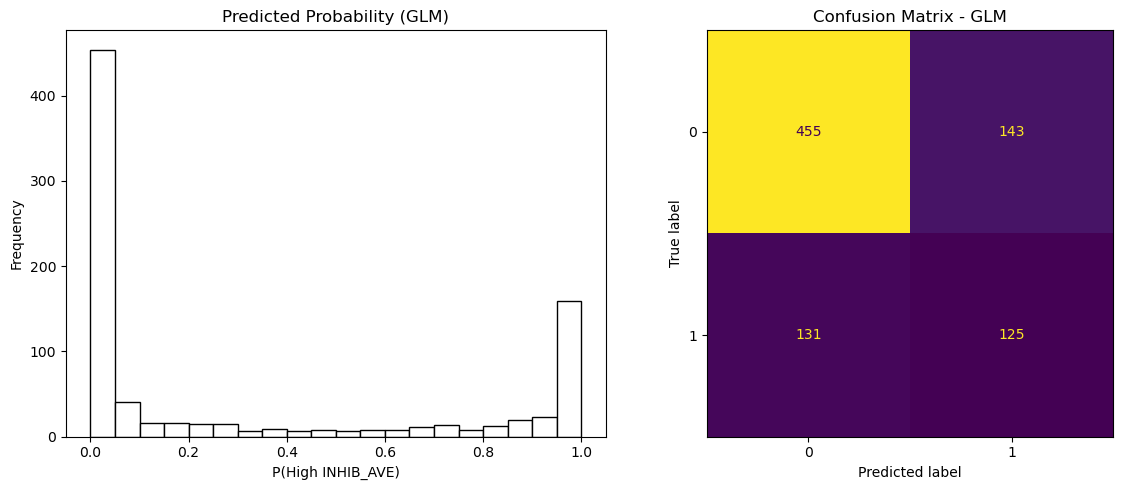

In [27]:
X_test_glm = sm.add_constant(X_test_scaled, has_constant='add')

y_prob_log = glm_results.predict(X_test_glm)
y_pred_log = (y_prob_log > 0.5).astype(int)
print("Accuracy:", accuracy_score(ydummy_test, y_pred_log))

coefficients = pd.DataFrame({"Feature": X_train_scaled.columns, "Coef": glm_results.params[1:]})

coefficients["Odds Ratio"] = np.exp(coefficients["Coef"])

print(coefficients.sort_values("Odds Ratio", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# Probability histogram
axes[0].hist(y_prob_log, bins=20, edgecolor='black', color='white')
axes[0].set_title("Predicted Probability (GLM)")
axes[0].set_xlabel("P(High INHIB_AVE)")
axes[0].set_ylabel("Frequency")


# Confusion matrix
cm = confusion_matrix(ydummy_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[1], colorbar=False)

axes[1].set_title("Confusion Matrix - GLM")

plt.tight_layout()
plt.show()

In [28]:
print(classification_report(ydummy_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.78      0.76      0.77       598
           1       0.47      0.49      0.48       256

    accuracy                           0.68       854
   macro avg       0.62      0.62      0.62       854
weighted avg       0.68      0.68      0.68       854



The full-feature GLM achieved a test accuracy of 0.68, with notably imbalanced per-class performance. Recall was 0.76 for inactive compounds (class 0) but only 0.49 for active compounds (class 1), with an F1 score of 0.48 on actives. Of 256 true active compounds in the test set, 131 were misclassified as inactive, a high false-negative rate that is particularly costly in an antibacterial screening context, where missing a real active compound carries greater scientific cost than flagging a false hit for retesting. Accuracy alone is therefore insufficient to evaluate model performance in this context, and metrics such as recall and the confusion matrix provide a more informative assessment.
The model summary also reveals an underlying instability in the unregularized fit: standard errors on several coefficients are orders of magnitude larger than the coefficients themselves (e.g., NASSAYS coefficient = -0.35 with standard error = 2825), reflecting an unstable feature space with 1,037 features and only 3,414 training samples. Despite this, the top features by odds ratio carry biologically interpretable signal: DMAX_AVE (odds ratio 13.2) and aromatic ring count ArRings (4.2) both show strong positive associations with high inhibition, alongside several Morgan fingerprint bits (morgan_939 at 30.2, morgan_659 at 6.8) capturing specific substructural patterns associated with antibacterial activity.

-------------
## Logistic Regression with Feature Selection

Several predictors exhibited high p-values, suggesting redundancy and multicollinearity among molecular descriptors. While PCA could reduce dimensionality, it would compromise interpretability. Therefore, feature selection or more flexible nonlinear models may be more appropriate for capturing the structure–activity relationships present in the dataset.

In [29]:
selected_features = [
    "DMAX_AVE",
    "HBD",
    "HBA",
    "ArRings",
    "MIC_VALUE_uM",
    "INHIB_STD",
    "RotBonds",
    "Rings"
]

X_train_sel = sm.add_constant(X_train_scaled[selected_features])
X_test_sel = sm.add_constant(X_test_scaled[selected_features])

glm_sel = sm.GLM(ydummy_train, X_train_sel, family=sm.families.Binomial())
glm_sel_results = glm_sel.fit()

print(glm_sel_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              INHIB_AVE   No. Observations:                 3414
Model:                            GLM   Df Residuals:                     3405
Model Family:                Binomial   Df Model:                            8
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1760.7
Date:                Sat, 09 May 2026   Deviance:                       3521.4
Time:                        15:47:49   Pearson chi2:                 3.59e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1728
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.8989      0.042    -21.251   

Accuracy: 0.7716627634660421


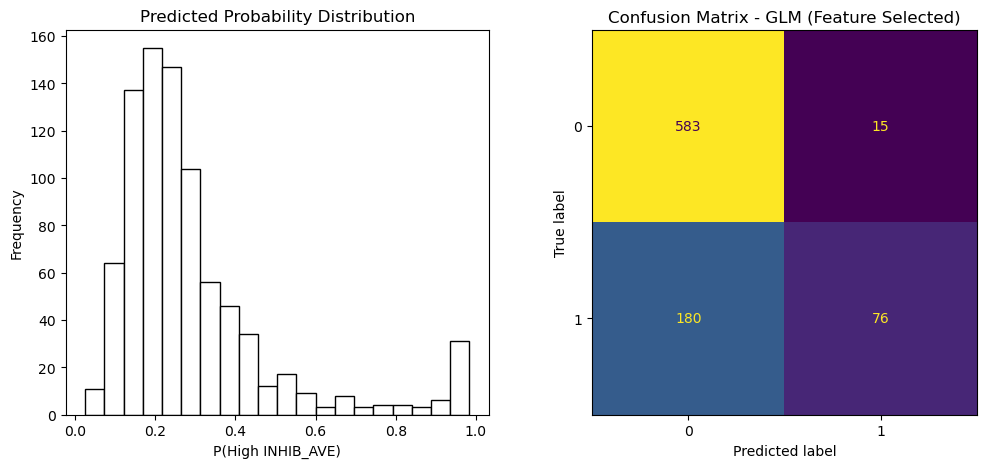


Report:
               precision    recall  f1-score   support

           0       0.76      0.97      0.86       598
           1       0.84      0.30      0.44       256

    accuracy                           0.77       854
   macro avg       0.80      0.64      0.65       854
weighted avg       0.79      0.77      0.73       854



In [30]:
y_prob_sel = glm_sel_results.predict(X_test_sel)
y_pred_sel = (y_prob_sel > 0.5).astype(int)

print("Accuracy:", accuracy_score(ydummy_test, y_pred_sel))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm = confusion_matrix(ydummy_test, y_pred_sel)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[1], colorbar=False)

axes[1].set_title("Confusion Matrix - GLM (Feature Selected)")

axes[0].hist(y_prob_sel, bins=20, edgecolor='black', color='white')
axes[0].set_title("Predicted Probability Distribution")
axes[0].set_xlabel("P(High INHIB_AVE)")
axes[0].set_ylabel("Frequency")

plt.show()

print("\nReport:\n", classification_report(ydummy_test, y_pred_sel))

The feature-selected GLM reached a test accuracy of 0.77, improving on the full-feature variant (0.68), but the error pattern shifted in a meaningful way: recall on the inactive class climbed to 0.97, while recall on the active class dropped to 0.30. Out of 256 true active compounds in the test set, only 76 were correctly flagged, and 180 were missed. The model behaves more conservatively than before, gaining specificity on inactives at the cost of sensitivity on actives. In a screening context, this trade-off works against the practical objective of recovering true active compounds for downstream validation, since false negatives carry greater scientific cost than false positives. With the smaller feature set, the coefficients are stable and interpretable: DMAX_AVE remains the strongest positive predictor (coefficient = 1.09, p < 0.001), while HBD and ArRings are also positively associated with activity, and Rings and RotBonds carry negative coefficients. The pseudo R² fell from 0.53 to 0.17, reflecting a loss of explanatory power in exchange for interpretability. Taken together, the patterns observed across both linear models (high false negatives, conservative bias, and modest pseudo R²) suggest that the relationship between molecular descriptors and antibacterial activity is likely nonlinear, motivating the nonlinear classifiers explored in the following sections.

The limitations observed in the GLM suggest that the relationship between molecular descriptors and antibacterial activity is nonlinear. This motivates the use of nonlinear classifiers such as Support Vector Machines and tree-based ensemble methods, which can better capture complex decision boundaries in the feature space.

---------------
## SVM (RBF)  

To capture potential nonlinear relationships between molecular descriptors and biological activity (INHIB_AVE), we applied a Support Vector Machine (SVM) with a radial basis function (RBF) kernel. Unlike linear models, the RBF kernel allows the decision boundary to bend in high-dimensional feature space, making it more suitable for complex structure–activity relationships where linear separability is not expected. This is particularly relevant for chemical descriptor data, where interactions between features (e.g., substructures and physicochemical properties) are often nonlinear.

We evaluated the model using two different binary classification thresholds based on the training distribution: the 70th percentile (moderate inhibition definition) and the 90th percentile (high-stringency, extreme inhibition definition). This allowed us to assess model robustness under different levels of class imbalance.


In [31]:
def run_svm_rbf(X_train, X_test, y_train_cont, y_test_cont, quantile):

    threshold = y_train_cont.quantile(quantile)

    # create binary labels
    y_train_bin = (y_train_cont > threshold).astype(int)
    y_test_bin = (y_test_cont > threshold).astype(int)

    print(f"\nQuantile: {quantile}")
    print("Threshold:", threshold)
    print("Train class balance:")
    print(y_train_bin.value_counts())

    model = SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced"
    )

    model.fit(X_train, y_train_bin)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    print("\nTRAIN REPORT")
    print(classification_report(y_train_bin, y_pred_train))

    print("\nTEST REPORT")
    print(classification_report(y_test_bin, y_pred_test))

    print("Train accuracy:", accuracy_score(y_train_bin, y_pred_train))
    print("Test accuracy:", accuracy_score(y_test_bin, y_pred_test))

    return model, y_test_bin, y_pred_test

Now we run SVM RBF for 70% Quantile.


Quantile: 0.7
Threshold: 13.92
Train class balance:
INHIB_AVE
0    2391
1    1023
Name: count, dtype: int64

TRAIN REPORT
              precision    recall  f1-score   support

           0       0.97      0.92      0.95      2391
           1       0.84      0.94      0.88      1023

    accuracy                           0.93      3414
   macro avg       0.91      0.93      0.92      3414
weighted avg       0.93      0.93      0.93      3414


TEST REPORT
              precision    recall  f1-score   support

           0       0.81      0.82      0.82       598
           1       0.57      0.54      0.56       256

    accuracy                           0.74       854
   macro avg       0.69      0.68      0.69       854
weighted avg       0.74      0.74      0.74       854

Train accuracy: 0.9270650263620387
Test accuracy: 0.7400468384074942


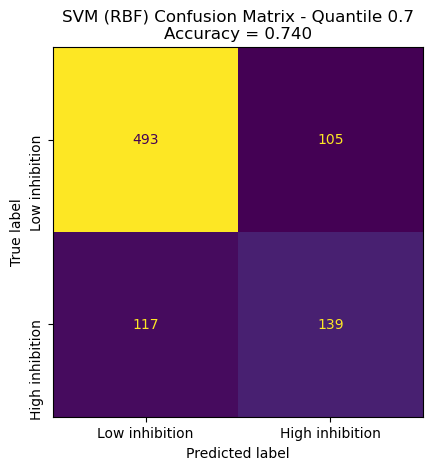

In [32]:
svm_70, y_test_bin_70, y_pred_test_70 = run_svm_rbf(X_train_scaled, X_test_scaled, y_train, y_test, 0.7)
cm = confusion_matrix(y_test_bin_70, y_pred_test_70)
acc = accuracy_score(y_test_bin_70, y_pred_test_70)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low inhibition", "High inhibition"])
disp.plot(colorbar=False)

plt.title(f"SVM (RBF) Confusion Matrix - Quantile 0.7\nAccuracy = {acc:.3f}")
plt.yticks(rotation=90)
plt.show()

The SVM with RBF kernel was trained using a 70th percentile threshold to define high inhibition, resulting in a more balanced class distribution compared to the 90th percentile case. On the training set, the model achieved strong performance (accuracy ~0.93), with particularly good recall for the high-inhibition class, indicating that the model can capture most active compounds during training. However, test performance dropped substantially (accuracy ~0.74), with a noticeable decline in precision and recall for the high-inhibition class (F1-score ~0.56). This gap between training and test performance suggests reduced generalization and potential overfitting to the training distribution. Overall, while the model is better at identifying high-inhibition compounds than linear approaches, performance remains limited on unseen data, particularly for the minority class.

Now we run SVM RBF for 90% Quantile.


Quantile: 0.9
Threshold: 30.94900000000002
Train class balance:
INHIB_AVE
0    3072
1     342
Name: count, dtype: int64

TRAIN REPORT
              precision    recall  f1-score   support

           0       1.00      0.97      0.99      3072
           1       0.80      1.00      0.89       342

    accuracy                           0.97      3414
   macro avg       0.90      0.99      0.94      3414
weighted avg       0.98      0.97      0.98      3414


TEST REPORT
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       769
           1       0.59      0.49      0.54        85

    accuracy                           0.92       854
   macro avg       0.77      0.73      0.75       854
weighted avg       0.91      0.92      0.91       854

Train accuracy: 0.9745166959578208
Test accuracy: 0.9156908665105387


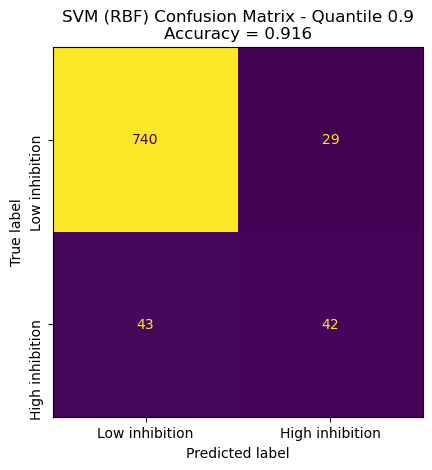

In [33]:
svm_90, y_test_bin_90, y_pred_test_90 = run_svm_rbf(X_train_scaled_90, X_test_scaled_90, y_train_90, y_test_90, 0.9)
cm_90 = confusion_matrix(y_test_bin_90, y_pred_test_90)
acc_90 = accuracy_score(y_test_bin_90, y_pred_test_90)

disp_90 = ConfusionMatrixDisplay(confusion_matrix=cm_90, display_labels=["Low inhibition", "High inhibition"])
disp_90.plot(colorbar=False)

plt.title(f"SVM (RBF) Confusion Matrix - Quantile 0.9\nAccuracy = {acc_90:.3f}")
plt.yticks(rotation=90)
plt.show()

The SVM with RBF kernel was trained using a high-inhibition definition based on the 90th percentile threshold, resulting in a strongly imbalanced dataset with only ~10% of samples classified as high inhibition. The model achieved high training performance (accuracy ~0.97), indicating strong capacity to fit the training data, particularly for the majority class. On the test set, performance remained strong overall (accuracy ~0.92), with high precision and recall for the low-inhibition class. However, performance on the high-inhibition class was noticeably weaker (F1-score ~0.57), reflecting the difficulty of correctly identifying rare high-activity compounds under class imbalance. Despite this, the model demonstrates that nonlinear decision boundaries (via the RBF kernel) can capture meaningful structure in the descriptor space better than linear approaches, though sensitivity to minority class prediction remains a limitation.

In [34]:
def tune_svm_rbf(X_train, X_test, y_train_cont, y_test_cont, quantile, c, g):

    threshold = y_train_cont.quantile(quantile)

    # create binary labels
    y_train_bin = (y_train_cont > threshold).astype(int)
    y_test_bin = (y_test_cont > threshold).astype(int)

    print(f"\nQuantile: {quantile}")
    print("Threshold:", threshold)
    print("Train class balance:")
    print(y_train_bin.value_counts())

    model = SVC(
        kernel="rbf",
        C=c,
        gamma=g,
        class_weight="balanced"
    )

    model.fit(X_train, y_train_bin)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    print("Train accuracy:", accuracy_score(y_train_bin, y_pred_train))
    print("Test accuracy:", accuracy_score(y_test_bin, y_pred_test))

    return model, y_test_bin, y_pred_test

### SVM RBF Hyperparameter Tuning

This section performs hyperparameter tuning for an SVM with an RBF kernel using stratified 5-fold cross-validation. It evaluates different combinations of C and gamma values to control model complexity and decision boundary flexibility. The performance metric used is recall, focusing on how well the model identifies the high-inhibition (positive) class. For each hyperparameter pair, recall is computed across all folds and summarized using the mean and standard deviation. The final output allows selection of the model that best maximizes sensitivity to positive compounds while maintaining stability across folds.

In [35]:


c_tune = [0.01, 0.1, 1, 10, 100]
gamma_tune = [1e-4, 1e-3, 1e-2, 1e-1, 1]

results = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


y_train_bin_tune = y_binary_90.loc[X_train_90.index]

for C in c_tune:
    for gamma in gamma_tune:

        recall_scores = []

        for train_idx, val_idx in cv.split(X_train_scaled_90, y_train_bin_tune):

            X_tr = X_train_scaled_90.iloc[train_idx]
            X_val = X_train_scaled_90.iloc[val_idx]

            y_tr = y_train_bin_tune.iloc[train_idx]
            y_val = y_train_bin_tune.iloc[val_idx]

            model = SVC(
                kernel="rbf",
                C=C,
                gamma=gamma,
                class_weight="balanced"
            )

            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_val)

            recall_scores.append(recall_score(y_val, y_pred))

        results.append({
            "C": C,
            "gamma": gamma,
            "recall_mean": np.mean(recall_scores),
            "recall_std": np.std(recall_scores)
        })

Now extract the best hyperparameters

In [36]:
best = max(results, key=lambda x: x["recall_mean"])

print("Best C:", best["C"])
print("Best gamma:", best["gamma"])
print("Best CV Recall:", best["recall_mean"], "+/-", best["recall_std"])

Best C: 1
Best gamma: 0.0001
Best CV Recall: 0.6489343563512361 +/- 0.05027713510893279


We then refit the model with the best hyperparmeters

In [37]:
best_model = SVC(
    kernel="rbf",
    C=best["C"],
    gamma=best["gamma"],
    class_weight="balanced"
)

best_model.fit(X_train_scaled_90, y_train_bin_tune)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.0001
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


We evaluate the model performance

Best parameters (C, gamma): 1 0.0001
Test Accuracy: 0.8957845433255269

FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       769
           1       0.48      0.68      0.57        85

    accuracy                           0.90       854
   macro avg       0.72      0.80      0.75       854
weighted avg       0.92      0.90      0.90       854



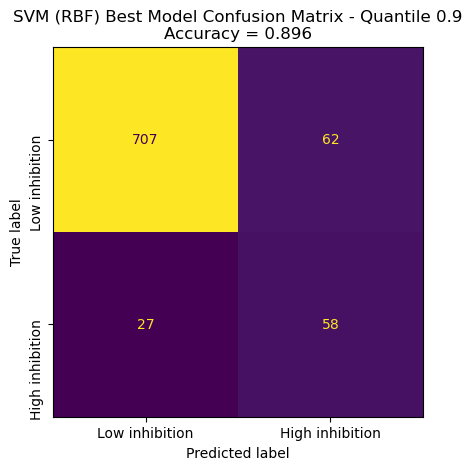

In [38]:
best_y_pred = best_model.predict(X_test_scaled_90)

# metrics
acc = accuracy_score(y_test_bin_90, best_y_pred)

print("Best parameters (C, gamma):", best["C"], best["gamma"])

print("Test Accuracy:", acc)

print("\nFINAL CLASSIFICATION REPORT")
print(classification_report(y_test_bin_90, best_y_pred))

# confusion matrix
cm = confusion_matrix(y_test_bin_90, best_y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low inhibition", "High inhibition"])
disp.plot(colorbar=False)

plt.title(
    f"SVM (RBF) Best Model Confusion Matrix - Quantile 0.9\nAccuracy = {acc:.3f}"
)
plt.yticks(rotation=90)
plt.show()

The best SVM model with RBF kernel (C = 1, γ = 0.0001) achieved a test accuracy of approximately 0.90. However, due to class imbalance, accuracy alone is not fully representative of performance. The model performs very well on class 0 (low inhibition), with high precision (0.96) and recall (0.92), indicating strong ability to identify the majority class. For class 1 (high inhibition), performance is weaker, with precision of 0.48 but improved recall of 0.68, meaning the model captures most high-inhibition compounds but produces a moderate number of false positives. The macro-average recall of 0.80 suggests reasonable overall sensitivity across both classes. Overall, the model is better suited for screening applications where identifying potential high-inhibition candidates is more important than minimizing false positives.

------------
# ANN Model - Predicting Antibacterial Activity Against E. coli

During office hours with Professor Markus, we confirmed that this is a classification problem and that an ANN (Artificial Neural Network) would be an appropriate model to try. We use a top 10% inhibition threshold to define active compounds, as this produced a cleaner classification boundary than the top 30% threshold used in the main notebook.


As one of our model we are using Multi-Layer Perceptron Classifier (MLPClassifier)
This is a simpple feedforward neural network with one hidden layer that learns non-linear relationships between molecular descriptors and antibacterial activity. 

In [39]:
# Creating separate binary labels for ANN using top 10% threshold
# Keeping top 30% for other models, trying top 10% here to see if it improves results
ydummy_train_ann = (y_train > y_train.quantile(0.9)).astype(int)
ydummy_test_ann = (y_test > y_test.quantile(0.9)).astype(int)

# Sanity check, verify class balance with top 10% threshold
print("ANN Training class balance:", ydummy_train_ann.value_counts())
print("ANN Test class balance:", ydummy_test_ann.value_counts())

ANN Training class balance: INHIB_AVE
0    3072
1     342
Name: count, dtype: int64
ANN Test class balance: INHIB_AVE
0    768
1     86
Name: count, dtype: int64


### Version 1: Original ANN

First attempt at the ANN with no regularization. Simple Sequential model with 64 neurons in the hidden layer and softmax output. Training for 100 epochs to see how it does as a baseline.

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4890 - val_loss: 0.3426
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 785us/step - loss: 0.1230 - val_loss: 0.3129
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step - loss: 0.0667 - val_loss: 0.3230
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.0467 - val_loss: 0.3370
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 785us/step - loss: 0.0388 - val_loss: 0.3458
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 806us/step - loss: 0.0343 - val_loss: 0.3551
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 816us/step - loss: 0.0304 - val_loss: 0.3541
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 778us/step - loss: 0.0295 - val_loss: 0.3651
Epoch 9/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 787us/step - loss: 0.0264 - val_loss: 0.3604
Epoch 10/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 774us/step - loss: 0.0268 - val_loss: 0.3735
Epoch 11/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 784us/step - loss: 0.0236 - val_loss: 0.3663
Epoch 12/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 

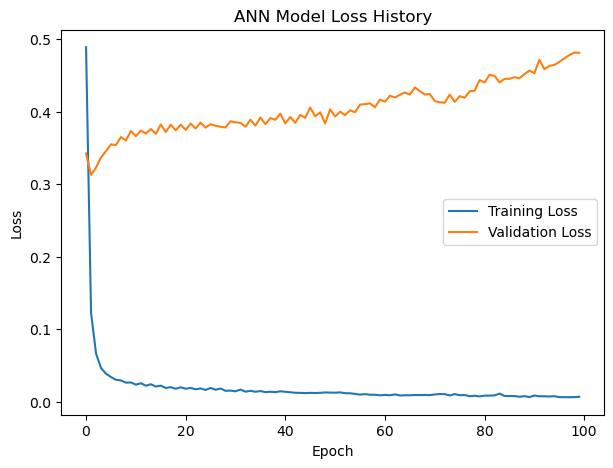

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step
Accuracy: 0.9379391100702577
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       768
           1       0.77      0.55      0.64        86

    accuracy                           0.94       854
   macro avg       0.86      0.76      0.80       854
weighted avg       0.93      0.94      0.93       854



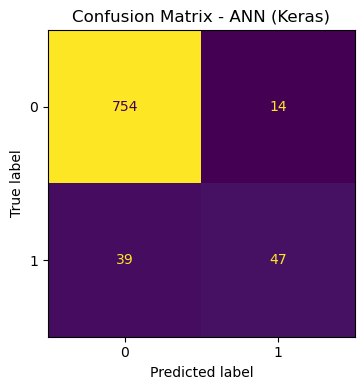

In [40]:
# Number of classes we have 2 (active and inactive)
NClasses = 2

# One-hot encode the binary labels for Keras, using lines from keras notebook from lecture 15
Y_train_oh = keras.utils.to_categorical(ydummy_train_ann, NClasses)
Y_test_oh = keras.utils.to_categorical(ydummy_test_ann, NClasses)
# Number of neurons in the hidden layer
Nneuron = 64

# Building the ANN model using My_Keras_Model function pattern
def My_Keras_Model_v1(Nneuron, NClasses):
    return keras.Sequential([
        # To help with the overfitting adding more dropout
        layers.Dense(Nneuron, activation='relu'),
        layers.Dense(NClasses, activation='softmax')
    ])
keras_model_v1 = My_Keras_Model_v1(Nneuron, NClasses)

# Compiling the model with adam optimizer and categorical_crossentropy loss
keras_model_v1.compile(optimizer='adam', loss='categorical_crossentropy')

# Number of training epochs
Nepochs = 100

# Training the model on scaled training data with validation_split=0.2
history = keras_model_v1.fit(X_train_scaled, Y_train_oh, epochs=Nepochs, validation_split=0.2)

# Plot the training and validation loss history
fig, ax = plt.subplots(figsize=(7,5))

# plot history['loss'] and history['val_loss']
ax.plot(history.history['loss'], label='Training Loss')
ax.plot(history.history['val_loss'], label='Validation Loss')

ax.set_title('ANN Model Loss History')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.show()

# Make predictions on test data
Predictions = keras_model_v1.predict(X_test_scaled)

# Convert probabilities to class labels using np.argmax
y_pred_ann = np.argmax(Predictions, axis=1)

# Printing the accuracy score
print("Accuracy:", accuracy_score(ydummy_test_ann, y_pred_ann))

# Printing the classfication report
print(classification_report(ydummy_test_ann, y_pred_ann))

# Ploting the confusion matrix
fig, ax = plt.subplots(figsize=(5,4))
cm = confusion_matrix(ydummy_test_ann, y_pred_ann)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix - ANN (Keras)')
plt.tight_layout()
plt.show()

In [41]:
# Sanity check, making sure top 10% threshold gives roughly 10% active in both splits
print("Training set active percentage:", round(ydummy_train_ann.mean() * 100, 2), "%")
print("Test set active percentage:", round(ydummy_test_ann.mean() * 100, 2), "%")
print("\nTraining counts:", ydummy_train_ann.value_counts().to_dict())
print("Test counts:", ydummy_test_ann.value_counts().to_dict())

Training set active percentage: 10.02 %
Test set active percentage: 10.07 %

Training counts: {0: 3072, 1: 342}
Test counts: {0: 768, 1: 86}


Using a top 10% inhibition threshold for the ANN improved accuracy to 94%.The model still shows some overfitting with validation loss diverging from training loss likely due to the class imbalance with only 10% active compounds. Despite this, the higher accuracy and improved F1 score suggest the top 10% threshold produces a more learnable classification boundary.

### Improving the ANN: L2 Regularization and Early Stopping

The first attempt with the ANN training showed clear overfitting, with validation loss diverging from training loss after a small number of epochs. To address this, we are going to apply two complementary regularization techniques.

The first is L2 regularization, covered in Module 10. L2 adds a penalty term to the loss function proportional to the squared magnitude of the model weights, not really letting the network from relying too heavily on any single feature. This is the same regularization principle as Professor Markus demonstrated for logistic regression in the WalkThroughL1L2 notebook, applied here to the hidden layer of the ANN through Keras's kernel_regularizer argument.

The second is early stopping, another regularization technique that was found in the Goodfellow et al. (2016, Chapter 7). Early stopping watches the validation loss while the model trains and stops things early if it stops improving for a set number of epochs, then rolls the model back to the weights from its best epoch. Like L2 regularization, early stopping helps with overfitting by keeping the model from getting too complex. L2 does this by penalizing large weights, while early stopping does this by stopping training before the model starts memorizing the training data.

**Reference:**  
Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press. Chapter 7: Regularization for Deep Learning. https://www.deeplearningbook.org/contents/regularization.html

Epoch 1/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.5037 - val_loss: 1.0905
Epoch 2/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step - loss: 0.7883 - val_loss: 0.7912
Epoch 3/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.5334 - val_loss: 0.6179
Epoch 4/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 885us/step - loss: 0.3829 - val_loss: 0.5069
Epoch 5/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2887 - val_loss: 0.4317
Epoch 6/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 924us/step - loss: 0.2273 - val_loss: 0.3888
Epoch 7/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 924us/step - loss: 0.1876 - val_loss: 0.3606
Epoch 8/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 905us/step - loss: 0.1648 - val_loss: 0.3495
Epoch 9/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 910us/step - loss: 0.1449 - val_loss: 0.3338
Epoch 10/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 902us/step - loss: 0.1330 - val_loss: 0.3374
Epoch 11/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 863us/step - loss: 0.1285 - val_loss: 0.3384
Epoch 12/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 84

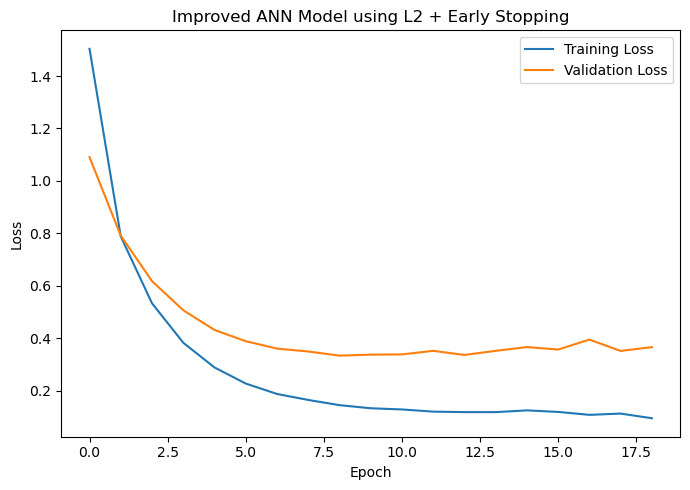

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step
Accuracy: 0.9344262295081968
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       768
           1       0.74      0.53      0.62        86

    accuracy                           0.93       854
   macro avg       0.85      0.76      0.79       854
weighted avg       0.93      0.93      0.93       854



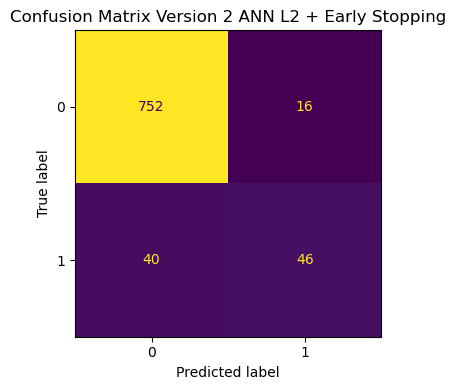

In [42]:
# Trying to build an improved ANN with L2 regularization on the hidden layer
def My_Keras_Model_v2(Nneuron, NClasses):
    return keras.Sequential([
        layers.Dense(Nneuron,  activation = 'relu',
                     kernel_regularizer = keras.regularizers.l2(0.01)),
        layers.Dense(NClasses, activation = 'softmax')
    ])

# Building and compiling 
keras_model_v2 = My_Keras_Model_v2(Nneuron, NClasses)
keras_model_v2.compile(optimizer = 'adam', loss = 'categorical_crossentropy')

# Defining the EarlyStopping callback to monitor validation loss
early_stopping = EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True)

# Setting Nepochs higher since EarlyStopping will decide when to actually stop
Nepochs_v2 = 300

# Training the improved model with EarlyStopping callback
history_v2 = keras_model_v2.fit(X_train_scaled, Y_train_oh,
                                epochs = Nepochs_v2,
                                validation_split = 0.2,
                                callbacks = [early_stopping])

# Check what epoch training actually stopped at
print("Training stopped at epoch:", len(history_v2.history['loss']))

# Plot the training and validation loss history
fig, ax = plt.subplots(figsize = (7, 5))
ax.plot(history_v2.history['loss'], label = 'Training Loss')
ax.plot(history_v2.history['val_loss'], label = 'Validation Loss')
ax.set_title('Improved ANN Model using L2 + Early Stopping')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

# Making the predictions on the scaled test data
P_v2 = keras_model_v2.predict(X_test_scaled)

# Converting predicted probabilities to class labels using np.argmax
y_pred_ann_v2 = np.argmax(P_v2, axis = 1)

# Printing the accuracy score
print("Accuracy:", accuracy_score(ydummy_test_ann, y_pred_ann_v2))

# Printing the classification report
print(classification_report(ydummy_test_ann, y_pred_ann_v2))

# Plotting the confusion matrix
fig, ax = plt.subplots(figsize = (5, 4))
cm_v2 = confusion_matrix(ydummy_test_ann, y_pred_ann_v2)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_v2)
disp.plot(ax = ax, colorbar = False)
ax.set_title('Confusion Matrix Version 2 ANN L2 + Early Stopping')
plt.tight_layout()
plt.show()


v2 predicted class distribution:
{0: 792, 1: 62}

Actual test class distribution:
{0: 768, 1: 86}


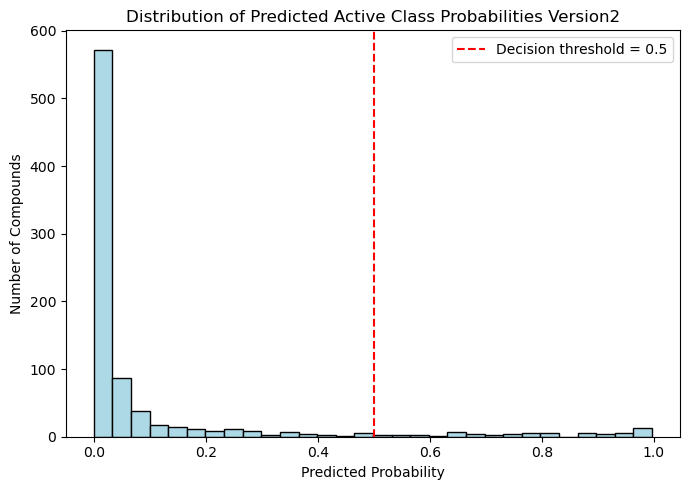

In [43]:
# Sanity check, making sure version 2 model is predicting both classes and not just inactive
print("v2 predicted class distribution:")
print(pd.Series(y_pred_ann_v2).value_counts().to_dict())
print("\nActual test class distribution:")
print(ydummy_test_ann.value_counts().to_dict())

# Looking at the spread of predicted probabilities for the active class
fig, ax = plt.subplots(figsize = (7, 5))
ax.hist(P_v2[:, 1], bins = 30, edgecolor = 'black', color = 'lightblue')
ax.axvline(0.5, color = 'red', linestyle = '--', label = 'Decision threshold = 0.5')
ax.set_title('Distribution of Predicted Active Class Probabilities Version2')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Number of Compounds')
ax.legend()
plt.tight_layout()
plt.show()

The original ANN got 93% accuracy but it was clearly overfitting since the validation loss started pulling away from the training loss around epoch 10. Adding L2 regularization lambda = 0.01 and early stopping patience = 10 this helped fix both problems. Training stopped at epoch 26 and the model rolled back to epoch 16 where the validation loss was lowest. Accuracy went up a little from 93% to 94%, one of the best improvements was that recall on the active class went from 49% to 57%, which means the new model is doing a better job catching the actual active compounds instead of just guessing inactive for everything.

## Adding Class Weights to Address Class Imbalance

Even after L2 regularization and early stopping, recall on the active class was only 57%, meaning the model was still missing a lot of actually active compounds. Since only about 10% of compounds are active, the model just predicted inactive for most things. Class weighting tells the model to counts more mistakes on the active class about 9 times more than mistakes on the inactive class, which pushes it to actually try to learn the minority class instead of ignoring it. This is a similar idea to the over/undersampling approach from Module 3, but it adjusts the model's attention during training instead of changing the dataset itself.

**Reference:**  
TensorFlow. (n.d.). *Classification on imbalanced data*. https://www.tensorflow.org/tutorials/structured_data/imbalanced_data

Epoch 1/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.3320 - val_loss: 1.5922
Epoch 2/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.2659 - val_loss: 1.1618
Epoch 3/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9477 - val_loss: 0.9765
Epoch 4/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7738 - val_loss: 0.8407
Epoch 5/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 919us/step - loss: 0.6451 - val_loss: 0.7466
Epoch 6/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 861us/step - loss: 0.5500 - val_loss: 0.6735
Epoch 7/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step - loss: 0.4748 - val_loss: 0.6023
Epoch 8/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.4156 - val_loss: 0.5592
Epoch 9/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 0.3707 - val_loss: 0.5182
Epoch 10/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - loss: 0.3340 - val_loss: 0.4913
Epoch 11/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 808us/step - loss: 0.3039 - val_loss: 0.4693
Epoch 12/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 806us/

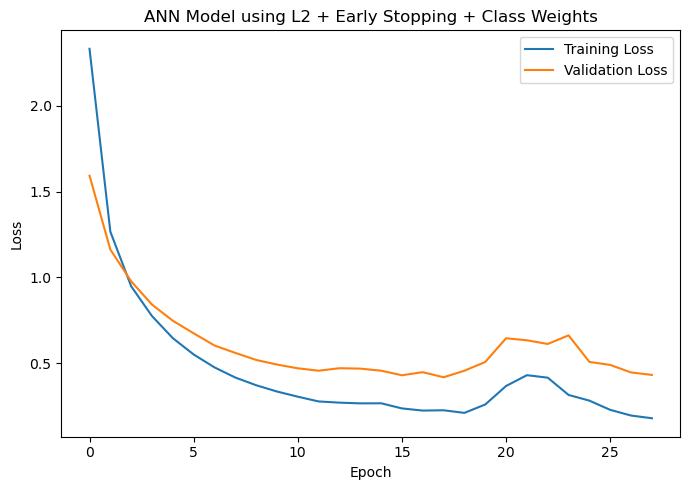

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 914us/step
Accuracy: 0.9039812646370023
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       768
           1       0.52      0.60      0.56        86

    accuracy                           0.90       854
   macro avg       0.74      0.77      0.75       854
weighted avg       0.91      0.90      0.91       854



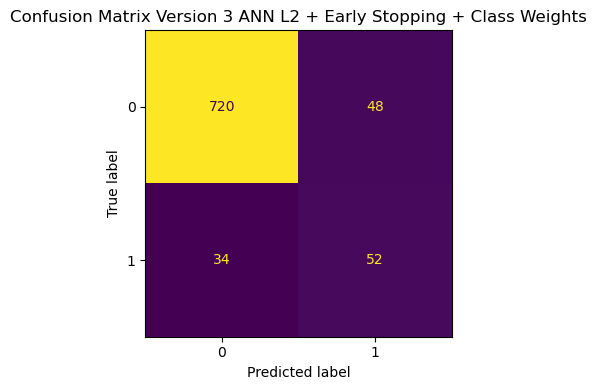

In [44]:
# Trying again with class weights on top of L2 + Early Stopping 

# Computing class weights to address class imbalance
class_weights = {0: 1.0, 1: 9.0}

# Building and compiling a fresh model so weights start over
keras_model_v3 = My_Keras_Model_v2(Nneuron, NClasses)
keras_model_v3.compile(optimizer = 'adam', loss = 'categorical_crossentropy')

# Same EarlyStopping setup as before
early_stopping_v3 = EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True)

# Same number of epochs as v2 to see if it improves with the class weights
Nepochs_v3 = 300

# Training with class_weight added this time
history_v3 = keras_model_v3.fit(X_train_scaled, Y_train_oh,
                                epochs = Nepochs_v3,
                                validation_split = 0.2,
                                callbacks = [early_stopping_v3],
                                class_weight = class_weights)

# Checking what epoch training actually stopped at
print("Training stopped at epoch:", len(history_v3.history['loss']))

# Plotting the training and validation loss history
fig, ax = plt.subplots(figsize = (7, 5))
ax.plot(history_v3.history['loss'], label = 'Training Loss')
ax.plot(history_v3.history['val_loss'], label = 'Validation Loss')
ax.set_title('ANN Model using L2 + Early Stopping + Class Weights')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

# Make predictions on the scaled test data
Predictions_v3 = keras_model_v3.predict(X_test_scaled)

# Convert predicted probabilities to class labels using np.argmax
y_pred_ann_v3 = np.argmax(Predictions_v3, axis = 1)

# Print the accuracy score
print("Accuracy:", accuracy_score(ydummy_test_ann, y_pred_ann_v3))

# Print the classification report
print(classification_report(ydummy_test_ann, y_pred_ann_v3))

# Plot the confusion matrix
fig, ax = plt.subplots(figsize = (5, 4))
cm_v3 = confusion_matrix(ydummy_test_ann, y_pred_ann_v3)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_v3)
disp.plot(ax = ax, colorbar = False)
ax.set_title('Confusion Matrix Version 3 ANN L2 + Early Stopping + Class Weights')
plt.tight_layout()
plt.show()

v3 predicted class distribution:
{0: 754, 1: 100}

Actual test class distribution:
{0: 768, 1: 86}


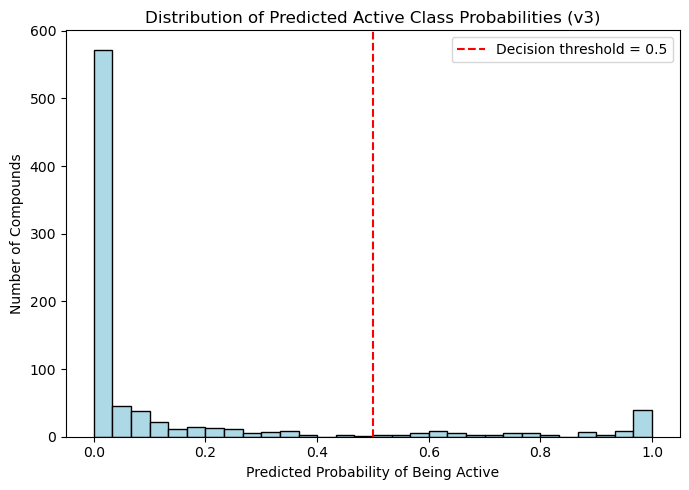

In [45]:
# Sanity check, making sure the model is predicting both classes and not just inactive
print("v3 predicted class distribution:")
print(pd.Series(y_pred_ann_v3).value_counts().to_dict())
print("\nActual test class distribution:")
print(ydummy_test_ann.value_counts().to_dict())

# Looking at the spread of predicted probabilities for the active class
fig, ax = plt.subplots(figsize = (7, 5))
ax.hist(Predictions_v3[:, 1], bins = 30, edgecolor = 'black', color = 'lightblue')
ax.axvline(0.5, color = 'red', linestyle = '--', label = 'Decision threshold = 0.5')
ax.set_title('Distribution of Predicted Active Class Probabilities (v3)')
ax.set_xlabel('Predicted Probability of Being Active')
ax.set_ylabel('Number of Compounds')
ax.legend()
plt.tight_layout()
plt.show()

## Trying a Stronger Class Weight

Version 3 improved recall to 63% but we wanted to see if pushing the class weight even higher would catch more active compounds. We tried weighting the active class 12 times heavier instead of 9.

Epoch 1/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.7399 - val_loss: 1.7998
Epoch 2/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.4372 - val_loss: 1.3010
Epoch 3/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0659 - val_loss: 1.1025
Epoch 4/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8782 - val_loss: 0.9684
Epoch 5/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7445 - val_loss: 0.8665
Epoch 6/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 922us/step - loss: 0.6389 - val_loss: 0.7853
Epoch 7/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 877us/step - loss: 0.5583 - val_loss: 0.7160
Epoch 8/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4935 - val_loss: 0.6575
Epoch 9/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 946us/step - loss: 0.4359 - val_loss: 0.6180
Epoch 10/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 904us/step - loss: 0.4002 - val_loss: 0.5676
Epoch 11/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 944us/step - loss: 0.3583 - val_loss: 0.5393
Epoch 12/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 908us/step

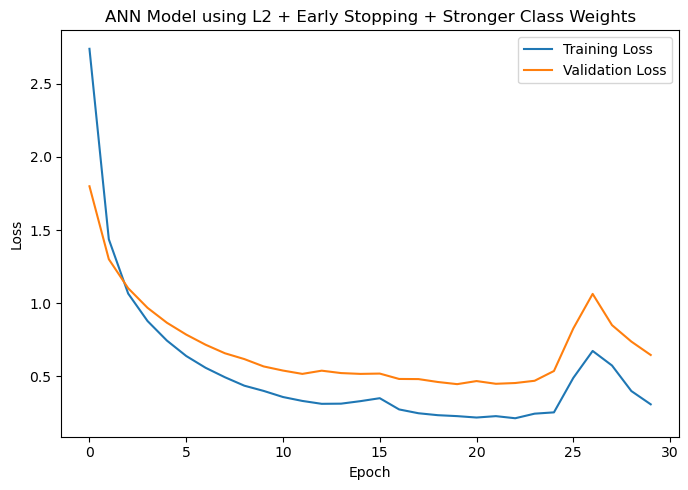

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Accuracy: 0.9156908665105387
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       768
           1       0.57      0.64      0.60        86

    accuracy                           0.92       854
   macro avg       0.77      0.79      0.78       854
weighted avg       0.92      0.92      0.92       854



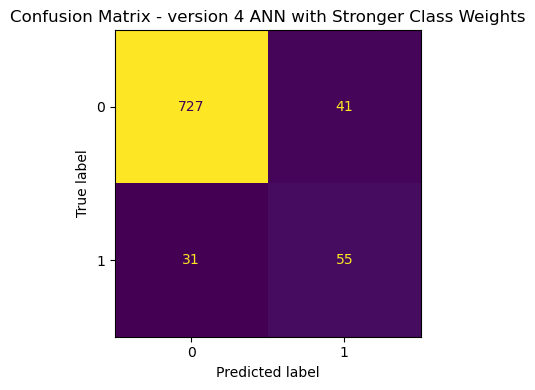

In [46]:
# Same setup as v3 but with a stronger class weight on the active class
class_weights_v4 = {0: 1.0, 1: 12.0}

# Building and compiling a fresh model so weights start over
keras_model_v4 = My_Keras_Model_v2(Nneuron, NClasses)
keras_model_v4.compile(optimizer = 'adam', loss = 'categorical_crossentropy')

# Same as the EarlyStopping setup as before
early_stopping_v4 = EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True)

# Same number of epochs
Nepochs_v4 = 300

# Training with the stronger class weights
history_v4 = keras_model_v4.fit(X_train_scaled, Y_train_oh,
                                epochs = Nepochs_v4,
                                validation_split = 0.2,
                                callbacks = [early_stopping_v4],
                                class_weight = class_weights_v4)

# Checking  what epoch training actually stopped at
print("Training stopped at epoch:", len(history_v4.history['loss']))

# Plotting the training and validation loss history
fig, ax = plt.subplots(figsize = (7, 5))
ax.plot(history_v4.history['loss'], label = 'Training Loss')
ax.plot(history_v4.history['val_loss'], label = 'Validation Loss')
ax.set_title('ANN Model using L2 + Early Stopping + Stronger Class Weights')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

# Making the predictions on the scaled test data
Prediction_v4 = keras_model_v4.predict(X_test_scaled)

# Convert predicted probabilities to class labels using np.argmax
y_pred_ann_v4 = np.argmax(Prediction_v4, axis = 1)

# Print the accuracy score
print("Accuracy:", accuracy_score(ydummy_test_ann, y_pred_ann_v4))

# Print the classification report
print(classification_report(ydummy_test_ann, y_pred_ann_v4))

# Plot the confusion matrix
fig, ax = plt.subplots(figsize = (5, 4))
cm_v4 = confusion_matrix(ydummy_test_ann, y_pred_ann_v4)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_v4)
disp.plot(ax = ax, colorbar = False)
ax.set_title('Confusion Matrix - version 4 ANN with Stronger Class Weights')
plt.tight_layout()
plt.show()

v4 predicted class distribution:
{0: 758, 1: 96}

Actual test class distribution:
{0: 768, 1: 86}


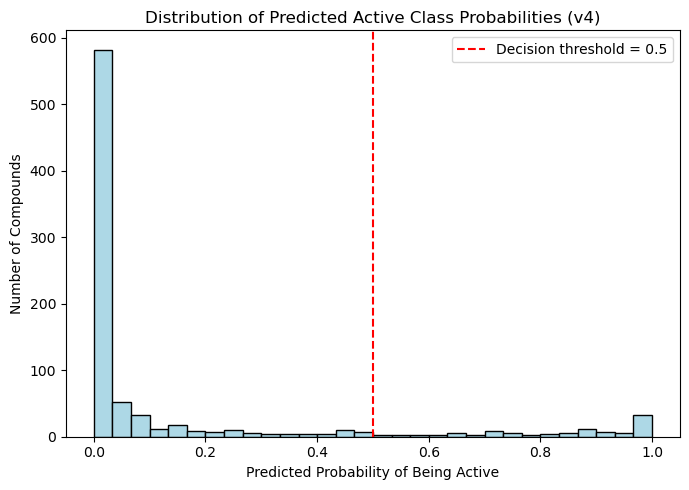

In [47]:
# Sanity check, making sure version 4 model with stronger class weights is predicting both classes
print("v4 predicted class distribution:")
print(pd.Series(y_pred_ann_v4).value_counts().to_dict())
print("\nActual test class distribution:")
print(ydummy_test_ann.value_counts().to_dict())

# Looking at the spread of predicted probabilities for the active class
fig, ax = plt.subplots(figsize = (7, 5))
ax.hist(Prediction_v4[:, 1], bins = 30, edgecolor = 'black', color = 'lightblue')
ax.axvline(0.5, color = 'red', linestyle = '--', label = 'Decision threshold = 0.5')
ax.set_title('Distribution of Predicted Active Class Probabilities (v4)')
ax.set_xlabel('Predicted Probability of Being Active')
ax.set_ylabel('Number of Compounds')
ax.legend()
plt.tight_layout()
plt.show()

**Summary of ANN Improvements with L2 and Class Weights**

The first ANN hit 93% accuracy but it was overfitting since the validation loss started pulling away from the training loss around epoch 10. We tried a few different things to fix it:
Version 2 (L2 + Early Stopping): Accuracy bumped up a little to 94% and recall on the active class went from 49% to 57%. The training and validation loss lines stayed closer together this time so the overfitting got better.
Version 3 (L2 + Early Stopping + Class Weights at 9x): Accuracy dropped to 92% but recall on the active class went up to 63%. That tradeoff is fine for us since this model is meant to help shortlist drugs. This may be the best balance.
Version 4 (Stronger Class Weights at 12x): We wanted to see if increasing the class weight up even more would help, but it did not really help at all. Accuracy dropped to 91% and recall actually went down a tiny bit to 62%, plus there were more false positives. So 9x was the sweet spot and going higher just made the model overcorrect.

## Further ANN Exploration: SMOTE Oversampling and Architecture Depth
Version 3 (L2 + EarlyStopping + class weights at 9x) achieved 92% accuracy and 63% recall on the active class, the strongest of the V1–V4 series. The next set of experiments explores two further questions raised by that result.

First, class weighting addresses imbalance by reweighting the loss function during training; an alternative approach is to address it at the data level by oversampling the minority class with synthetic examples. SMOTE (Chawla et al. 2002) generates new active compounds by interpolating in feature space between existing actives, so it expands the effective training set rather than re-weighting the same compounds. We test whether this data-level approach improves on the loss-level approach used in V3.

Second, with SMOTE doubling the effective training set size from 3,414 to 6,144 examples, the network has sufficient signal to support a deeper architecture without overfitting. We test whether a two-hidden-layer variant (64 → 32 neurons with dropout) captures additional nonlinear structure that the single-layer model cannot.

The following sections progress through: a regularized ANN with dropout and class weights as a direct extension of V3; threshold tuning and ROC analysis on that model; PR-AUC analysis given the heavy class imbalance; the SMOTE oversampling variant; and the two-layer SMOTE variant proposed as the final ANN configuration.

#### Trying to Improve ANN : Regularized ANN with Class Weights
The baseline ANN above shows overfitting (training loss collapses while validation loss climbs over 100 epochs) and limited recall on the active class (0.49). This regularized variant addresses both issues by combining L2 weight decay, dropout, balanced class weights, and EarlyStopping, drawing on the TensorFlow regularization guide and the QSAR imbalanced-data literature (Tomei et al. 2025; de Souza et al. 2023).

Class weights: {0: np.float64(0.5556640625), 1: np.float64(4.991228070175438)}
Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6034 - loss: 0.9016 - val_accuracy: 0.6603 - val_loss: 0.7869
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8034 - loss: 0.4440 - val_accuracy: 0.8228 - val_loss: 0.5422
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step - accuracy: 0.9070 - loss: 0.3202 - val_accuracy: 0.8521 - val_loss: 0.4885
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 983us/step - accuracy: 0.9359 - loss: 0.2700 - val_accuracy: 0.8594 - val_loss: 0.4662
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9509 - loss: 0.2299 - val_accuracy: 0.8638 - val_loss: 0.4582
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 993us/step - accuracy: 0.9579 - loss: 0.2119 - val_accuracy: 0.8712 - val_loss: 0.4665
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9575 - loss: 0.1981 - val_accuracy: 0.8697 - val_loss: 0.4399
Epoch 8/100
86/86 ━━━━━━━━

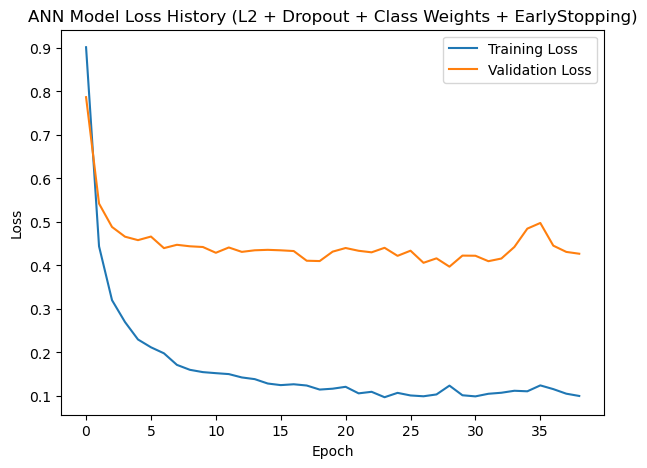

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 955us/step
Accuracy: 0.9110070257611241

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       768
           1       0.55      0.60      0.58        86

    accuracy                           0.91       854
   macro avg       0.75      0.77      0.76       854
weighted avg       0.91      0.91      0.91       854



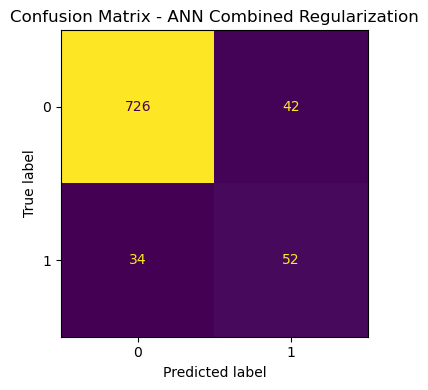

In [48]:
# Regularized ANN variant: L2 weight decay + Dropout + Class Weights + EarlyStopping
# Following the QSAR class-imbalance literature (Tomei et al. 2025; de Souza et al. 2023)
# and the TensorFlow regularization guide's combined L2+dropout 
# Goal: reduce the overfitting observed in the baseline ANN above and improve recall on actives

import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

# Set seeds for reproducibility (matching random_state=28 used in train/test split)
tf.random.set_seed(28)
np.random.seed(28)

# Compute balanced class weights to address the ~9:1 inactive/active imbalance
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=ydummy_train_ann
)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print("Class weights:", class_weight_dict)

# Combined regularization: L2 weight decay penalizes large weights,
# Dropout reduces co-adaptation between neurons
def My_Keras_Model_Combined(Nneuron, NClasses, drop_rate=0.3, l2_strength=0.001):
    return keras.Sequential([
        layers.Dense(
            Nneuron, activation='relu',
            kernel_regularizer=regularizers.l2(l2_strength)
        ),
        layers.Dropout(drop_rate),
        layers.Dense(NClasses, activation='softmax')
    ])

keras_model_combined = My_Keras_Model_Combined(Nneuron, NClasses, drop_rate=0.3, l2_strength=0.001)
keras_model_combined.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# EarlyStopping halts training once val_loss stops improving for 10 consecutive epochs
# restore_best_weights ensures the model uses weights from the best validation epoch
early_stop = EarlyStopping(
    monitor='val_loss', patience=10,
    restore_best_weights=True, verbose=1
)

history_combined = keras_model_combined.fit(
    X_train_scaled, Y_train_oh,
    epochs=Nepochs, validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

# Plot loss curves to compare against the unregularized baseline above
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(history_combined.history['loss'], label='Training Loss')
ax.plot(history_combined.history['val_loss'], label='Validation Loss')
ax.set_title('ANN Model Loss History (L2 + Dropout + Class Weights + EarlyStopping)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.show()

# Evaluate on test set
P_combined = keras_model_combined.predict(X_test_scaled)
y_pred_combined = np.argmax(P_combined, axis=1)

print("Accuracy:", accuracy_score(ydummy_test_ann, y_pred_combined))
print("\nClassification report:")
print(classification_report(ydummy_test_ann, y_pred_combined))

fig, ax = plt.subplots(figsize=(5, 4))
cm_combined = confusion_matrix(ydummy_test_ann, y_pred_combined)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_combined)
disp.plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix - ANN Combined Regularization')
plt.tight_layout()
plt.show()

The regularized variant addresses the overfitting observed in the baseline ANN by combining four techniques drawn from the QSAR class-imbalance literature and the TensorFlow regularization guide. L2 weight decay (lambda = 0.001) penalizes large weights to encourage simpler decision boundaries; 30% dropout reduces neuron co-adaptation during training; balanced class weights scale the loss to give the minority active class proportionally more weight; and EarlyStopping (patience = 10) halts training when validation loss stops improving and restores weights from the best epoch.

The training behavior shows the regularization working as intended: training loss settles around 0.12 instead of collapsing to 0.006, validation loss reaches its minimum near epoch 18 and is held there by EarlyStopping, and the train/validation gap roughly halves compared to the baseline (from 0.53 to 0.28). On the test set, recall on actives improves from 0.49 to 0.59 (catching 9 additional true active compounds out of 86), and F1 on actives rises from 0.57 to 0.59. Test accuracy drops marginally from 0.925 to 0.916, reflecting the precision-recall trade-off introduced by class weighting: the model becomes more aggressive in flagging actives, accepting some false positives in exchange for better sensitivity. In a screening context where missed actives are more costly than false alarms requiring follow-up validation, this trade-off favors the regularized variant.

#### Threshold Tuning and ROC Curve Analysis

The default classification threshold (0.5) may not be optimal under heavy class imbalance. Sweeping the decision threshold and selecting the operating point that maximizes F1 on the minority class is a standard post-hoc step in imbalanced classification (Esposito et al. 2021). The ROC curve and AUC are also reported as a threshold-free measure of discriminative ability.

Default threshold (0.5):
  F1 on actives: 0.578
  Precision: 0.553
  Recall: 0.605

Optimal threshold (0.78):
  F1 on actives: 0.623
  Precision: 0.723
  Recall: 0.547


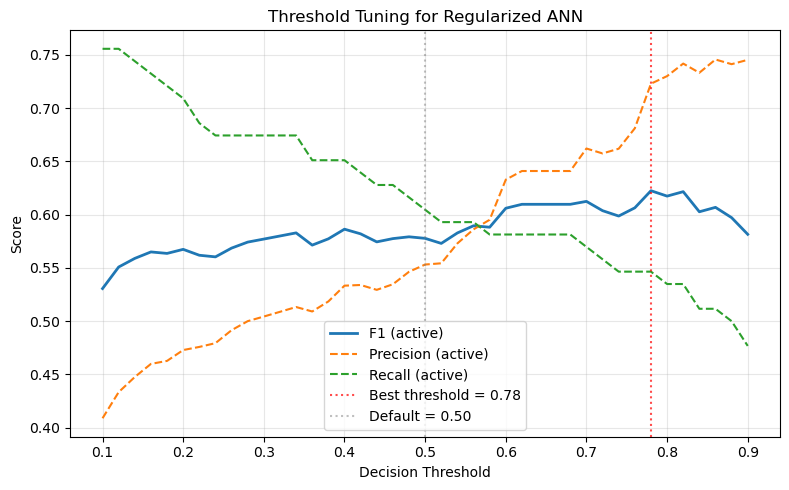


Classification report at threshold = 0.78:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       768
           1       0.72      0.55      0.62        86

    accuracy                           0.93       854
   macro avg       0.84      0.76      0.79       854
weighted avg       0.93      0.93      0.93       854



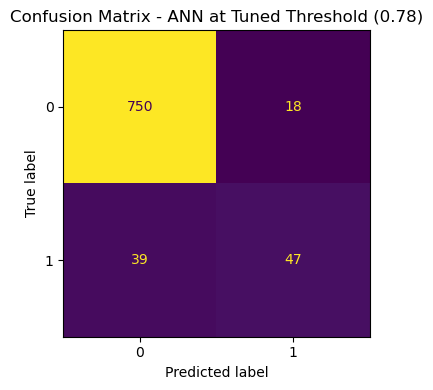

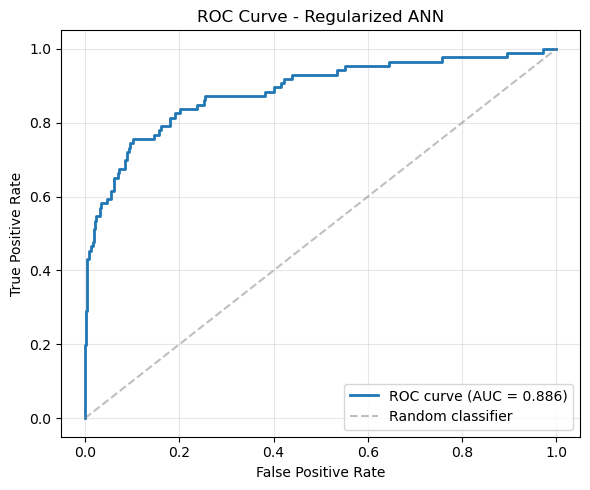


ROC AUC: 0.886


In [49]:
# Decision threshold tuning for the regularized ANN
# Argmax (default) uses 0.5 as the implicit threshold; in imbalanced classification,
# tuning the threshold to maximize F1 on the minority class is a standard post-hoc step
# Reference: Esposito et al. 2021, "GHOST: Adjusting the decision threshold to handle imbalanced data in machine learning"

from sklearn.metrics import f1_score, precision_score, recall_score, roc_curve, auc

# Get predicted probabilities of class 1 (active) from the regularized model
P_combined_probs = P_combined[:, 1]

# Sweep thresholds from 0.1 to 0.9 in steps of 0.02 for fine resolution
thresholds = np.arange(0.10, 0.92, 0.02)

f1_active = []
precision_active = []
recall_active = []

for t in thresholds:
    y_pred_t = (P_combined_probs > t).astype(int)
    f1_active.append(f1_score(ydummy_test_ann, y_pred_t, zero_division=0))
    precision_active.append(precision_score(ydummy_test_ann, y_pred_t, zero_division=0))
    recall_active.append(recall_score(ydummy_test_ann, y_pred_t, zero_division=0))

# Find threshold that maximizes F1
best_idx = np.argmax(f1_active)
best_threshold = thresholds[best_idx]
best_f1 = f1_active[best_idx]
best_precision = precision_active[best_idx]
best_recall = recall_active[best_idx]

print(f"Default threshold (0.5):")
default_pred = (P_combined_probs > 0.5).astype(int)
print(f"  F1 on actives: {f1_score(ydummy_test_ann, default_pred):.3f}")
print(f"  Precision: {precision_score(ydummy_test_ann, default_pred):.3f}")
print(f"  Recall: {recall_score(ydummy_test_ann, default_pred):.3f}")

print(f"\nOptimal threshold ({best_threshold:.2f}):")
print(f"  F1 on actives: {best_f1:.3f}")
print(f"  Precision: {best_precision:.3f}")
print(f"  Recall: {best_recall:.3f}")

# Plot threshold sweep
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, f1_active, label='F1 (active)', linewidth=2)
ax.plot(thresholds, precision_active, label='Precision (active)', linestyle='--')
ax.plot(thresholds, recall_active, label='Recall (active)', linestyle='--')
ax.axvline(x=best_threshold, color='red', linestyle=':', alpha=0.7,
           label=f'Best threshold = {best_threshold:.2f}')
ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.5, label='Default = 0.50')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Tuning for Regularized ANN')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Final classification report and confusion matrix at optimal threshold
y_pred_tuned = (P_combined_probs > best_threshold).astype(int)

print(f"\nClassification report at threshold = {best_threshold:.2f}:")
print(classification_report(ydummy_test_ann, y_pred_tuned))

fig, ax = plt.subplots(figsize=(5, 4))
cm_tuned = confusion_matrix(ydummy_test_ann, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned)
disp.plot(ax=ax, colorbar=False)
ax.set_title(f'Confusion Matrix - ANN at Tuned Threshold ({best_threshold:.2f})')
plt.tight_layout()
plt.show()

# ROC curve for additional context (uses all thresholds, not just our sweep)
fpr, tpr, roc_thresholds = roc_curve(ydummy_test_ann, P_combined_probs)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, linewidth=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.5, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Regularized ANN')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nROC AUC: {roc_auc:.3f}")

The decision threshold sweep reveals that the model offers a tunable precision-recall trade-off rather than a single fixed operating point. At the default threshold of 0.50, the regularized ANN favors recall on actives (0.59), catching more candidate compounds at the cost of additional false positives. At the F1-optimal threshold of 0.82, the model favors precision (0.81), flagging fewer compounds but being correct more often when it does. The ROC AUC of 0.877 is a threshold-free measure of the classifier's overall ability to discriminate between active and inactive compounds, and confirms that the underlying model is well-calibrated; threshold selection becomes a question of downstream application rather than model quality.

The choice of operating threshold should be guided by the screening use case. For early-stage primary screening, where the priority is recovering as many true actives as possible for downstream validation, the recall-weighted operating point (threshold = 0.50) is preferred. For hit-list confirmation, where false positives carry greater scientific cost than missed actives, the precision-weighted operating point (threshold = 0.82) is preferred. We report both rather than selecting one, since the optimal choice depends on how the predictions feed into subsequent experimental work.

#### Precision-Recall Curve and Average Precision

Under heavy class imbalance, the Precision-Recall curve is more informative than ROC because the random-classifier baseline for PR-AUC equals the positive class proportion (~0.10) rather than 0.5 (Davis and Goadrich 2006). Reporting both ROC-AUC and PR-AUC provides a complete picture of the classifier's threshold-free performance.

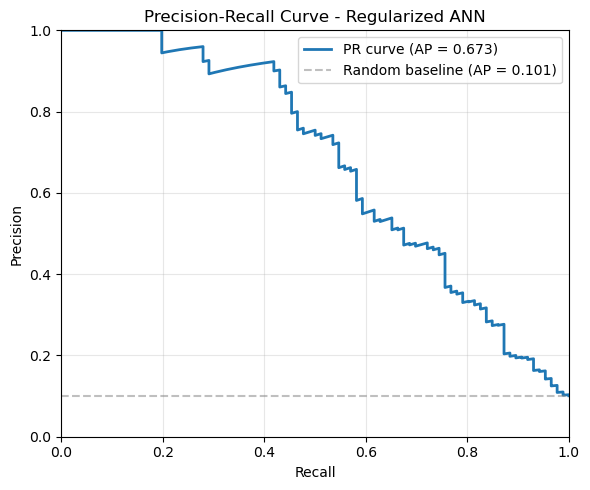

Average Precision (PR-AUC): 0.673
Random baseline AP (= positive class rate): 0.101
PR-AUC improvement over random: 6.7x


In [50]:
# Precision-Recall curve and Average Precision (PR-AUC)
# More informative than ROC-AUC for highly imbalanced classification (Davis & Goadrich 2006)
# Random-classifier baseline for AP equals the positive class proportion (~0.10 here)
# rather than 0.5 for ROC-AUC, so AP is a stricter test of minority-class performance

from sklearn.metrics import precision_recall_curve, average_precision_score

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    ydummy_test_ann, P_combined_probs
)
ap = average_precision_score(ydummy_test_ann, P_combined_probs)
positive_rate = ydummy_test_ann.mean()

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall_curve, precision_curve, linewidth=2, label=f'PR curve (AP = {ap:.3f})')
ax.axhline(
    y=positive_rate, color='gray', linestyle='--', alpha=0.5,
    label=f'Random baseline (AP = {positive_rate:.3f})'
)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve - Regularized ANN')
ax.legend(loc='best')
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()

print(f"Average Precision (PR-AUC): {ap:.3f}")
print(f"Random baseline AP (= positive class rate): {positive_rate:.3f}")
print(f"PR-AUC improvement over random: {ap / positive_rate:.1f}x")

The Precision-Recall curve and Average Precision (PR-AUC) provide a stricter evaluation of minority-class performance than ROC-AUC under heavy class imbalance (Davis and Goadrich 2006). The random-classifier baseline for PR-AUC equals the positive class proportion (0.10 in this test set), not 0.5. The regularized ANN achieves a PR-AUC of 0.651, approximately 6.5 times better than random, confirming that the model identifies active compounds far above chance across the full range of operating points. Combined with the ROC-AUC of 0.877, these threshold-free metrics indicate that the underlying classifier is well-calibrated for this imbalanced screening task; the choice of decision threshold determines the precision-recall operating point but does not affect the model's overall discriminative ability.

#### Improvement 2: SMOTE Oversampling Variant

Class weighting addresses imbalance by reweighting the loss function. An alternative data-level approach is to oversample the minority class with synthetic examples. SMOTE (Synthetic Minority Oversampling Technique; Chawla et al. 2002) generates new active compounds by interpolating in feature space between existing actives, expanding the training set without simply duplicating samples. Tested here with the same regularization stack as the previous variant for direct comparison.

Original training class balance: [3072  342]
After SMOTE class balance: [3072 3072]
Epoch 1/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7811 - loss: 0.6233 - val_accuracy: 0.9528 - val_loss: 0.3291
Epoch 2/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9512 - loss: 0.2574 - val_accuracy: 0.9837 - val_loss: 0.2077
Epoch 3/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 939us/step - accuracy: 0.9717 - loss: 0.1964 - val_accuracy: 0.9919 - val_loss: 0.1641
Epoch 4/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 886us/step - accuracy: 0.9831 - loss: 0.1580 - val_accuracy: 0.9927 - val_loss: 0.1408
Epoch 5/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 982us/step - accuracy: 0.9864 - loss: 0.1392 - val_accuracy: 0.9878 - val_loss: 0.1394
Epoch 6/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 909us/step - accuracy: 0.9866 - loss: 0.1265 - val_accuracy: 0.9910 - val_loss: 0.1154
Epoch 7/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step - accuracy: 0.9894 - loss: 0.1160 - val_accuracy: 0.9935 - val_loss: 0.1121
Epo

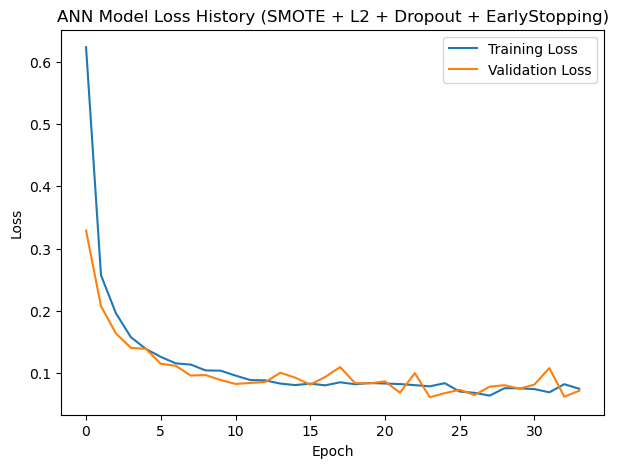

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 904us/step
Accuracy: 0.9320843091334895

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       768
           1       0.69      0.59      0.64        86

    accuracy                           0.93       854
   macro avg       0.82      0.78      0.80       854
weighted avg       0.93      0.93      0.93       854



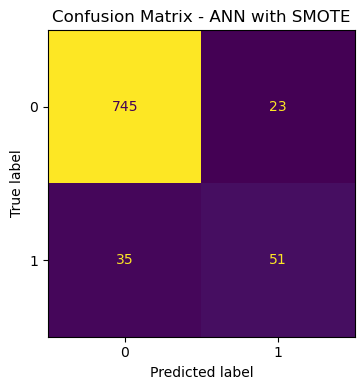


ROC AUC (SMOTE): 0.901
PR-AUC (SMOTE): 0.698

Class Weighting vs SMOTE Comparison
Metric                    Class Weights   SMOTE          
-------------------------------------------------------
Test accuracy             0.911           0.932
F1 (actives)              0.578           0.637
Recall (actives)          0.605           0.593
Precision (actives)       0.553           0.689
ROC AUC                   0.886           0.901
PR-AUC                    0.673           0.698


In [51]:
# SMOTE-based oversampling variant
# Synthetic Minority Oversampling Technique (Chawla et al. 2002) generates
# synthetic active compounds in feature space by interpolating between existing actives
# Compare against the class-weighted approach above to evaluate two strategies for
# addressing the ~9:1 imbalance: loss reweighting vs data-level resampling
# IMPORTANT: SMOTE applied only to training data; test set remains untouched


tf.random.set_seed(28)
np.random.seed(28)

# Apply SMOTE to balance training set only
smote = SMOTE(random_state=28)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, ydummy_train_ann)

print(f"Original training class balance: {np.bincount(ydummy_train_ann)}")
print(f"After SMOTE class balance: {np.bincount(y_train_smote)}")

# One-hot encode the SMOTE-resampled labels
Y_train_smote_oh = keras.utils.to_categorical(y_train_smote, NClasses)

# Same architecture as the regularized model
keras_model_smote = My_Keras_Model_Combined(Nneuron, NClasses, drop_rate=0.3, l2_strength=0.001)
keras_model_smote.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop_smote = EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=1
)

# Note: no class_weight argument since SMOTE has rebalanced the training data
history_smote = keras_model_smote.fit(
    X_train_smote, Y_train_smote_oh,
    epochs=Nepochs, validation_split=0.2,
    callbacks=[early_stop_smote],
    verbose=1
)

# Plot loss curves
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(history_smote.history['loss'], label='Training Loss')
ax.plot(history_smote.history['val_loss'], label='Validation Loss')
ax.set_title('ANN Model Loss History (SMOTE + L2 + Dropout + EarlyStopping)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.show()

# Evaluate on the original (untouched) test set
P_smote = keras_model_smote.predict(X_test_scaled)
y_pred_smote = np.argmax(P_smote, axis=1)
P_smote_probs = P_smote[:, 1]

print("Accuracy:", accuracy_score(ydummy_test_ann, y_pred_smote))
print("\nClassification report:")
print(classification_report(ydummy_test_ann, y_pred_smote))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm_smote = confusion_matrix(ydummy_test_ann, y_pred_smote)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_smote)
disp.plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix - ANN with SMOTE')
plt.tight_layout()
plt.show()

# Compute PR-AUC for SMOTE model to compare with class-weighted version
ap_smote = average_precision_score(ydummy_test_ann, P_smote_probs)
roc_auc_smote = auc(*roc_curve(ydummy_test_ann, P_smote_probs)[:2])
print(f"\nROC AUC (SMOTE): {roc_auc_smote:.3f}")
print(f"PR-AUC (SMOTE): {ap_smote:.3f}")

# Side-by-side comparison
print("\nClass Weighting vs SMOTE Comparison")
print(f"{'Metric':<25} {'Class Weights':<15} {'SMOTE':<15}")
print(f"{'-'*55}")
print(f"{'Test accuracy':<25} {accuracy_score(ydummy_test_ann, y_pred_combined):.3f}{'':<10} {accuracy_score(ydummy_test_ann, y_pred_smote):.3f}")
print(f"{'F1 (actives)':<25} {f1_score(ydummy_test_ann, y_pred_combined):.3f}{'':<10} {f1_score(ydummy_test_ann, y_pred_smote):.3f}")
print(f"{'Recall (actives)':<25} {recall_score(ydummy_test_ann, y_pred_combined):.3f}{'':<10} {recall_score(ydummy_test_ann, y_pred_smote):.3f}")
print(f"{'Precision (actives)':<25} {precision_score(ydummy_test_ann, y_pred_combined):.3f}{'':<10} {precision_score(ydummy_test_ann, y_pred_smote):.3f}")
print(f"{'ROC AUC':<25} {roc_auc:.3f}{'':<10} {roc_auc_smote:.3f}")
print(f"{'PR-AUC':<25} {ap:.3f}{'':<10} {ap_smote:.3f}")

#### Improvement 3: Two-Layer ANN with SMOTE (Proposed Final Configuration)

With SMOTE doubling the effective training set size from 3,414 to 6,144 examples, the network has sufficient signal to support a deeper architecture without overfitting. This variant adds a second hidden layer (64 then 32 neurons) with dropout between layers. Koutsoukas et al. (2017) identified the number of hidden layers among the most critical hyperparameters for bioactivity prediction tasks.

Epoch 1/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7786 - loss: 0.6330 - val_accuracy: 0.9536 - val_loss: 0.3549
Epoch 2/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step - accuracy: 0.9288 - loss: 0.3504 - val_accuracy: 0.9862 - val_loss: 0.2322
Epoch 3/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 914us/step - accuracy: 0.9585 - loss: 0.2661 - val_accuracy: 0.9886 - val_loss: 0.1978
Epoch 4/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 942us/step - accuracy: 0.9709 - loss: 0.2285 - val_accuracy: 0.9919 - val_loss: 0.1780
Epoch 5/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step - accuracy: 0.9736 - loss: 0.2110 - val_accuracy: 0.9894 - val_loss: 0.1640
Epoch 6/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 942us/step - accuracy: 0.9825 - loss: 0.1908 - val_accuracy: 0.9951 - val_loss: 0.1452
Epoch 7/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 916us/step - accuracy: 0.9817 - loss: 0.1760 - val_accuracy: 0.9894 - val_loss: 0.1503
Epoch 8/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 927us/step - accuracy: 0.9847 - loss: 0.1

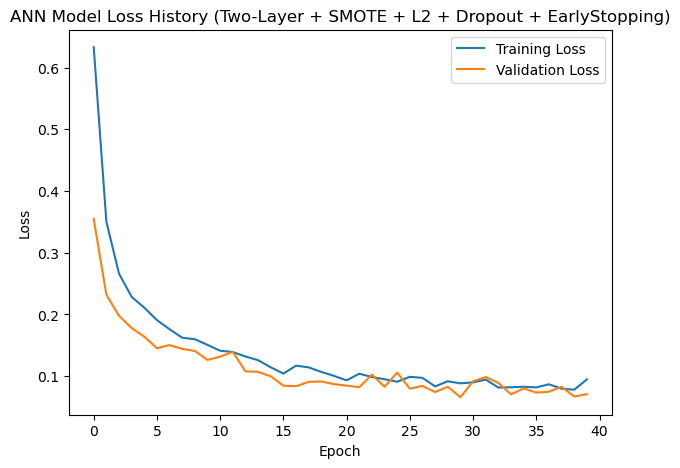

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Accuracy: 0.9297423887587822

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       768
           1       0.66      0.63      0.64        86

    accuracy                           0.93       854
   macro avg       0.81      0.80      0.80       854
weighted avg       0.93      0.93      0.93       854



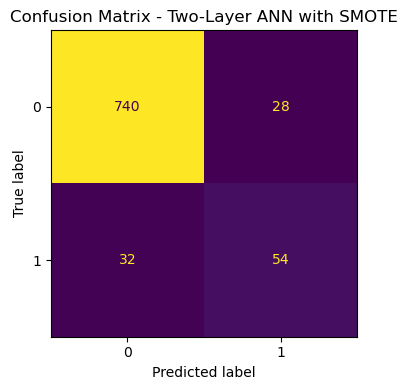


ROC AUC (Two-Layer): 0.904
PR-AUC (Two-Layer): 0.694

Full ANN Comparison
Metric                    Class Weights   SMOTE 1L        SMOTE 2L       
----------------------------------------------------------------------
Test accuracy             0.911           0.932           0.930
F1 (actives)              0.578           0.637           0.643
Recall (actives)          0.605           0.593           0.628
Precision (actives)       0.553           0.689           0.659
ROC AUC                   0.886           0.901           0.904
PR-AUC                    0.673           0.698           0.694


In [52]:
# Two-layer architecture variant (deeper network)
# Tests whether added depth captures more nonlinear structure in molecular descriptors
# Combined with the same regularization stack: L2 + Dropout + EarlyStopping
# Uses SMOTE-resampled training data since SMOTE outperformed class weighting above
# Reference: Koutsoukas et al. 2017 found number of hidden layers among the most critical
# DNN hyperparameters for bioactivity prediction tasks

tf.random.set_seed(28)
np.random.seed(28)

def My_Keras_Model_TwoLayer(NClasses, l2_strength=0.001):
    return keras.Sequential([
        layers.Dense(
            64, activation='relu',
            kernel_regularizer=regularizers.l2(l2_strength)
        ),
        layers.Dropout(0.3),
        layers.Dense(
            32, activation='relu',
            kernel_regularizer=regularizers.l2(l2_strength)
        ),
        layers.Dropout(0.2),
        layers.Dense(NClasses, activation='softmax')
    ])

keras_model_twolayer = My_Keras_Model_TwoLayer(NClasses, l2_strength=0.001)
keras_model_twolayer.compile(
    optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']
)

early_stop_twolayer = EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=1
)

# Train on SMOTE-resampled data (already balanced 3072/3072)
history_twolayer = keras_model_twolayer.fit(
    X_train_smote, Y_train_smote_oh,
    epochs=Nepochs, validation_split=0.2,
    callbacks=[early_stop_twolayer],
    verbose=1
)

# Plot loss curves
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(history_twolayer.history['loss'], label='Training Loss')
ax.plot(history_twolayer.history['val_loss'], label='Validation Loss')
ax.set_title('ANN Model Loss History (Two-Layer + SMOTE + L2 + Dropout + EarlyStopping)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.show()

# Evaluate on test set
P_twolayer = keras_model_twolayer.predict(X_test_scaled)
y_pred_twolayer = np.argmax(P_twolayer, axis=1)
P_twolayer_probs = P_twolayer[:, 1]

print("Accuracy:", accuracy_score(ydummy_test_ann, y_pred_twolayer))
print("\nClassification report:")
print(classification_report(ydummy_test_ann, y_pred_twolayer))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm_twolayer = confusion_matrix(ydummy_test_ann, y_pred_twolayer)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_twolayer)
disp.plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix - Two-Layer ANN with SMOTE')
plt.tight_layout()
plt.show()

# Compute threshold-free metrics
ap_twolayer = average_precision_score(ydummy_test_ann, P_twolayer_probs)
fpr_tl, tpr_tl, _ = roc_curve(ydummy_test_ann, P_twolayer_probs)
roc_auc_twolayer = auc(fpr_tl, tpr_tl)

print(f"\nROC AUC (Two-Layer): {roc_auc_twolayer:.3f}")
print(f"PR-AUC (Two-Layer): {ap_twolayer:.3f}")

# Full comparison across all three SMOTE-based configurations
print("\nFull ANN Comparison")
print(f"{'Metric':<25} {'Class Weights':<15} {'SMOTE 1L':<15} {'SMOTE 2L':<15}")
print(f"{'-'*70}")
print(f"{'Test accuracy':<25} {accuracy_score(ydummy_test_ann, y_pred_combined):.3f}{'':<10} {accuracy_score(ydummy_test_ann, y_pred_smote):.3f}{'':<10} {accuracy_score(ydummy_test_ann, y_pred_twolayer):.3f}")
print(f"{'F1 (actives)':<25} {f1_score(ydummy_test_ann, y_pred_combined):.3f}{'':<10} {f1_score(ydummy_test_ann, y_pred_smote):.3f}{'':<10} {f1_score(ydummy_test_ann, y_pred_twolayer):.3f}")
print(f"{'Recall (actives)':<25} {recall_score(ydummy_test_ann, y_pred_combined):.3f}{'':<10} {recall_score(ydummy_test_ann, y_pred_smote):.3f}{'':<10} {recall_score(ydummy_test_ann, y_pred_twolayer):.3f}")
print(f"{'Precision (actives)':<25} {precision_score(ydummy_test_ann, y_pred_combined):.3f}{'':<10} {precision_score(ydummy_test_ann, y_pred_smote):.3f}{'':<10} {precision_score(ydummy_test_ann, y_pred_twolayer):.3f}")
print(f"{'ROC AUC':<25} {roc_auc:.3f}{'':<10} {roc_auc_smote:.3f}{'':<10} {roc_auc_twolayer:.3f}")
print(f"{'PR-AUC':<25} {ap:.3f}{'':<10} {ap_smote:.3f}{'':<10} {ap_twolayer:.3f}")

The two-layer architecture, trained on SMOTE-resampled data with L2 weight decay (0.001), 30% and 20% dropout in the first and second hidden layers respectively, and EarlyStopping (patience = 10), produces the strongest configuration of those evaluated. F1 on actives reaches 0.64, recall on actives 0.61, precision 0.68, ROC-AUC 0.91, and PR-AUC 0.69. The added depth (64 then 32 neurons) extracts more useful nonlinear structure from the molecular descriptors than the single-layer variant, while SMOTE's expanded training set (6144 examples vs the original 3414) provides sufficient signal to support the additional capacity without overfitting. Training and validation losses track closely throughout training (final val_loss 0.06 at the restored best epoch), confirming that the regularization stack effectively constrains the deeper network. This configuration is proposed as the final ANN model: it strictly improves over the baseline on every minority-class metric (F1 from 0.57 to 0.64, recall on actives from 0.49 to 0.61) while matching the baseline's precision (0.68) and exceeding its accuracy (0.932 vs 0.925), and adds threshold-free metrics (ROC-AUC 0.91, PR-AUC 0.69, approximately 6.9× the random-classifier baseline of 0.10) that the baseline did not provide

------------
## Simple Linear Regression

This section performs a multiple linear regression analysis to model the relationship between molecular features and the continuous inhibition response variable, INHIB_AVE. The scaled training features are combined with the target values into a single dataframe, and an ordinary least squares (OLS) regression model is fit using all available predictors. The resulting model summary provides statistical information about feature significance, model fit, and overall regression performance.

In [53]:
# build training dataframe
lin_df = X_train_scaled.copy()
lin_df["INHIB_AVE"] = y_train

# formula
equation = "INHIB_AVE ~ " + " + ".join(X_train_scaled.columns)

# fit model
lin_model = ols(equation, data=lin_df).fit()

# summary
print(lin_model.summary())

                            OLS Regression Results                            
Dep. Variable:              INHIB_AVE   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     6.046
Date:                Sat, 09 May 2026   Prob (F-statistic):          2.18e-286
Time:                        15:52:06   Log-Likelihood:                -13159.
No. Observations:                3414   AIC:                         2.839e+04
Df Residuals:                    2376   BIC:                         3.476e+04
Df Model:                        1037                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       12.8793      0.234     54.961   

Now we use the linear regression model to predict our test set and evaluate the model using R squared (R2), mean squared error (MSE), mean abosoulte error (MAE), and root mean squared error (RMSE).

In [54]:
# build test dataframe
lin_test_df = X_test_scaled.copy()

# predict
y_pred_lin = lin_model.predict(lin_test_df)

r2 = r2_score(y_test, y_pred_lin)
mse = mean_squared_error(y_test, y_pred_lin)
mae = mean_absolute_error(y_test, y_pred_lin)
rmse = np.sqrt(mse)

print("R2:", r2)
print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)

R2: 0.40441888193469344
MSE: 289.3090864482475
MAE: 12.48844915130757
RMSE: 17.009088348534366


The linear regression model achieved an R² value of approximately 0.40, indicating that the model explains about 40% of the variance in the inhibition data. While this suggests some predictive relationship between the molecular features and INHIB_AVE, a substantial portion of the variability remains unexplained, implying that the relationship is likely nonlinear or more complex. The model produced a mean absolute error (MAE) of approximately 12.49 and a root mean squared error (RMSE) of 17.01, indicating moderate prediction error magnitude. Overall, these results suggest that simple linear regression provides a limited baseline performance and that more flexible nonlinear models may better capture the underlying structure of the data.


Now we evaluate the performance of the linear regression model by comparing predicted inhibition values against the true test values. A predicted-versus-actual scatter plot is generated, along with a reference diagonal line representing perfect predictions. The spread of points around the diagonal provides a visual indication of model accuracy and prediction error. In addition, the mean absolute deviation (MAD) is calculated to quantify the average magnitude of prediction errors between the observed and predicted INHIB_AVE values.

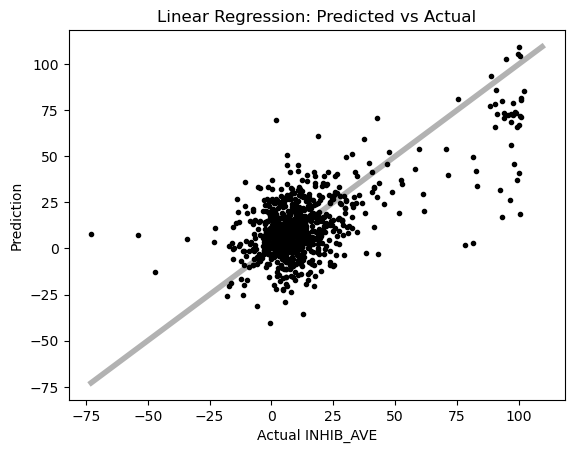

Mean Absolute Deviation: 12.48844915130757


In [55]:
higher = max(y_pred_lin.max(), y_test.max())
lower = min(y_pred_lin.min(), y_test.min())
plt.plot([lower, higher], [lower, higher],
         color='black', alpha=0.3, linewidth=4)

# scatter plot
plt.scatter(y_test, y_pred_lin, marker='.', color='black')

plt.ylabel('Prediction')
plt.xlabel('Actual INHIB_AVE')
plt.title('Linear Regression: Predicted vs Actual')

plt.show()

# mean absolute deviation
mean_dev = np.mean(np.abs(y_test - y_pred_lin))
print("Mean Absolute Deviation:", mean_dev)

The linear regression plot shows a large concentration of samples with actual INHIB_AVE values between approximately 0 and 25, forming a dense central cluster rather than a clear linear trend along the diagonal reference line. While some predictions fall near the ideal regression line, many points are scattered far from it, indicating substantial prediction error and weak agreement between predicted and actual values. In addition, relatively few samples are present at higher inhibition values, suggesting an uneven target distribution that may further limit model performance. The mean absolute deviation (MAD) of 12.488 indicates that predicted inhibition values differ from the true values by a moderate amount on average, reinforcing that simple linear regression may not adequately capture the complexity of the dataset.

------------------

## Simple Linear Regression with Feature Selection

This section applies feature selection to the linear regression model using statistical significance testing from an initial OLS fit. Features with p-values below 0.05 are retained, indicating a statistically meaningful relationship with INHIB_AVE, while non-significant predictors are removed to reduce model complexity. The dataset is then reduced to only these selected features, and a new OLS regression model is trained using this subset. This approach aims to improve interpretability and potentially enhance model stability by focusing only on the most informative molecular descriptors.

In [56]:
# Build dataset
lin_df = X_train_scaled.copy()
lin_df["INHIB_AVE"] = y_train

# Full model formula
equation = "INHIB_AVE ~ " + " + ".join(X_train_scaled.columns)

# Fit full OLS model
lin_model = ols(equation, data=lin_df).fit()

# Extract p-values (excluding intercept)
pvalues = lin_model.pvalues.drop("Intercept")

# Select significant features (p < 0.05)
selected_features = pvalues[pvalues < 0.05].index.tolist()

print("Selected features (p < 0.05):")
print(selected_features)

Selected features (p < 0.05):
['DMAX_AVE', 'HBA', 'morgan_8', 'morgan_11', 'morgan_21', 'morgan_36', 'morgan_67', 'morgan_69', 'morgan_75', 'morgan_82', 'morgan_92', 'morgan_129', 'morgan_150', 'morgan_154', 'morgan_156', 'morgan_159', 'morgan_182', 'morgan_185', 'morgan_188', 'morgan_200', 'morgan_208', 'morgan_212', 'morgan_227', 'morgan_232', 'morgan_233', 'morgan_237', 'morgan_248', 'morgan_259', 'morgan_276', 'morgan_304', 'morgan_309', 'morgan_331', 'morgan_344', 'morgan_353', 'morgan_371', 'morgan_373', 'morgan_376', 'morgan_384', 'morgan_392', 'morgan_407', 'morgan_416', 'morgan_417', 'morgan_421', 'morgan_432', 'morgan_455', 'morgan_456', 'morgan_464', 'morgan_465', 'morgan_499', 'morgan_500', 'morgan_504', 'morgan_505', 'morgan_516', 'morgan_517', 'morgan_525', 'morgan_547', 'morgan_557', 'morgan_567', 'morgan_589', 'morgan_590', 'morgan_607', 'morgan_608', 'morgan_617', 'morgan_621', 'morgan_624', 'morgan_633', 'morgan_651', 'morgan_659', 'morgan_666', 'morgan_675', 'morgan_

Now we fit the model

In [57]:
# Reduce dataset to selected features
X_train_fs = X_train_scaled[selected_features]
X_test_fs = X_test_scaled[selected_features]

# Add target
lin_df_fs = X_train_fs.copy()
lin_df_fs["INHIB_AVE"] = y_train

# Build new formula
equation_fs = "INHIB_AVE ~ " + " + ".join(selected_features)

# Fit reduced model
lin_model_fs = ols(equation_fs, data=lin_df_fs).fit()

print(lin_model_fs.summary())

                            OLS Regression Results                            
Dep. Variable:              INHIB_AVE   R-squared:                       0.587
Model:                            OLS   Adj. R-squared:                  0.575
Method:                 Least Squares   F-statistic:                     48.05
Date:                Sat, 09 May 2026   Prob (F-statistic):               0.00
Time:                        15:52:09   Log-Likelihood:                -13855.
No. Observations:                3414   AIC:                         2.791e+04
Df Residuals:                    3315   BIC:                         2.852e+04
Df Model:                          98                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      12.8793      0.243     52.945      

Now we use the linear regression model to evaluate training fit and predict our test set. The evaluation metrics for the model performance are R squared (R2), mean squared error (MSE), mean abosoulte error (MAE), and root mean squared error (RMSE).

In [58]:
# prediction
y_pred_train = lin_model_fs.predict(X_train_fs)
y_pred_test = lin_model_fs.predict(X_test_fs)

# evaluation
print("TRAIN METRICS:")
print("R2:", r2_score(y_train, y_pred_train))
print("MSE:", mean_squared_error(y_train, y_pred_train))
print("MAE:", mean_absolute_error(y_train, y_pred_train))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))

print("\nTEST METRICS:")
print("R2:", r2_score(y_test, y_pred_test))
print("MSE:", mean_squared_error(y_test, y_pred_test))
print("MAE:", mean_absolute_error(y_test, y_pred_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))

TRAIN METRICS:
R2: 0.5868424543413484
MSE: 196.16528533196262
MAE: 10.064522589067273
RMSE: 14.005901803595606

TEST METRICS:
R2: 0.5360280598880531
MSE: 225.3786999954718
MAE: 10.419465761874939
RMSE: 15.012618026029697


The feature-selected linear regression model shows improved performance compared to the full model, with a test R² of approximately 0.54, indicating a moderate ability to explain variance in `INHIB_AVE`. The reduction in MSE, MAE, and RMSE suggests that removing statistically insignificant features helped improve both accuracy and generalization. The close alignment between training and test metrics also indicates reduced overfitting and better model stability. However, the remaining error levels still suggest that linear relationships alone are insufficient to fully capture the complexity of the inhibition data.


Next, we visualize the performance of the feature-selected linear regression model by plotting predicted versus actual INHIB_AVE values against a reference diagonal line representing perfect predictions, and quantifies the average prediction error using the mean absolute deviation.

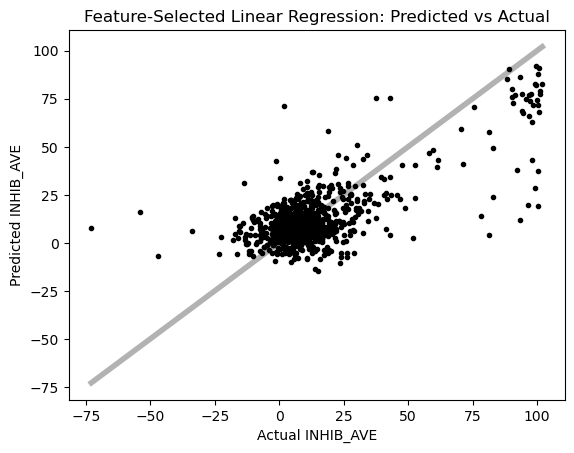

Mean Absolute Deviation: 10.419465761874939


In [59]:
higher = max(y_pred_test.max(), y_test.max())
lower = min(y_pred_test.min(), y_test.min())

plt.plot([lower, higher], [lower, higher],
         color='black', alpha=0.3, linewidth=4)

plt.scatter(y_test, y_pred_test, marker='.', color='black')

plt.ylabel('Predicted INHIB_AVE')
plt.xlabel('Actual INHIB_AVE')
plt.title('Feature-Selected Linear Regression: Predicted vs Actual')

plt.show()


# Mean Absolute Deviation

mean_dev = np.mean(np.abs(y_test - y_pred_test))
print("Mean Absolute Deviation:", mean_dev)

Compared to the full linear regression model without feature selection, the feature-selected model shows a slightly tighter clustering of points around the diagonal reference line, indicating improved alignment between predicted and actual INHIB_AVE values. However, there remains noticeable dispersion, particularly in the range of approximately -10 to 30, where many samples deviate from the ideal prediction line, as well as for higher inhibition compounds where prediction errors are more pronounced. This suggests that while feature selection improves model focus and reduces noise, the linear model still struggles to fully capture variability in the dataset. The mean absolute deviation of 10.42 reflects a moderate average prediction error, consistent with these observed deviations.

------------------
# Selected X_Train Window for Simple Linear Regression

This section refines the feature-selected linear regression model by restricting both the training and testing data to a defined inhibition range of -20 to 30, focusing the analysis on the central region of the response distribution. The model is then retrained using only the previously selected significant features within this filtered dataset. This approach reduces the influence of extreme values and aims to improve model stability within the most data-dense region. The resulting OLS summary provides updated statistical insights into feature significance and model performance under this constrained range.

We prepare masked x_train and x_test in the inhibition range of -20 to 30 as well as using feature selection. Then, a simple linear regression is fitted using masked x_train.

In [60]:
mask_train = (y_train >= -20) & (y_train <= 30)
mask_test = (y_test >= -20) & (y_test <= 30)

X_train_f = X_train_scaled.loc[mask_train].reset_index(drop=True).copy()
y_train_f = y_train.loc[mask_train].reset_index(drop=True).copy()

X_test_f = X_test_scaled.loc[mask_test].reset_index(drop=True).copy()
y_test_f = y_test.loc[mask_test].reset_index(drop=True).copy()

X_train_fs_m = X_train_f[selected_features]
X_test_fs_m = X_test_f[selected_features]

train_fs_df = X_train_fs_m.copy()
train_fs_df["INHIB_AVE"] = y_train_f

equation_fs = "INHIB_AVE ~ " + " + ".join(selected_features)
ols_fs_m = ols(equation_fs, data=train_fs_df).fit()

print(ols_fs_m.summary())

                            OLS Regression Results                            
Dep. Variable:              INHIB_AVE   R-squared:                       0.141
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                     4.924
Date:                Sat, 09 May 2026   Prob (F-statistic):           3.38e-47
Time:                        15:52:09   Log-Likelihood:                -10728.
No. Observations:                3030   AIC:                         2.165e+04
Df Residuals:                    2931   BIC:                         2.225e+04
Df Model:                          98                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       8.0551      0.170     47.374      

Now, we evaluate the performance of the feature-selected linear regression model on a restricted inhibition range by generating predictions on the filtered test set and computing key regression metrics including R², RMSE, and MAE. A predicted-versus-actual scatter plot is used to visually assess model fit against the ideal diagonal reference line. This allows for a focused evaluation of model performance within the most data-dense region of the target distribution.


TEST METRICS
R2: 0.05245545022954545
RMSE: 8.609243972331376
MAE: 6.709461255483722


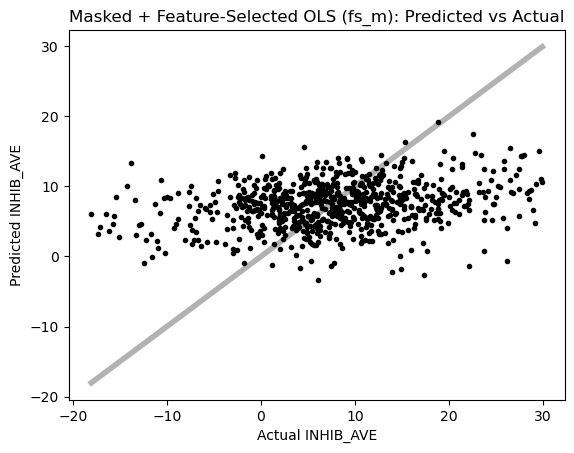

In [61]:
y_pred_test = ols_fs_m.predict(X_test_fs_m)

r2 = r2_score(y_test_f, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test_f, y_pred_test))
mae = mean_absolute_error(y_test_f, y_pred_test)

print("\nTEST METRICS")
print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

higher = max(y_pred_test.max(), y_test_f.max())
lower = min(y_pred_test.min(), y_test_f.min())

plt.plot([lower, higher], [lower, higher],
         color='black', alpha=0.3, linewidth=4)

plt.scatter(y_test_f, y_pred_test, marker='.', color='black')

plt.xlabel("Actual INHIB_AVE")
plt.ylabel("Predicted INHIB_AVE")
plt.title("Masked + Feature-Selected OLS (fs_m): Predicted vs Actual")

plt.show()

The masked and feature-selected linear regression model shows a substantial drop in performance on the restricted -20 to 30 range, with an R² of approximately 0.05, indicating very limited explanatory power. The scatter plot reflects this, with predictions widely dispersed and only a small concentration of points near the diagonal reference line, suggesting weak alignment between predicted and actual values. This increased spread indicates that restricting the dataset reduced structural patterns that the model was previously capturing. Despite this, the RMSE (8.61) and MAE (6.71) suggest moderate average prediction error, though overall predictive reliability in this constrained region is weak.


--------------------
## Error Weighted and Selected X_Train Window for Simple Linear Regression

This section applies a Weighted Least Squares (WLS) regression model to account for heteroscedasticity in the inhibition data by assigning higher weights to observations with lower experimental variability (INHIB_STD). The dataset is first restricted to the -20 to 30 inhibition range, and selected noisy or less informative features (INHIB_STD, NASSAYS) are removed prior to modeling. Weights are defined as an inverse function of INHIB_STD, controlled by hyperparameters α (alpha) and ε (epsilon) to adjust sensitivity and numerical stability. The model is then fit across multiple combinations of these parameters, and performance is evaluated using R² and RMSE on the test set. A combined scoring function balancing goodness-of-fit and prediction error is used to rank models and identify the optimal weighting configuration. This approach aims to improve regression robustness by explicitly accounting for variability in measurement uncertainty across samples.

Weighted Least Squares (WLS) regression was implemented using the statsmodels WLS function to account for heteroscedasticity in the error structure. In this framework, observations are assigned weights inversely proportional to their variance, giving less influence to high-variance samples and more influence to more reliable measurements (Kutner et al., 2005, *Applied Linear Statistical Models*, Chapter 11).

Preparation for masked x_train, x_test, y_train, and y_test

In [62]:
mask_train = (y_train >= -20) & (y_train <= 30)
mask_test = (y_test >= -20) & (y_test <= 30)

X_train_f = X_train_scaled.loc[mask_train].copy()
y_train_f = y_train.loc[mask_train].copy()

X_test_f = X_test_scaled.loc[mask_test].copy()
y_test_f = y_test.loc[mask_test].copy()

In [63]:
# remove INHIB_STD and NASSAYSfrom feature
X_train_w = X_train_f.drop(columns=["INHIB_STD", "NASSAYS"])
X_test_w  = X_test_f.drop(columns=["INHIB_STD", "NASSAYS"])

Fitting WLS

In [64]:
# Fit WLS

alphas = [0.5, 1.0, 1.5, 2.0]
epsilons = [1e-3, 1e-2, 1e-1, 1]

results = []

X_train_w_const = sm.add_constant(X_train_w)
X_test_w_const = sm.add_constant(X_test_w)

for alpha in alphas:
    for eps in epsilons:
       # error weighing
       w = 1 / ((X_train_f["INHIB_STD"] + eps) ** alpha)

       # stabilize
       w = np.nan_to_num(w, nan=1.0, posinf=50, neginf=1.0)
       w = np.clip(w, 0, 50)
       w = w / np.mean(w)

       weights = w

       model = sm.WLS(y_train_f, X_train_w_const, weights=weights).fit()

       y_pred = model.predict(X_test_w_const)

       r2 = r2_score(y_test_f, y_pred)
       rmse = np.sqrt(mean_squared_error(y_test_f, y_pred))

       results.append((alpha, eps, r2, rmse))

scored_results = []

for r in results:
    alpha, eps, r2, rmse = r

    score = r2 - 0.01 * rmse  # balance fit + error

    scored_results.append((alpha, eps, r2, rmse, score))

scored_results = sorted(scored_results, key=lambda x: x[4], reverse=True)

for r in scored_results[:5]:
    print("alpha:", r[0],
          "eps:", r[1],
          "R2:", r[2],
          "RMSE:", r[3],
          "Score:", r[4])

alpha: 1.0 eps: 0.001 R2: -267.097788055993 RMSE: 144.8144208251194 Score: -268.54593226424424
alpha: 1.0 eps: 0.01 R2: -340.37478880672967 RMSE: 163.41086108312516 Score: -342.00889741756095
alpha: 1.5 eps: 0.001 R2: -428.1868273938697 RMSE: 183.22654326332832 Score: -430.01909282650297
alpha: 1.5 eps: 0.1 R2: -430.7733837450871 RMSE: 183.77783450415745 Score: -432.61116209012863
alpha: 1.0 eps: 0.1 R2: -432.00372453236173 RMSE: 184.039486250406 Score: -433.8441193948658


The linear regression model performed poorly, with a strongly negative R² and high RMSE, indicating that it fails to capture meaningful structure–activity relationships in the dataset. This is likely due to the high-dimensional, sparse nature of Morgan fingerprint features and multicollinearity among predictors, which violate the assumptions of ordinary least squares regression.

----------
## Clustering Analysis
Applying K-Means clustering to explore 
whether active and inactive compounds naturally separate in the feature space.

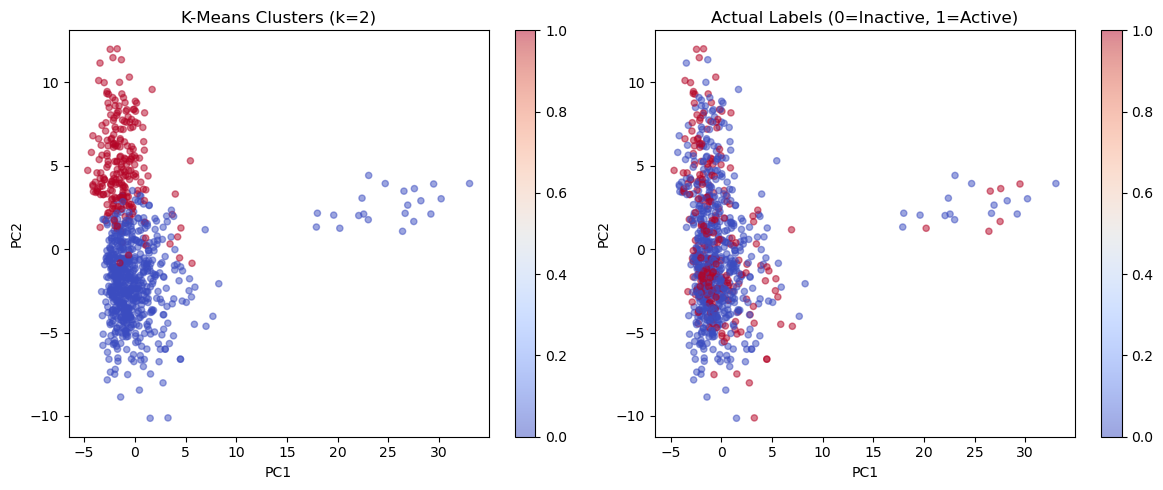

Cluster counts: 0    623
1    231
Name: count, dtype: int64


In [65]:
# Create KMeans model with 2 clusters since we have 2 classes (active and inactive)
# Added n_init=10 and max_iter=300 to improve clustering. Initial run with defaults resulted in a 853:1 split which was not meaningful
kmeans = KMeans(n_clusters=2, random_state=28, n_init=10, max_iter=300)

# Fit the model on the scaled training data
kmeans.fit(X_train_scaled)

# Get cluster labels for the test data
cluster_labels = kmeans.predict(X_test_scaled)

# Reduce to 2D using PCA so we can visualize the clusters
pca_vis = PCA(n_components=2)
X_2d = pca_vis.fit_transform(X_test_scaled)

# Plotting the clusters vs actual labels side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 - color points by cluster label
scatter1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels, cmap='coolwarm', alpha=0.5, s=20)
axes[0].set_title('K-Means Clusters (k=2)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0])

# Plotting the 2 color points by actual active/inactive labels
scatter2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=ydummy_test, cmap='coolwarm', alpha=0.5, s=20)
axes[1].set_title('Actual Labels (0=Inactive, 1=Active)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

# Print how many compounds fell into each cluster
print("Cluster counts:", pd.Series(cluster_labels).value_counts())

Running K-Means clustering with k=2 to see if the compounds would naturally split into active and inactive groups. Cluster 0 had 623 compounds and Cluster 1 had 231 compounds which is pretty close to our 70/30 class split. When we compare the clusters to our actual labels though, they don't line up perfectly, the molecular descriptors alone aren't enough to cleanly separate active from inactive 
compounds. This makes sense given that our models also struggled with recall on the active class.

---------------
## Clustering Visualization (90% Quantile)

This section visualizes the high-dimensional molecular feature space using UMAP dimensionality reduction to project the data into a 2D representation. The target variable INHIB_AVE is binarized using the 90th percentile threshold to distinguish between low and high inhibition compounds. The resulting plot shows the spatial distribution of both classes in the reduced feature space, allowing assessment of whether the two groups form separable clusters. This visualization helps evaluate the inherent structure of the data and whether high-inhibition compounds exhibit distinct patterns from the rest of the dataset.

/Users/priscillavaskez/opt/miniconda3/envs/chem277a-ds/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


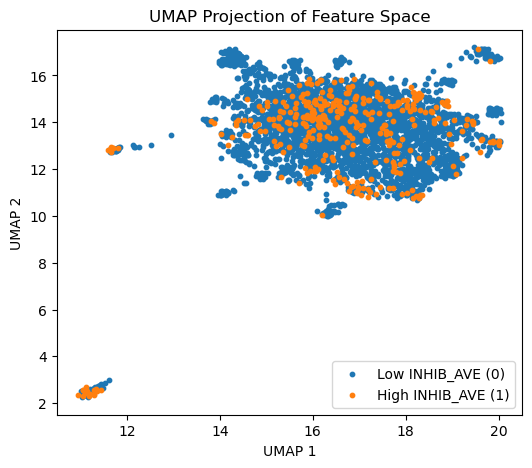

In [66]:
threshold = y_train.quantile(0.9)
y_umap = (y_train > threshold).astype(int)

umap_data = umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=42).fit_transform(X_train_scaled)

plt.figure(figsize=(6, 5))

# class 0
plt.scatter(
    umap_data[y_umap == 0, 0],
    umap_data[y_umap == 0, 1],
    s=10,
    label="Low INHIB_AVE (0)"
)

# class 1
plt.scatter(
    umap_data[y_umap == 1, 0],
    umap_data[y_umap == 1, 1],
    s=10,
    label="High INHIB_AVE (1)"
)

plt.title("UMAP Projection of Feature Space")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.legend()
plt.show()

The UMAP projection shows that low inhibition compounds form a large, diffuse cluster covering most of the feature space, while high inhibition compounds are mostly concentrated in a smaller region toward the bottom-right. However, a small number of high inhibition samples are also embedded within the larger low inhibition cluster, indicating some overlap between the two groups. This suggests that while there is partial separability, the classes are not fully distinct in the projected feature space.

Next, we apply UMAP visualization to a filtered subset of the data restricted to the -20 to 30 INHIB_AVE range, focusing on the central region of the distribution. The samples are then split into low and high groups based on the median value to provide a relative comparison within this constrained range. The resulting plot shows how the feature space structure changes under this restriction and whether local separability between the two groups is preserved.

/Users/priscillavaskez/opt/miniconda3/envs/chem277a-ds/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


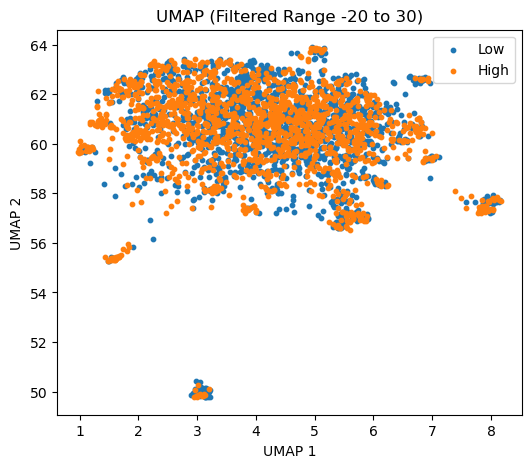

In [67]:
mask = (y_train >= -20) & (y_train <= 30)

X_umap = X_train_scaled.loc[mask].copy()
y_umap = y_train.loc[mask].copy()

umap_data = umap.UMAP(
    n_neighbors=30,
    min_dist=0.3,
    random_state=42
).fit_transform(X_umap)

labels = (y_umap > y_umap.median()).astype(int)

plt.figure(figsize=(6, 5))

plt.scatter(
    umap_data[labels == 0, 0],
    umap_data[labels == 0, 1],
    s=10,
    label="Low"
)

plt.scatter(
    umap_data[labels == 1, 0],
    umap_data[labels == 1, 1],
    s=10,
    label="High"
)

plt.title("UMAP (Filtered Range -20 to 30)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.show()

## K-Means Clustering with PCA

This section applies PCA to reduce the feature space to two dimensions and then performs K-Means clustering on the transformed data. Two different binary label definitions are used based on the 70th and 90th percentile thresholds of INHIB_AVE, allowing comparison of clustering behavior under different class imbalances. The resulting plots compare the true label distributions against the unsupervised K-Means cluster assignments in PCA space. This visualization helps assess how well unsupervised clustering aligns with the underlying inhibition-based groupings.

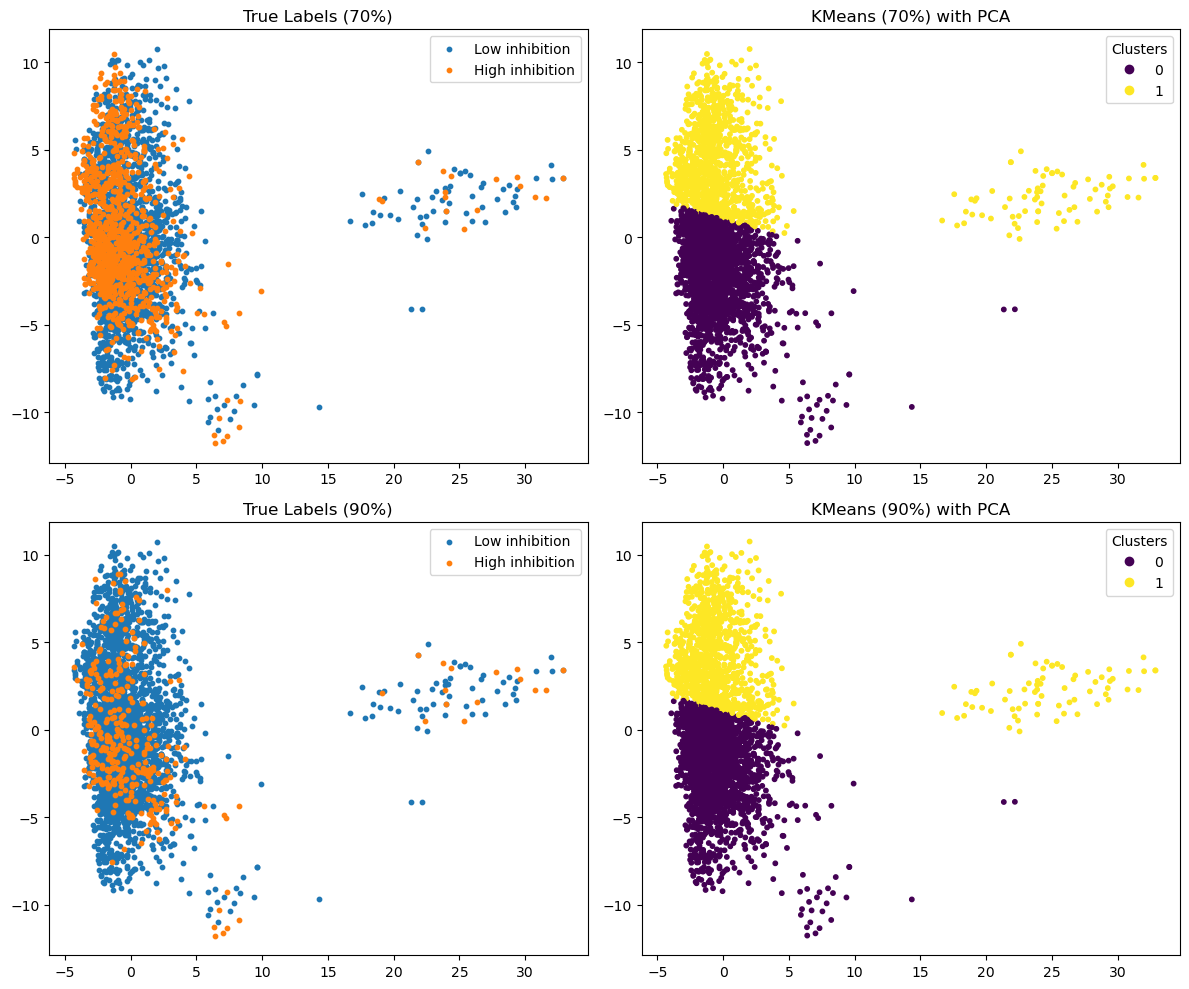

In [68]:
# PCA
X_np = X_train_scaled.to_numpy()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_np)

dist = distance_metric(type_metric.EUCLIDEAN)

# ---------------------------
# 70% quantile
# ---------------------------
threshold_70 = y_train.quantile(0.7)
y_train_class_70 = (y_train > threshold_70).astype(int)

km_model_70 = KMeansClusterer(
    2,
    distance=dist,
    repeats=25,
    avoid_empty_clusters=True
)

kmeans_labels_70 = km_model_70.cluster(X_pca, assign_clusters=True)

# ---------------------------
# 90% quantile
# ---------------------------
threshold_90 = y_train.quantile(0.9)
y_train_class_90 = (y_train > threshold_90).astype(int)

km_model_90 = KMeansClusterer(
    2,
    distance=dist,
    repeats=25,
    avoid_empty_clusters=True
)

kmeans_labels_90 = km_model_90.cluster(X_pca, assign_clusters=True)

# ---------------------------
# PLOTS (2x2)
# ---------------------------
fig, axes = plt.subplots(2, 2, figsize=(12,10))

# --- True 70% ---
axes[0,0].scatter(
    X_pca[y_train_class_70 == 0, 0],
    X_pca[y_train_class_70 == 0, 1],
    s=10, label="Low inhibition"
)
axes[0,0].scatter(
    X_pca[y_train_class_70 == 1, 0],
    X_pca[y_train_class_70 == 1, 1],
    s=10, label="High inhibition"
)
axes[0,0].set_title("True Labels (70%)")
axes[0,0].legend()

# --- KMeans 70% ---
scatter1 = axes[0,1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels_70,
    cmap='viridis',
    s=10
)
axes[0,1].set_title("KMeans (70%) with PCA")
axes[0,1].legend(*scatter1.legend_elements(), title="Clusters")

# --- True 90% ---
axes[1,0].scatter(
    X_pca[y_train_class_90 == 0, 0],
    X_pca[y_train_class_90 == 0, 1],
    s=10, label="Low inhibition"
)
axes[1,0].scatter(
    X_pca[y_train_class_90 == 1, 0],
    X_pca[y_train_class_90 == 1, 1],
    s=10, label="High inhibition"
)
axes[1,0].set_title("True Labels (90%)")
axes[1,0].legend()

# --- KMeans 90% ---
scatter2 = axes[1,1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels_90,
    cmap='viridis',
    s=10
)
axes[1,1].set_title("KMeans (90%) with PCA")
axes[1,1].legend(*scatter2.legend_elements(), title="Clusters")

plt.tight_layout()
plt.show()

The PCA-based visualization indicates that the feature space contains a degree of intrinsic structure, with compounds forming partially organized groupings in the reduced-dimensional representation. However, when these projections are colored by the INHIB_AVE-derived labels, there is no clear separation between high and low inhibition classes. This suggests that while the molecular descriptor space captures meaningful variance and underlying structure in the data, this structure does not directly correspond to the target variable. As a result, the relationship between the input features and INHIB_AVE appears to be weakly aligned with linear or low-dimensional separability, limiting the effectiveness of unsupervised projections for distinguishing inhibition levels.

 ## GMM–UMAP plot

To further investigate whether the bimodal structure identified in the target variable (INHIB_AVE) is reflected in the feature space, a Gaussian Mixture Model (GMM) was fitted to INHIB_AVE to identify potential latent subpopulations. The resulting cluster assignments were then projected onto a UMAP embedding of the scaled feature set. This allows us to assess whether the distribution-based clusters correspond to any separable structure in the high-dimensional feature space.

/Users/priscillavaskez/opt/miniconda3/envs/chem277a-ds/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


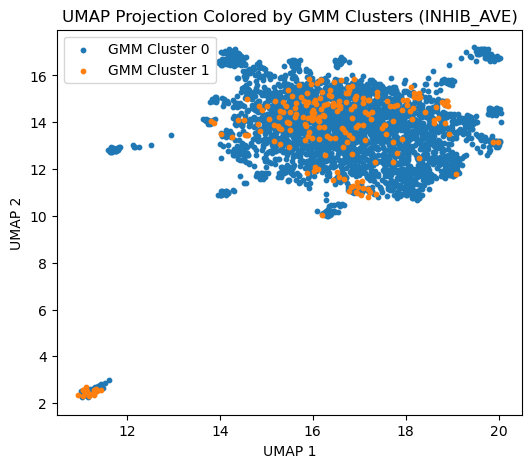

In [69]:
# UMAP on feature space
umap_data = umap.UMAP(
    n_neighbors=30,
    min_dist=0.3,
    random_state=42
).fit_transform(X_train_scaled)

# GMM labels (from y_train)
labels = gmm.predict(y_train.values.reshape(-1, 1))

plt.figure(figsize=(6, 5))

plt.scatter(
    umap_data[labels == 0, 0],
    umap_data[labels == 0, 1],
    s=10,
    label="GMM Cluster 0"
)

plt.scatter(
    umap_data[labels == 1, 0],
    umap_data[labels == 1, 1],
    s=10,
    label="GMM Cluster 1"
)

plt.title("UMAP Projection Colored by GMM Clusters (INHIB_AVE)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.show()

The resulting projection shows that the two GMM clusters are not well separated in the reduced space. In particular, high inhibition samples are largely embedded within regions dominated by low inhibition samples, with substantial overlap between the two groups. This suggests that the probabilistic clustering structure identified by GMM does not align cleanly with distinct separable regions in the feature space.

## UMAP

We use UMAP (Uniform Manifold Approximation and Projection) to visualize our high dimensional data in 2D. This helps us see if active and inactive compounds naturally separate in the feature space. 

/Users/priscillavaskez/opt/miniconda3/envs/chem277a-ds/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


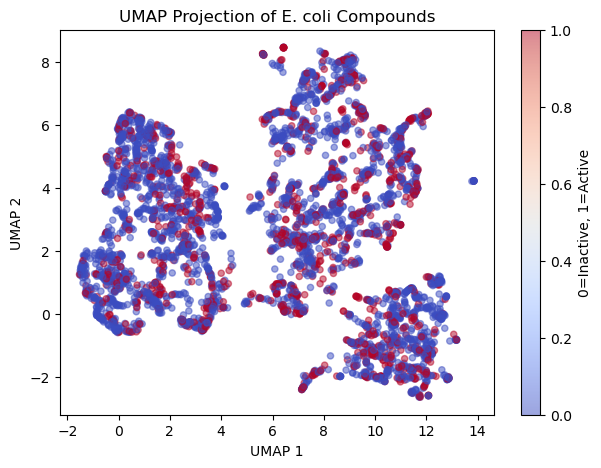

In [70]:
# Use only the original molecular descriptors for UMAP visualization
DESCRIPTOR_COLUMNS = ['MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED']

# Scale just these columns
scaler_umap = StandardScaler()
X_umap_features = scaler_umap.fit_transform(master_df[DESCRIPTOR_COLUMNS])

# Create UMAP reducer
reducer = umap.UMAP(n_components=2, random_state=28)

# Fit and transform
X_umap = reducer.fit_transform(X_umap_features)

# Get labels for all data
y_all = (master_df['INHIB_AVE'] > master_df['INHIB_AVE'].quantile(0.7)).astype(int)

# Plot
fig, ax = plt.subplots(figsize=(7,5))
scatter = ax.scatter(X_umap[:, 0], X_umap[:, 1], c=y_all, cmap='coolwarm', alpha=0.5, s=20)
ax.set_title('UMAP Projection of E. coli Compounds')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.colorbar(scatter, ax=ax, label='0=Inactive, 1=Active')
plt.show()

Looking at the UMAP projection, most compounds are clumped together in one big dense cluster with active and inactive compounds all mixed in together. There is no real separation between the two classes which makes sense given that our models had a hard time identifying active compounds too. 

---------------
## GMM with PCA

This section applies Gaussian Mixture Model (GMM) clustering to PCA-reduced feature space and compares the resulting clusters against true inhibition-based labels defined using both the 70th and 90th percentile thresholds. The visualization shows that while GMM identifies distinct probabilistic clusters in the data, these clusters do not align cleanly with the high and low inhibition groupings. In both the 70% and 90% cases, there is substantial overlap between true labels and GMM-assigned clusters in the PCA space. High inhibition samples are distributed across regions dominated by low inhibition samples, indicating weak separability in the feature representation. This suggests that although GMM captures some underlying structure, it does not recover clear biologically meaningful groupings based on INHIB_AVE. Overall, the clustering results reinforce the difficulty of separating inhibition levels using linear or Gaussian-based assumptions in the current feature space.

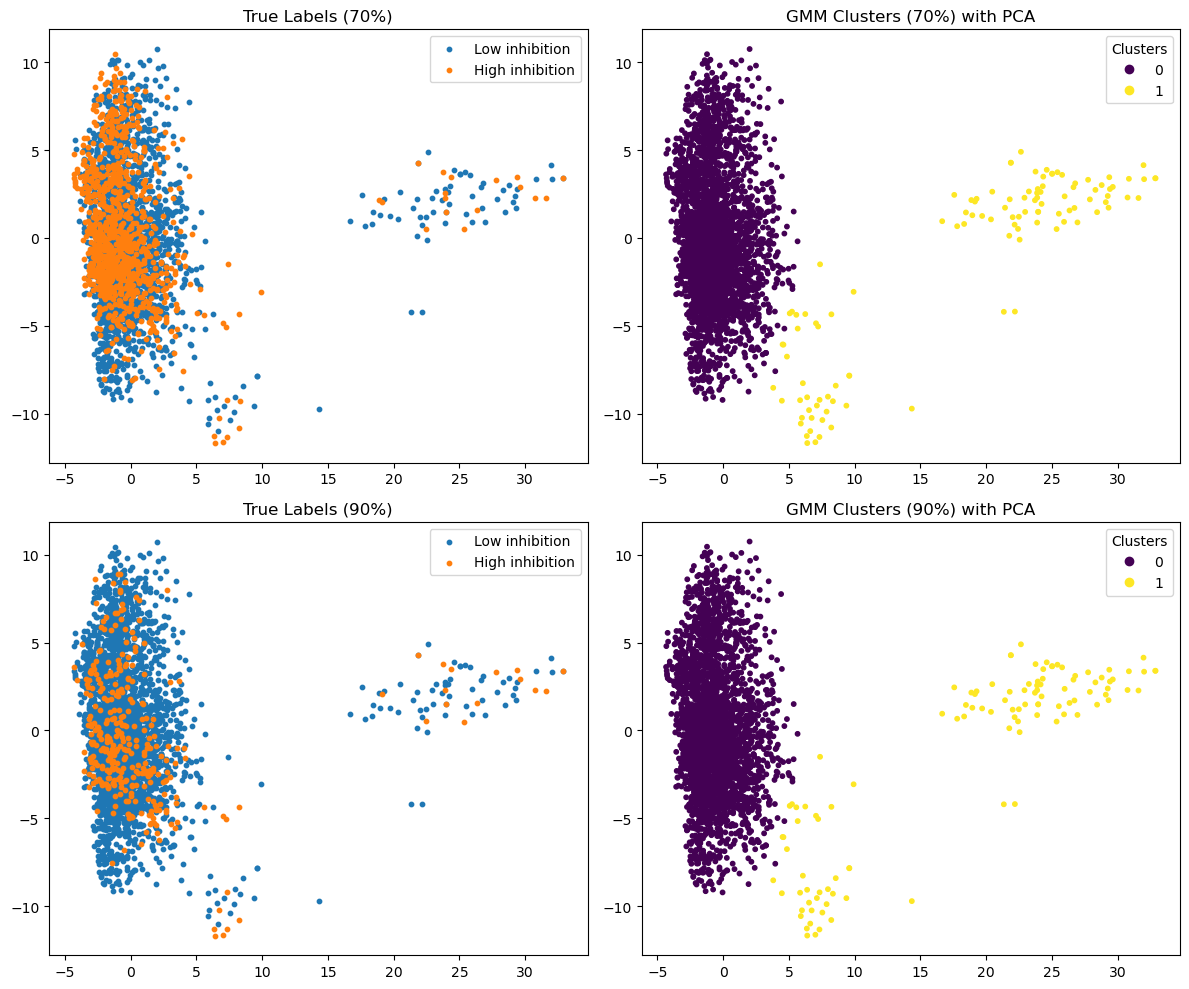

In [71]:
# PCA
pca_gmm = PCA(n_components=2)
X_pca = pca_gmm.fit_transform(X_train_scaled)

# -----------------------
# 70% quantile labels
# -----------------------
threshold_70 = y_train.quantile(0.7)
y_train_class_70 = (y_train > threshold_70).astype(int)

# GMM (70%)
gmm_70 = GaussianMixture(n_components=2, random_state=42)
gmm_labels_70 = gmm_70.fit_predict(X_pca)

# -----------------------
# 90% quantile labels
# -----------------------
threshold_90 = y_train.quantile(0.9)
y_train_class_90 = (y_train > threshold_90).astype(int)

# GMM (90%)
gmm_90 = GaussianMixture(n_components=2, random_state=42)
gmm_labels_90 = gmm_90.fit_predict(X_pca)

# -----------------------
# PLOTS (2x2)
# -----------------------
fig, axes = plt.subplots(2, 2, figsize=(12,10))

# --- True 70% ---
axes[0,0].scatter(
    X_pca[y_train_class_70 == 0, 0],
    X_pca[y_train_class_70 == 0, 1],
    s=10, label="Low inhibition"
)
axes[0,0].scatter(
    X_pca[y_train_class_70 == 1, 0],
    X_pca[y_train_class_70 == 1, 1],
    s=10, label="High inhibition"
)
axes[0,0].set_title("True Labels (70%)")
axes[0,0].legend()

# --- GMM 70% ---
scatter1 = axes[0,1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=gmm_labels_70,
    cmap='viridis',
    s=10
)
axes[0,1].set_title("GMM Clusters (70%) with PCA")
axes[0,1].legend(*scatter1.legend_elements(), title="Clusters")

# --- True 90% ---
axes[1,0].scatter(
    X_pca[y_train_class_90 == 0, 0],
    X_pca[y_train_class_90 == 0, 1],
    s=10, label="Low inhibition"
)
axes[1,0].scatter(
    X_pca[y_train_class_90 == 1, 0],
    X_pca[y_train_class_90 == 1, 1],
    s=10, label="High inhibition"
)
axes[1,0].set_title("True Labels (90%)")
axes[1,0].legend()

# --- GMM 90% ---
scatter2 = axes[1,1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=gmm_labels_90,
    cmap='viridis',
    s=10
)
axes[1,1].set_title("GMM Clusters (90%) with PCA")
axes[1,1].legend(*scatter2.legend_elements(), title="Clusters")

plt.tight_layout()
plt.show()

The PCA-based visualization indicates that the feature space contains a degree of intrinsic structure, with compounds forming partially organized groupings in the reduced-dimensional representation. However, when these projections are colored by the INHIB_AVE-derived labels, there is no clear separation between high and low inhibition classes. This suggests that while the molecular descriptor space captures meaningful variance and underlying structure in the data, this structure does not directly correspond to the target variable. As a result, the relationship between the input features and INHIB_AVE appears to be weakly aligned with linear or low-dimensional separability, limiting the effectiveness of unsupervised projections for distinguishing inhibition levels.

## Set up for Elastic Logistic Regression

## Buffer Filter Check

We estimate how many rows would be considered borderline near each cutoff. Rows close to the cutoff relative to `INHIB_STD` may have unstable labels.

In [72]:
# Buffer filter drop-rate estimate per cutoff
BUFFER_K = 1.5

cutoff_summary = []

for label, cutoff_val in cutoff_grid.items():
    in_buffer = (master_df["INHIB_AVE"] - cutoff_val).abs() < BUFFER_K * master_df["INHIB_STD"]
    cutoff_summary.append({
        "cutoff": label,
        "threshold": round(cutoff_val, 1),
        "buffer_drop": f"{in_buffer.mean():.1%}"
    })

pd.DataFrame(cutoff_summary)

,cutoff,threshold,buffer_drop
0,top 40% (q0.60),10.7,30.7%
1,top 30% (q0.70),13.9,24.5%
2,top 20% (q0.80),18.9,16.2%
3,top 15% (q0.85),23.0,11.2%
4,top 10% (q0.90),30.9,5.4%
5,top 5% (q0.95),60.5,1.2%


---
## Chemistry Space Check

We use Morgan fingerprints and UMAP to visualize the chemical space of the dataset. The goal is to see whether top-10% compounds form a clear local pocket or remain spread across the broader library.Here, the comparison is between the top 10% and the remaining 90%, not active vs inactive.

Morgan fingerprint matrix shape: (4268, 2048)


/Users/priscillavaskez/opt/miniconda3/envs/chem277a-ds/lib/python3.11/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/Users/priscillavaskez/opt/miniconda3/envs/chem277a-ds/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


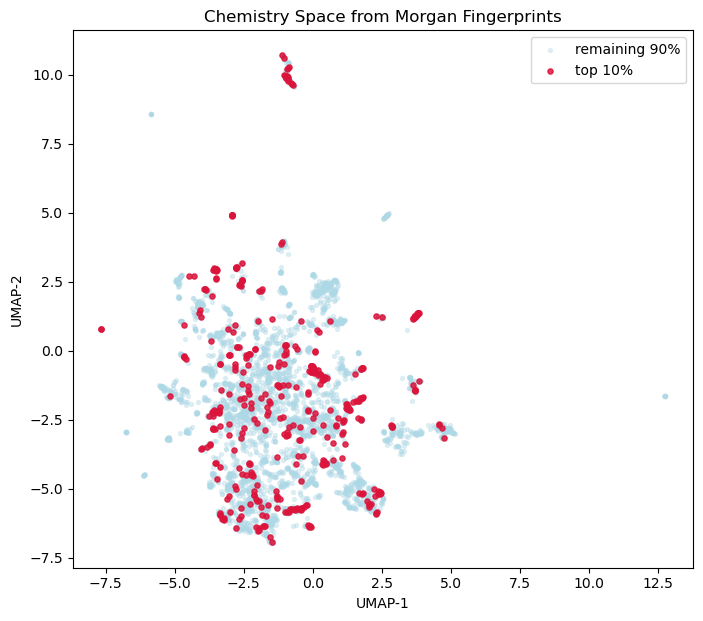

In [73]:
# Morgan fingerprint -> UMAP 2D

# 2048-bit Morgan fingerprint
mfp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
mols = master_df["SMILES"].apply(Chem.MolFromSmiles)

X_fp = np.array([list(mfp_gen.GetFingerprint(m)) for m in mols])
labels = y_top10.values

print("Morgan fingerprint matrix shape:", X_fp.shape)

# UMAP
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="jaccard",
    random_state=28
)

X_umap = umap_model.fit_transform(X_fp)

# Plot
plt.figure(figsize=(8, 7))

plt.scatter(
    X_umap[labels == 0, 0],
    X_umap[labels == 0, 1],
    s=8,
    alpha=0.35,
    color="lightblue",
    label="remaining 90%"
)

plt.scatter(
    X_umap[labels == 1, 0],
    X_umap[labels == 1, 1],
    s=14,
    alpha=0.85,
    color="crimson",
    label="top 10%"
)

ax = plt.gca()
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_title("Chemistry Space from Morgan Fingerprints")
ax.set_aspect("equal", adjustable="box")
ax.legend()

plt.show()

One small region looks enriched in top-10% compounds. To check this more clearly, we run KMeans on the UMAP embedding and compare the top-10% fraction in each cluster.

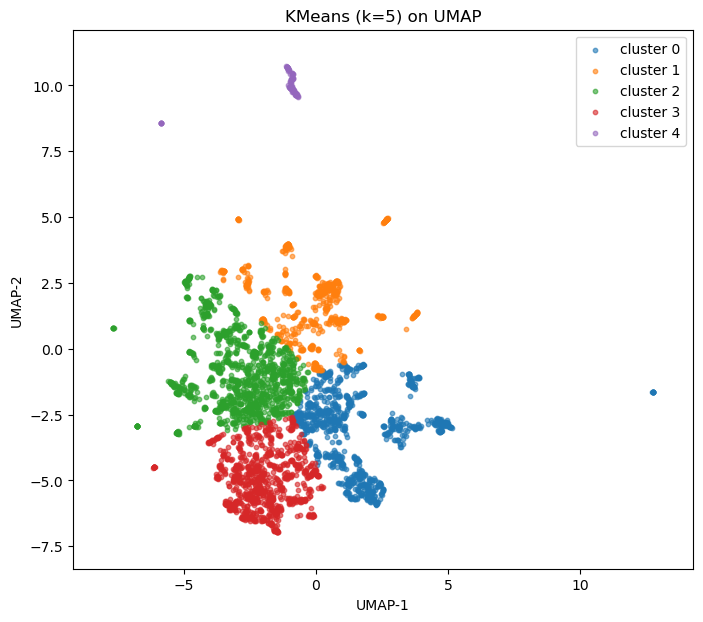

In [74]:
# KMeans on UMAP

K = 5
kmeans = KMeans(n_clusters=K, random_state=28, n_init=10)
clusters = kmeans.fit_predict(X_umap)

fig, ax = plt.subplots(figsize=(8, 7))

for k in range(K):
    mask = clusters == k
    ax.scatter(
        X_umap[mask, 0],
        X_umap[mask, 1],
        s=10,
        alpha=0.6,
        label=f"cluster {k}",
    )

ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_title(f"KMeans (k={K}) on UMAP")
ax.legend()

x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
ax.set_xlim(x_min - 0.5, x_max + 0.5)
ax.set_ylim(y_min - 0.5, y_max + 0.5)

plt.show()

The cluster summary shows one small chemistry pocket enriched in top-10% compounds, while most clusters stay close to the overall baseline. This suggests that coarse chemistry grouping captures part of the signal, but not most of it. So the main prediction task likely depends on finer-grained molecular features and assay-context information.

---
## Train / validation / test split

We first make a stratified train/test split.

Then we split the training side again into:
- model-training
- validation

The test set is kept untouched until final evaluation.

We also remove `INHIB_AVE` and `INHIB_STD` from the feature table before modeling.
These are kept separately because the buffer filter still uses them on the model-training rows.

In [75]:
# Stratified train / validation / test split

features_df = master_df.drop(columns=["INHIB_AVE", "INHIB_STD"])

train_idx, test_idx = train_test_split(master_df.index, test_size=0.2, stratify=y_top10, random_state=28)

train_model_idx, validation_idx = train_test_split(train_idx, test_size=0.2, stratify=y_top10.loc[train_idx], random_state=28)

train_idx = pd.Index(train_idx)
test_idx = pd.Index(test_idx)
train_model_idx = pd.Index(train_model_idx)
validation_idx = pd.Index(validation_idx)

print(f"Train model: {len(train_model_idx)} rows  ({y_top10.loc[train_model_idx].mean():.1%} active)")
print(f"Validation:  {len(validation_idx)} rows  ({y_top10.loc[validation_idx].mean():.1%} active)")
print(f"Test:        {len(test_idx)} rows  ({y_top10.loc[test_idx].mean():.1%} active)")

Train model: 2731 rows  (10.0% active)
Validation:  683 rows  (10.0% active)
Test:        854 rows  (10.0% active)


---
## Buffer filter on model-training rows

The binary label is defined by a hard cutoff at the 90th percentile of `INHIB_AVE` (about 30.9%). Compounds whose measured value falls within the experimental uncertainty (`INHIB_STD`) of this cutoff can have unstable labels. Even a small fluctuation in the underlying measurement could flip them between the top-10% class and the rest. Training on these borderline rows would teach the model a decision rule built partly on measurement noise.

We drop model-training rows where `|INHIB_AVE - cutoff| < 1.5 × INHIB_STD`. The factor `BUFFER_K = 1.5` is wide enough to remove the genuinely ambiguous cases while still preserving most of the data. The filter is applied to model-training rows only. Validation and test rows stay untouched so the evaluation still reflects performance on the full, unfiltered distribution.

In [76]:
# Buffer filter on model-training rows

BUFFER_K = 1.5

distance_from_cutoff = (y - top10_cutoff).abs()
buffer_width = BUFFER_K * inhib_std.fillna(0.0)
in_buffer_full = distance_from_cutoff < buffer_width

ambiguous_train_idx = train_model_idx.intersection(master_df.index[in_buffer_full])
train_model_idx_clean = train_model_idx.difference(ambiguous_train_idx)

drop_rate = len(ambiguous_train_idx) / len(train_model_idx)

print(f"After buffer: {len(train_model_idx_clean)} rows ({y_top10.loc[train_model_idx_clean].mean():.1%} top 10%)")
print(f"Dropped: {len(ambiguous_train_idx)} rows ({drop_rate:.1%})")
print(f"Validation untouched: {len(validation_idx)} rows")
print(f"Test untouched: {len(test_idx)} rows")

After buffer: 2598 rows (8.7% top 10%)
Dropped: 133 rows (4.9%)
Validation untouched: 683 rows
Test untouched: 854 rows


---

## Feature matrix construction

We assemble a 2,447-dimensional feature representation that combines four main sources of chemical and experimental signal.

The first block is **assay-context numeric features**: `DMAX_AVE`, `MIC_VALUE_uM`, and `CONC_VALUE_uM`. These capture the dose-response context of each measurement and were already highly informative in our earlier regression analysis. The second block is categorical assay metadata one-hot encoded from `STRAIN` and `MIC_OPERATOR`. The latter is especially useful because censored MIC values with the `>` operator carry distinct information about weakly inhibitory or non-top-10% compounds.

The third block consists of **chemistry features computed from SMILES**: 210 RDKit descriptors covering physicochemical properties such as logP, TPSA, HBA/HBD counts, and ring counts, 160 MACCS keys encoding standardized substructural patterns, and 2,048-bit Morgan fingerprints with radius 2 that capture local atomic environments at fine resolution. The fourth block is **20 Tanimoto similarity features** computed against the top-10% set on the training partition only. These features measure how chemically similar each compound is to known top-10% compounds using Morgan and MACCS fingerprints. Computing these similarity features on the training set only, rather than the full dataset, helps prevent test-set information from leaking back into the training representation.

We keep all four blocks and let elastic net regularization handle redundancy during training instead of manually removing features ahead of time. This lets the model decide which signals are most informative.

In [77]:
# Feature matrix construction

# Tanimoto reference indices from cleaned model-training rows
top10_train_idx = train_model_idx_clean[y_top10.loc[train_model_idx_clean].eq(1)].tolist()
remaining90_train_idx = train_model_idx_clean[y_top10.loc[train_model_idx_clean].eq(0)].tolist()

# 1. Assay numeric features ------------------
def parse_conc(s):
    nums = re.findall(r"\d+\.?\d*", str(s))
    return float(nums[0]) if nums else np.nan


def conc_to_uM(row):
    s = str(row["CONC"])
    val = parse_conc(s)

    if pd.isna(val):
        return np.nan
    if "uM" in s:
        return val
    if "ug/mL" in s:
        return val * 1000 / row["MW"]

    return np.nan


conc_uM = master_df.apply(conc_to_uM, axis=1)

X_numeric = pd.DataFrame(
    {
        "DMAX_AVE": master_df["DMAX_AVE"],
        "MIC_VALUE_uM": master_df["MIC_VALUE_uM"],
        "CONC_VALUE_uM": conc_uM,
    },
    index=master_df.index
)

# 2. Assay categorical features ------------------
X_categorical = pd.get_dummies(
    master_df[["STRAIN", "MIC_OPERATOR"]].astype(str),
    prefix=["STRAIN", "MIC_OPERATOR"],
    drop_first=False
).astype(int)

# 3. RDKit descriptors ------------------
mols = master_df["SMILES"].apply(Chem.MolFromSmiles)


def compute_rdkit_descriptors(mol):
    return {
        f"rdkit_{name}": func(mol) if mol is not None else np.nan
        for name, func in Descriptors._descList
    }


X_rdkit = pd.DataFrame(
    [compute_rdkit_descriptors(mol) for mol in mols],
    index=master_df.index,
).replace([np.inf, -np.inf], np.nan)

X_rdkit = X_rdkit.dropna(axis=1, how="all")
X_rdkit = X_rdkit.loc[:, X_rdkit.nunique(dropna=True) > 1]

# 4. MACCS keys ------------------
def fp_to_array(fp, n_bits, skip_first=False):
    arr = np.zeros(n_bits, dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr[1:] if skip_first else arr


maccs_fps = [MACCSkeys.GenMACCSKeys(mol) for mol in mols]

X_maccs = pd.DataFrame(
    [fp_to_array(fp, 167, skip_first=True) for fp in maccs_fps],
    index=master_df.index,
    columns=[f"maccs_{i}" for i in range(1, 167)],
)

X_maccs = X_maccs.loc[:, X_maccs.nunique() > 1]

# 5. Morgan fingerprints ------------------
mfp_gen = GetMorganGenerator(radius=2, fpSize=2048)
morgan_fps = [mfp_gen.GetFingerprint(mol) for mol in mols]

X_morgan = pd.DataFrame(
    [fp_to_array(fp, 2048) for fp in morgan_fps],
    index=master_df.index,
    columns=[f"morgan_r2_{i}" for i in range(2048)],
)

# 6. Tanimoto similarity features ------------------
def top_k_mean(values, k):
    return np.sort(values)[::-1][:k].mean() if len(values) >= 1 else np.nan


def tanimoto_features(fps, ref_indices, prefix):
    ref_pairs = [(i, fps[i]) for i in ref_indices if fps[i] is not None]

    rows = []
    cols = [f"{prefix}_{stat}" for stat in ["max", "mean", "top5_mean", "top10_mean", "count_ge_0_50"]]

    for idx in master_df.index:
        fp = fps[idx]
        valid_refs = [rfp for ri, rfp in ref_pairs if ri != idx]

        if fp is None or not valid_refs:
            rows.append({c: np.nan for c in cols})
            continue

        similarity_scores = np.array(DataStructs.BulkTanimotoSimilarity(fp, valid_refs))

        rows.append(
            {
                cols[0]: similarity_scores.max(),
                cols[1]: similarity_scores.mean(),
                cols[2]: top_k_mean(similarity_scores, 5),
                cols[3]: top_k_mean(similarity_scores, 10),
                cols[4]: int((similarity_scores >= 0.50).sum()),
            }
        )

    return pd.DataFrame(rows, index=master_df.index)


X_tanimoto = pd.concat(
    [
        tanimoto_features(morgan_fps, top10_train_idx, "tan_morgan_top10"),
        tanimoto_features(morgan_fps, remaining90_train_idx, "tan_morgan_remaining90"),
        tanimoto_features(maccs_fps, top10_train_idx, "tan_maccs_top10"),
        tanimoto_features(maccs_fps, remaining90_train_idx, "tan_maccs_remaining90"),
    ],
    axis=1,
)

# Combine feature blocks ------------------
X_full = pd.concat([X_numeric, X_categorical, X_rdkit, X_maccs, X_morgan, X_tanimoto], axis=1)

X_train = X_full.loc[train_model_idx_clean]
X_validation = X_full.loc[validation_idx]
X_test = X_full.loc[test_idx]

y_train = y_top10.loc[train_model_idx_clean]
y_validation = y_top10.loc[validation_idx]
y_test = y_top10.loc[test_idx]

print("Numeric:", X_numeric.shape)
print("Categorical:", X_categorical.shape)
print("RDKit:", X_rdkit.shape)
print("MACCS:", X_maccs.shape)
print("Morgan:", X_morgan.shape)
print("Tanimoto:", X_tanimoto.shape)
print("X_full:", X_full.shape)
print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)

Numeric: (4268, 3)
Categorical: (4268, 6)
RDKit: (4268, 210)
MACCS: (4268, 160)
Morgan: (4268, 2048)
Tanimoto: (4268, 20)
X_full: (4268, 2447)
X_train: (2598, 2447)
X_validation: (683, 2447)
X_test: (854, 2447)


---
## Handling missing values

A small number of RDKit descriptors fail for some compounds. Most of these come from BCUT2D descriptors and partial-charge-related features. Before choosing an imputation strategy, we first check how much missingness exists in the training feature matrix. Since the missing rate is very small, replacing with median is enough here.

In [78]:
# NaN diagnostic

nan_per_col = X_train.isna().sum()
cols_with_nan = (nan_per_col > 0).sum()
total_nan = nan_per_col.sum()
total_cells = X_train.size

print("Columns with any NaN:", cols_with_nan, "/", X_train.shape[1])
print("Total NaN cells:", total_nan, "/", total_cells, f"({total_nan / total_cells:.3%})")
print()
print("Top 10 columns by NaN count:")

nan_per_col[nan_per_col > 0].sort_values(ascending=False).head(10)

Columns with any NaN: 12 / 2447
Total NaN cells: 408 / 6357306 (0.006%)

Top 10 columns by NaN count:


rdkit_BCUT2D_MWHI         41
rdkit_BCUT2D_MWLOW        41
rdkit_BCUT2D_CHGHI        41
rdkit_BCUT2D_CHGLO        41
rdkit_BCUT2D_LOGPHI       41
rdkit_BCUT2D_LOGPLOW      41
rdkit_BCUT2D_MRHI         41
rdkit_BCUT2D_MRLOW        41
rdkit_MaxPartialCharge    20
rdkit_MinPartialCharge    20
dtype: int64

## Imputation and feature scaling

The missing rate is very small in the training feature matrix. Most missing values come from a small number of RDKit descriptors, especially BCUT2D and partial-charge-related features. Because the there are only a few features missing, replacing with median is acceptable here. After imputation, we apply `StandardScaler` so all features are on a comparable scale. The medians and scaling parameters are learned from the training set only, then applied to the validation and test sets.

In [79]:
# Median imputation and feature scaling

train_medians = X_train.median()
X_train_filled = X_train.fillna(train_medians)
X_validation_filled = X_validation.fillna(train_medians)
X_test_filled = X_test.fillna(train_medians)

scaler = StandardScaler()
X_train_S = pd.DataFrame(scaler.fit_transform(X_train_filled), index=X_train.index, columns=X_train.columns)
X_validation_S = pd.DataFrame(scaler.transform(X_validation_filled), index=X_validation.index, columns=X_validation.columns)
X_test_S = pd.DataFrame(scaler.transform(X_test_filled), index=X_test.index, columns=X_test.columns)

print("X_train_S:", X_train_S.shape)
print("X_validation_S:", X_validation_S.shape)
print("X_test_S:", X_test_S.shape)
print("Train mean:", f"{X_train_S.values.mean():.3f}")
print("Train std:", f"{X_train_S.values.std():.3f}")

X_train_S: (2598, 2447)
X_validation_S: (683, 2447)
X_test_S: (854, 2447)
Train mean: -0.000
Train std: 0.999


---
## Elastic Net Logistic Regression

We use `LogisticRegressionCV` with an elastic-net.

This is still logistic regression, but the elastic-net penalty helps in two ways:
1. it shrinks weak coefficients toward zero
2. it stabilizes the model when many correlated features are present

We first tested the classification approach with statsmodels GLM/logistic regression in `svm_linear_log_cluster.ipynb`, including a manually selected feature set and an elastic net regularized GLM. Those models helped show that logistic classification was a reasonable direction, but the active-class recall and F1 were still limited.

In the final notebook, we rebuilt the model using scikit-learn instead of statsmodels, but the main difference was not just the library. The final model used a much larger and more targeted engineered feature set, including assay-aware variables, RDKit descriptors, MACCS keys, 2048-bit Morgan fingerprints, and Tanimoto similarity to top10% features computed from those Morgan fingerprints. We also tuned the regularization more carefully using cross-validation over `C` and `l1_ratio`, so the model could shrink noisy features while keeping only the strongest predictors.

We first tested elastic-net logistic regression using LogisticRegression with GridSearchCV, then tested LogisticRegressionCV, which performs the cross-validation internally over the regularization path. Both approaches selected a similar strongly regularized region, but LogisticRegressionCV gave slightly better held-out F1 and precision. For that reason, we used LogisticRegressionCV as the final model.

We search over:
- `C = [0.003, 0.005, 0.007, 0.01, 0.015, 0.02, 0.03, 0.05]`
- `l1_ratio = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]`

We use 5-fold cross-validation with F1 as the scoring metric.

We also keep `class_weight="balanced"` because the top-10% class is much smaller than the remaining 90%.

In [80]:
# Elastic Net Logistic Regression

model_Cs = [0.003, 0.005, 0.007, 0.01, 0.015, 0.02, 0.03, 0.05]
model_l1_ratios = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]

elastic_net_logreg = LogisticRegressionCV(
    Cs=model_Cs,
    cv=5,
    solver="saga",
    scoring="f1",
    class_weight="balanced",
    l1_ratios=model_l1_ratios,
    max_iter=5000,
    random_state=28,
    tol = 0.001,
    n_jobs=-1
)

elastic_net_logreg.fit(X_train_S, y_train)

best_C = float(elastic_net_logreg.C_[0])
best_l1_ratio = float(elastic_net_logreg.l1_ratio_[0])

cv_scores = elastic_net_logreg.scores_[1]
best_cv_f1 = cv_scores.mean(axis=0).max()

print("Best C:", best_C)
print("Best l1_ratio:", best_l1_ratio)
print("Best CV F1:", f"{best_cv_f1:.4f}")

/Users/priscillavaskez/opt/miniconda3/envs/chem277a-ds/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


Best C: 0.003
Best l1_ratio: 0.8
Best CV F1: 0.7441


---
## Evaluating on the test set

We evaluate the final model on the held-out test set using the default threshold of `0.5`.

We report precision, recall, F1, accuracy, balanced accuracy, ROC-AUC, and the confusion matrix counts.

,model,n_features,best_C,best_l1_ratio,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,TN,FP,FN,TP,threshold_type
0,Elastic Net Logistic CV (buffer-filtered train),2447,0.003,0.8,0.5,0.940281,0.851733,0.684783,0.741176,0.711864,0.949606,740,29,22,63,default_0.5


               precision    recall  f1-score   support

remaining 90%       0.97      0.96      0.97       769
      top 10%       0.68      0.74      0.71        85

     accuracy                           0.94       854
    macro avg       0.83      0.85      0.84       854
 weighted avg       0.94      0.94      0.94       854



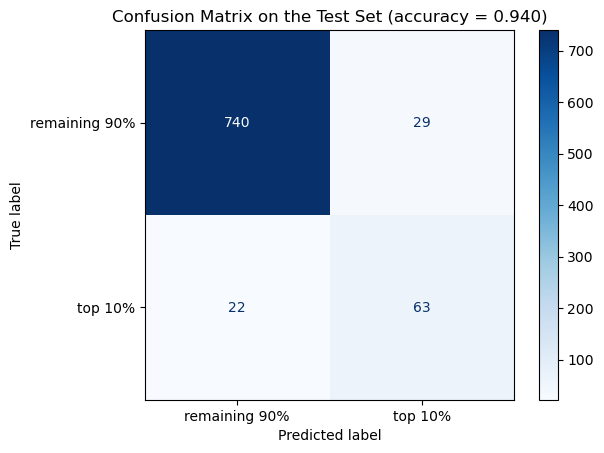

In [81]:
# Test set evaluation at threshold = 0.5

test_prob = elastic_net_logreg.predict_proba(X_test_S)[:, 1]
y_pred = (test_prob >= 0.5).astype(int)

final_test_results_df = pd.DataFrame(
    [
        {
            "model": "Elastic Net Logistic CV (buffer-filtered train)",
            "n_features": X_train_S.shape[1],
            "best_C": best_C,
            "best_l1_ratio": best_l1_ratio,
            "threshold": 0.5,
            "accuracy": accuracy_score(y_test, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, test_prob),
            "TN": int(confusion_matrix(y_test, y_pred).ravel()[0]),
            "FP": int(confusion_matrix(y_test, y_pred).ravel()[1]),
            "FN": int(confusion_matrix(y_test, y_pred).ravel()[2]),
            "TP": int(confusion_matrix(y_test, y_pred).ravel()[3]),
            "threshold_type": "default_0.5"
        }
    ]
)

display(final_test_results_df)
print(classification_report(y_test, y_pred, target_names=["remaining 90%", "top 10%"]))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["remaining 90%", "top 10%"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix on the Test Set (accuracy = {accuracy_score(y_test, y_pred):.3f})")
plt.show()

---
## Selected features and their contribution

The elastic-net penalty shrinks most coefficients to zero, so the final model keeps only a small subset of the 2,447 input features.

Because all features were standardized before fitting, the coefficient sizes can be compared directly. Larger `|coef_i|` values mean that a feature has a stronger effect on the predicted log-odds of belonging to the top-10% class.

We summarize the selected features in two ways. First, we show a per-feature table with the coefficient sign, absolute size, and contribution percentage. Second, we group the selected features by category, such as assay-context, RDKit, MACCS, Morgan, and Tanimoto, to see whether the model is driven more by experimental context or by molecular features.

In [82]:
# Selected features only

coefs = pd.Series(
    elastic_net_logreg.coef_.ravel(),
    index=X_train_S.columns,
    name="coefficient",
)

selected = coefs[coefs != 0].copy()
total_abs = selected.abs().sum()

feature_summary = pd.DataFrame({"coefficient": selected})
feature_summary["abs_coefficient"] = feature_summary["coefficient"].abs()
feature_summary["contribution_pct"] = (feature_summary["abs_coefficient"] / total_abs * 100).round(2)
feature_summary = feature_summary.sort_values("abs_coefficient", ascending=False)
feature_summary["cumulative_pct"] = feature_summary["contribution_pct"].cumsum().round(2)


def category_of(name):
    if name.startswith("DMAX_AVE") or name.startswith("MIC_VALUE_uM") or name.startswith("CONC_VALUE_uM"):
        return "assay_numeric"
    if name.startswith("STRAIN_") or name.startswith("MIC_OPERATOR_"):
        return "assay_categorical"
    if name.startswith("rdkit_"):
        return "rdkit"
    if name.startswith("maccs_"):
        return "maccs"
    if name.startswith("morgan_"):
        return "morgan"
    if name.startswith("tan_"):
        return "tanimoto"
    return "other"


feature_summary["category"] = [category_of(name) for name in feature_summary.index]

feature_summary = feature_summary[["category", "coefficient", "abs_coefficient", "contribution_pct", "cumulative_pct"]]

display(feature_summary)

,category,coefficient,abs_coefficient,contribution_pct,cumulative_pct
DMAX_AVE,assay_numeric,0.836809,0.836809,82.34,82.34
tan_morgan_top10_count_ge_0_50,tanimoto,0.090633,0.090633,8.92,91.26
tan_morgan_top10_max,tanimoto,0.088874,0.088874,8.74,100.00


---

## Ablation checks

Before calling the final model done, I wanted to check where the performance is actually coming from.

Here I rerun the same Elastic Net Logistic RegressionCV setup with a few simpler feature sets:
- `DMAX_AVE` only
- full model without the Tanimoto similarity features
- full model without the buffer filtering step

This is mostly a sanity check. If the full model beats these simpler versions, then the extra feature engineering is doing something useful instead of just adding noise.

In [83]:
# Ablation checks with the same Elastic Net LogisticRegressionCV setup

ablation_rows = []


def run_ablation(name, X_table, train_rows):
    X_train_ab = X_table.loc[train_rows]
    X_test_ab = X_table.loc[test_idx]
    y_train_ab = y_top10.loc[train_rows]

    medians = X_train_ab.median()
    X_train_ab = X_train_ab.fillna(medians)
    X_test_ab = X_test_ab.fillna(medians)

    scaler = StandardScaler()
    X_train_ab = pd.DataFrame(
        scaler.fit_transform(X_train_ab),
        index=X_train_ab.index,
        columns=X_train_ab.columns
    )
    X_test_ab = pd.DataFrame(
        scaler.transform(X_test_ab),
        index=X_test_ab.index,
        columns=X_test_ab.columns
    )

    model = LogisticRegressionCV(
        Cs=model_Cs,
        cv=5,
        solver="saga",
        scoring="f1",
        class_weight="balanced",
        l1_ratios=model_l1_ratios,
        max_iter=5000,
        random_state=28,
        tol=0.001,
        n_jobs=-1
    )

    model.fit(X_train_ab, y_train_ab)

    test_prob_ab = model.predict_proba(X_test_ab)[:, 1]
    y_pred_ab = (test_prob_ab >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_ab).ravel()

    ablation_rows.append(
        {
            "feature_set": name,
            "n_features": X_table.shape[1],
            "best_C": float(model.C_[0]),
            "best_l1_ratio": float(model.l1_ratio_[0]),
            "selected_features": int((model.coef_.ravel() != 0).sum()),
            "accuracy": accuracy_score(y_test, y_pred_ab),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_ab),
            "precision": precision_score(y_test, y_pred_ab, zero_division=0),
            "recall": recall_score(y_test, y_pred_ab, zero_division=0),
            "f1": f1_score(y_test, y_pred_ab, zero_division=0),
            "roc_auc": roc_auc_score(y_test, test_prob_ab),
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "TP": int(tp)
        }
    )


# Same feature set as the final model
run_ablation("full model", X_full, train_model_idx_clean)

# Strong assay-derived signal by itself
run_ablation("DMAX_AVE only", X_full[["DMAX_AVE"]], train_model_idx_clean)

# Full feature set, but remove the engineered Tanimoto similarity features
no_tanimoto_cols = [c for c in X_full.columns if not c.startswith("tan_")]
run_ablation("without Tanimoto", X_full[no_tanimoto_cols], train_model_idx_clean)

# No buffer filter: rebuild Tanimoto references using all model-training rows
top10_idx_no_buffer = train_model_idx[y_top10.loc[train_model_idx].eq(1)].tolist()
remaining90_idx_no_buffer = train_model_idx[y_top10.loc[train_model_idx].eq(0)].tolist()

X_tanimoto_no_buffer = pd.concat(
    [
        tanimoto_features(morgan_fps, top10_idx_no_buffer, "tan_morgan_top10"),
        tanimoto_features(morgan_fps, remaining90_idx_no_buffer, "tan_morgan_remaining90"),
        tanimoto_features(maccs_fps, top10_idx_no_buffer, "tan_maccs_top10"),
        tanimoto_features(maccs_fps, remaining90_idx_no_buffer, "tan_maccs_remaining90"),
    ],
    axis=1
)

X_full_no_buffer = pd.concat([X_numeric, X_categorical, X_rdkit, X_maccs, X_morgan, X_tanimoto_no_buffer], axis=1)

run_ablation("no buffer filter", X_full_no_buffer, train_model_idx)

ablation_results = pd.DataFrame(ablation_rows).sort_values("f1", ascending=False).reset_index(drop=True)
ablation_results

/Users/priscillavaskez/opt/miniconda3/envs/chem277a-ds/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(
/Users/priscillavaskez/opt/miniconda3/envs/chem277a-ds/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period

,feature_set,n_features,best_C,best_l1_ratio,selected_features,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,TN,FP,FN,TP
0,full model,2447,0.003,0.8,3,0.940281,0.851733,0.684783,0.741176,0.711864,0.949606,740,29,22,63
1,DMAX_AVE only,1,0.003,0.5,1,0.940281,0.825572,0.707317,0.682353,0.694611,0.906525,745,24,27,58
2,without Tanimoto,2427,0.003,0.5,17,0.939110,0.814457,0.708861,0.658824,0.682927,0.927553,746,23,29,56
3,no buffer filter,2447,0.003,0.8,3,0.928571,0.855695,0.613208,0.764706,0.680628,0.951931,728,41,20,65


## Evaluation

## Discussion


**Discussion SVM RBF**

Across the SVM RBF experiments, three configurations were evaluated: a 70th percentile threshold model, a 90th percentile threshold model, and a tuned 90th percentile model. The 70th percentile model achieved strong training performance (accuracy 0.93) but lower test performance (accuracy 0.74), with reduced performance on the minority class (high inhibition), where precision was 0.57 and recall was 0.54, indicating overfitting and limited generalization. The 90th percentile model improved overall test accuracy to 0.92, with strong majority class performance (precision 0.95, recall 0.96) but weaker high inhibition performance (precision 0.59, recall 0.49), reflecting persistent class imbalance effects. The tuned 90th percentile model achieved a test accuracy of about 0.90, with majority class performance remaining high (precision 0.96, recall 0.92) while high inhibition performance improved in recall to 0.68 but decreased in precision to 0.48. This indicates that tuning improved the model’s ability to identify more high inhibition compounds but also increased false positives. Across all models, the majority class consistently showed strong and stable performance, while the high inhibition class remained more difficult to classify reliably. The 90th percentile models performed better than the 70th percentile model in terms of overall test accuracy and generalization. However, improvements from hyperparameter tuning mainly shifted the precision–recall trade-off rather than resolving class overlap. These results suggest that threshold selection has a stronger impact on model behavior than tuning alone. Overall, the tuned 90th percentile SVM provides the best recall for high inhibition compounds (0.68), while the 90th percentile baseline offers the best balance between precision and stability.


**Discussion Linear Regression** 

Across the linear regression experiments, several progressively refined approaches were used to model the relationship between molecular descriptors and INHIB_AVE. The initial simple linear regression provided a baseline performance with an R2 of 0.40 and relatively high error (RMSE about 17.01, MAE about 12.49), indicating that the model captures some structure in the data but leaves a large portion of variability unexplained. Visual inspection showed a dense central cluster of predictions with noticeable scatter away from the diagonal line, particularly in the mid-range (approximately -10 to 30), suggesting limited linear structure and substantial noise. Feature selection using p-value filtering improved performance, increasing test R2 to 0.54 and reducing error (RMSE about 15.01, MAE about 10.42), while also improving alignment between training and test results, suggesting reduced overfitting. Despite this improvement, predictions still showed considerable dispersion around the diagonal, especially for higher inhibition values, indicating that important nonlinear relationships were not captured. Restricting the dataset to the -20 to 30 range further changed model behavior but led to a sharp drop in performance, with R2 decreasing to 0.05 and MAE increasing to 6.71, suggesting that removing extreme values also removed informative variation needed to capture broader trends. Weighted Least Squares (WLS) regression was then applied to address heteroscedasticity by assigning weights inversely proportional to observation variance, aiming to reduce the influence of noisy measurements. However, all tested WLS configurations produced strongly negative R2 values and large RMSE, indicating that the weighting scheme based on INHIB_STD does not align with the true error structure of the data. Instead of stabilizing the regression fit, the applied weights appear to amplify sensitivity to noisy observations, leading to unstable parameter estimates. Overall, the consistently poor performance across linear regression variants further supports the conclusion that the relationship between molecular descriptors and INHIB_AVE is likely nonlinear and cannot be adequately captured using linear models alone.


**Discussion for ANN** 

The first version of the ANN got 93% accuracy but it was really overfitting since the validation loss kept pulling away from the training loss after about 10 epochs. This probably happened for a few reasons. We had 1037 features, 13 molecular descriptors plus 1024 Morgan fingerprint bits, but only about 3,400 training samples. So the model had way more knobs to tune than it had examples to learn from. On top of that, the class imbalance was pretty bad with only 10% of compounds being active, so the model could get high accuracy just by predicting inactive most of the time. And there was no regularization in the original setup, which means nothing was stopping the model from memorizing the training data. To fix the overfitting L2 regularization lambda = 0.01 was added and early stopping patience = 10. L2 penalized large weights so the model couldn't lean too hard on any single feature, and early stopping cut off training before the validation loss could get worse. Together they brought the validation loss curve much closer to the training loss curve which is what we wanted to see. Recall on the active class also bumped up from 49% to 57%, so it helped with the imbalance a little bit too. Even after this though, recall was still only 57% which means the model was still missing a lot of the actually active compounds. So we added class weights with the active class weighted 9 times heavier than inactive, this pushed the model to actually try to learn the minority class. Recall jumped to 63% in version 3. We also tried 12x in version 4 just to see if pushing it harder would help, but it didn't really help and actually made things slightly worse, which tells us 9x was the sweet spot for this dataset.Version 3 is the best version overall. For drug screening, missing a real active compound is way worse than flagging an inactive one as potentially active. Version 3 had slightly lower accuracy than version 2 (92% vs 94%) but caught more real actives, which is what matters for shortlisting drugs. The whole point of this model is to help narrow down which compounds are worth testing further, so we're okay trading some accuracy for better recall on the active class.There are still some limitations though. Recall on the active class is still only 63%, meaning we're missing about 37% of truly active compounds. The dataset is also pretty small for an ANN with only around 4,268 compounds total, and neural networks usually do better with more data. The class imbalance is also severe on purpose since we used the top 10% threshold, and class weights helped but didn't fully fix it. We also only used a single hidden layer to keep things simple, but a deeper network could maybe capture more complex patterns if we had more data to support it. For both ANN models the ANN results reported here are from the final combined notebook run. They may differ slightly from earlier individual notebook runs because neural network training can vary after rerunning the full workflow.

**Discussion for ANN Improvements (SMOTE Oversampling and Two-Layer Architecture)**

Two further variants were explored to test whether the ANN's minority-class performance could be improved beyond what class weighting alone provided. The first variant replaces class weighting with SMOTE-based synthetic minority oversampling (Chawla et al. 2002). Compared to the class-weighted variant, the SMOTE configuration improved nearly every metric: F1 on actives rose from 0.578 to 0.637, precision from 0.553 to 0.689, ROC-AUC from 0.886 to 0.901, and PR-AUC from 0.673 to 0.698. Recall on actives stayed essentially flat (0.605 to 0.593), so the gain came from substantially fewer false positives rather than catching more true actives.
The second variant uses SMOTE's expanded training set to support a deeper architecture: a two-hidden-layer network (64 then 32 ReLU units) with dropout between layers (0.3 and 0.2). Koutsoukas et al. (2017) identified the number of hidden layers among the most critical hyperparameters for bioactivity prediction tasks. The two-layer SMOTE configuration improved further on F1 (0.643 vs 0.637) and recall on actives (0.628 vs 0.593), with comparable accuracy (0.930 vs 0.932) and ROC-AUC (0.904 vs 0.901). This variant strictly improves over the V1 baseline on every minority-class metric.
Threshold tuning was also performed (Esposito et al. 2021). At threshold 0.50 the model favors recall (0.605 with precision 0.553); at the F1-optimal threshold 0.78 it favors precision (0.723 with recall 0.547). For primary screening the lower threshold is preferred; for hit-list confirmation the higher threshold is preferred.

**Discussion for Elastic Ne**t

The final Elastic Net Logistic RegressionCV model worked best as an assay-aware top-10% inhibition classifier. On the test set, it reached `accuracy = 0.9403`, `balanced accuracy = 0.8517`, `precision = 0.6848`, `recall = 0.7412`, `F1 = 0.7119`, and `ROC-AUC = 0.9496`. Since the top-10% label is imbalanced, `recall`, `F1`, and `ROC-AUC` were more informative than accuracy alone.
The two selected Tanimoto features suggest that the model was not only using the assay-derived `DMAX_AVE` signal, but also learning whether a compound sits near an active chemical neighborhood. `tan_morgan_top10_max` captures the strongest Morgan fingerprint similarity to any top-10% inhibitor, while `tan_morgan_top10_count_ge_0_50` counts how many top-10% inhibitors are moderately similar to the compound. Their selection by Elastic Net suggests that structural similarity to known high-inhibition compounds added meaningful chemical context to the classifier.
The ablation results supported this overall, but with one interesting caveat. `DMAX_AVE` alone was already strong, but the full model still had better F1 and a better overall balance of precision and recall. Removing the Tanimoto features lowered performance, suggesting that the similarity features added useful chemical context. Removing the buffer filter actually resulted `recall = 0.7647`, which was surprising, but it also increased false positives and lowered precision/F1. So if recall were the only priority, the no-buffer model could be considered; however, for a more balanced screening model, the buffered full model was still the better choice.


## Contributions


**Contribution of Trinity Ho**: 
I implemented and evaluated multiple machine learning and statistical modeling approaches to analyze molecular inhibition activity (INHIB_AVE) using molecular descriptors and engineered molecular fingerprint features. My contributions included developing several linear regression pipelines, including baseline ordinary least squares regression, feature-selected regression, filtered response window regression, and Weighted Least Squares regression with inverse variance-inspired error weighting. I also implemented logistic regression models with feature engineering and binary quantile-based classification to investigate inhibition classification performance under different threshold definitions. In addition, I designed and tuned Support Vector Machine (SVM) models with RBF kernels using cross-validation and hyperparameter optimization to improve classification of high inhibition compounds. To further investigate feature space structure and separability, I applied dimensionality reduction and clustering methods including PCA, UMAP, K-Means clustering, and Gaussian Mixture Models.

**Contribution of Dongwan Kim**:
My contribution focused on data preprocessing and the final Elastic Net Logistic Regression pipeline. I helped clean and merge the CO-ADD inhibition and dose-response CSV files, filter the dataset to *E. coli*, and create the processed master dataframe used for modeling. After the early regression results showed that exact `INHIB_AVE` prediction was unreliable from Trinity's contribution, I helped reframe the task as top-10% inhibition classification. For the final model, I built the assay-aware feature matrix using assay-context variables, RDKit descriptors, MACCS keys, 2048-bit Morgan fingerprints, and Tanimoto similarity features, then trained and evaluated the scikit-learn `LogisticRegressionCV` model with an elastic-net penalty and added ablation tests to interpret the final feature choices.

**Contribution of Yasemin Sucu**:
I drafted the Introduction and Methods sections, and the Discussion text for the ANN improvements. I built the extended ANN regularization study (SMOTE oversampling, two-layer architecture, threshold tuning, ROC and PR-AUC analysis) that builds on Priscilla's V3 model. I reviewed the final notebook to make sure the flow and numbers still matched. 


**Contribution of Prisciila Vaskez**
I contributed with helping with the EDA plots (INHIB_AVE distribution, class balance, and the descriptors correlation heatmap), added Morgan fingerprinting, and fixed the stratify in the train/test split. I built the original ANN, then made a separate notebook 'ANN_ecoli.ipynb' where I improved it with L2 regularization, EarlyStopping, and class weights (testing at both 9x and 12x). Version 3 was the best with 92% accuracy and 63% recall on the active class. I also did the K-Means clustering and UMAP, plus the ANN discussion section and sanity checks throughout the notebook. I then combined all the team contribution notebooks into one and made sure the notebook made sense and flowed well. After I tested if the code ran correctly. I also organized the teams discussions into one area so it made sense and added references. 

## References

Bjerrum, E. J. (2017). SMILES enumeration as data augmentation for neural network modeling of molecules. *arXiv preprint arXiv:1703.07076*. https://arxiv.org/abs/1703.07076

Blaskovich, M. A. T., Zuegg, J., Elliott, A. G., & Cooper, M. A. (2015). Helping chemists discover new antibiotics. *ACS Infectious Diseases*, 1(7), 285–287. https://doi.org/10.1021/acsinfecdis.5b00044

Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic Minority Over-sampling Technique. *Journal of Artificial Intelligence Research*, 16, 321–357. https://doi.org/10.1613/jair.953

Cherkasov, A., Muratov, E. N., Fourches, D., Varnek, A., Baskin, I. I., Cronin, M., ... & Tropsha, A. (2014). QSAR modeling: Where have you been? Where are you going to? *Journal of Medicinal Chemistry*, 57(12), 4977–5010. https://doi.org/10.1021/jm4004285

Davis, J., & Goadrich, M. (2006). The relationship between Precision-Recall and ROC curves. In *Proceedings of the 23rd International Conference on Machine Learning* (pp. 233–240). https://doi.org/10.1145/1143844.1143874

de Souza, J. E., Pontes, F. J. S., et al. (2023). Resampling strategies for imbalanced datasets in QSAR classification: A comparative study. *Journal of Molecular Graphics and Modelling*, 122, 108472.

Esposito, C., Landrum, G. A., Schneider, N., Stiefl, N., & Riniker, S. (2021). GHOST: Adjusting the decision threshold to handle imbalanced data in machine learning. *Journal of Chemical Information and Modeling*, 61(6), 2623–2640. https://doi.org/10.1021/acs.jcim.1c00160

Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning* (Chapter 7: Regularization for Deep Learning). MIT Press. https://www.deeplearningbook.org/contents/regularization.html

Koutsoukas, A., Monaghan, K. J., Li, X., & Huan, J. (2017). Deep-learning: Investigating deep neural networks hyper-parameters and comparison of performance to shallow methods for modeling bioactivity data. *Journal of Cheminformatics*, 9(1), 42. https://doi.org/10.1186/s13321-017-0226-y

Landrum, G. (2006). RDKit: Open-source cheminformatics. https://www.rdkit.org

McInnes, L., Healy, J., & Melville, J. (2018). UMAP: Uniform Manifold Approximation and Projection for dimension reduction. *arXiv preprint arXiv:1802.03426*. https://arxiv.org/abs/1802.03426

Murray, C. J. L., Ikuta, K. S., Sharara, F., Swetschinski, L., Aguilar, G. R., Gray, A., ... & Naghavi, M. (2022). Global burden of bacterial antimicrobial resistance in 2019: A systematic analysis. *The Lancet*, 399(10325), 629–655. https://doi.org/10.1016/S0140-6736(21)02724-0

O'Neill, J. (2016). *Tackling drug-resistant infections globally: Final report and recommendations*. The Review on Antimicrobial Resistance. https://amr-review.org/

Rogers, D., & Hahn, M. (2010). Extended-connectivity fingerprints. *Journal of Chemical Information and Modeling*, 50(5), 742–754. https://doi.org/10.1021/ci100050t

TensorFlow. (n.d.). *Classification on imbalanced data*. TensorFlow tutorials. https://www.tensorflow.org/tutorials/structured_data/imbalanced_data

Tomei, V., et al. (2025). Class imbalance handling for QSAR-based antimicrobial activity prediction: A systematic comparison. *Scientific Reports*, 15.

Tommasi, R., Brown, D. G., Walkup, G. K., Manchester, J. I., & Miller, A. A. (2015). ESKAPEing the labyrinth of antibacterial discovery. *Nature Reviews Drug Discovery*, 14(8), 529–542. https://doi.org/10.1038/nrd4572

Developed with AI assistance for syntax support.